# Прогноз IC50, CC50 и SI: единый воспроизводимый пайплайн


# 1. Загрузка данных

Этот ноутбук оформлен как единая последовательность шагов: от контроля входных данных и EDA до финальной сборки сабмита. Финальный результат формируется в основном пайплайне и не зависит от отдельного автономного кода в конце.


In [1]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
)

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    KFold,
    RepeatedKFold,
    GroupKFold,
    cross_val_score,
)
from sklearn.metrics import (
    mean_squared_error,
    silhouette_score,
)
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    RandomForestClassifier,
    IsolationForest,
)
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.multioutput import MultiOutputRegressor

from catboost import CatBoostRegressor
from xgboost import XGBRegressor

import umap


In [2]:
# Local file loading for VS Code/Jupyter (train.csv and test.csv next to notebook)
DATA_DIR = Path.cwd()
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

missing_files = [p.name for p in [TRAIN_PATH, TEST_PATH] if not p.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing files in {DATA_DIR}: {', '.join(missing_files)}")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
df = train.copy()
train_eda = train.copy()

# Keep raw snapshots
train_raw = train.copy()
test_raw = test.copy()

print("Train:", train.shape)
print("Test:", test.shape)


Train: (751, 214)
Test: (250, 211)


## Строгие проверки структуры и валидности данных

Перед EDA выполняются базовые проверки воспроизводимости: контроль колонок, индексов, физической валидности таргетов и согласованности `SI = CC50 / IC50`.


In [3]:
TARGET_IC50 = "IC50, mM"
TARGET_CC50 = "CC50, mM"
TARGET_SI = "SI"
TARGETS = [TARGET_IC50, TARGET_CC50, TARGET_SI]

# 1) Strict columns check
assert train.columns.is_unique, "Train columns must be unique"
assert test.columns.is_unique, "Test columns must be unique"
assert "index" in train.columns and "index" in test.columns, "Missing index column"

expected_feature_cols = [
    c for c in train.columns if c not in TARGETS + ["index"]
]
test_feature_cols = [c for c in test.columns if c != "index"]

assert (
    expected_feature_cols == test_feature_cols
), "Feature columns/order mismatch between train and test"
assert set(train.columns) == set(expected_feature_cols + ["index"] + TARGETS)
assert set(test.columns) == set(expected_feature_cols + ["index"])

# 2) Duplicate index check
train_dup_index = int(train["index"].duplicated().sum())
test_dup_index = int(test["index"].duplicated().sum())
assert train_dup_index == 0, f"Duplicate train index rows: {train_dup_index}"
assert test_dup_index == 0, f"Duplicate test index rows: {test_dup_index}"

# 3) Physical validity of targets
assert train[TARGETS].isna().sum().sum() == 0, "NaN in targets"
assert np.isfinite(train[TARGETS].values).all(), "Non-finite values in targets"
assert (train[TARGET_IC50] > 0).all(), "IC50 must be > 0"
assert (train[TARGET_CC50] > 0).all(), "CC50 must be > 0"
assert (train[TARGET_SI] >= 0).all(), "SI must be >= 0"

# 4) SI consistency check
si_ratio_train = train[TARGET_CC50] / train[TARGET_IC50]
si_abs_diff = np.abs(train[TARGET_SI] - si_ratio_train)
si_max_abs_diff = float(si_abs_diff.max())
si_mean_abs_diff = float(si_abs_diff.mean())
si_consistent = np.allclose(train[TARGET_SI], si_ratio_train, rtol=1e-6, atol=1e-8)
assert si_consistent, "SI is not consistent with CC50/IC50"

integrity_summary = pd.DataFrame(
    [
        {"check": "train shape", "value": str(train.shape)},
        {"check": "test shape", "value": str(test.shape)},
        {"check": "feature cols match strict", "value": True},
        {"check": "duplicate index train", "value": train_dup_index},
        {"check": "duplicate index test", "value": test_dup_index},
        {"check": "SI allclose(CC50/IC50)", "value": si_consistent},
        {"check": "SI max abs diff", "value": si_max_abs_diff},
        {"check": "SI mean abs diff", "value": si_mean_abs_diff},
    ]
)

display(integrity_summary)


,check,value
0,train shape,"(751, 214)"
1,test shape,"(250, 211)"
2,feature cols match strict,True
3,duplicate index train,0
4,duplicate index test,0
5,SI allclose(CC50/IC50),True
6,SI max abs diff,0.0
7,SI mean abs diff,0.0


Мини-вывод: колонки train/test согласованы в строгом режиме, дубликаты `index` отсутствуют, таргеты физически валидны, а `SI` согласован с отношением `CC50 / IC50` в пределах численной погрешности.


# Обзор данных

## Обзор данных train.csv

In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [5]:
# train is already loaded from local train.csv
df = train.copy()


# Первичный анализ данных


In [6]:
# первые строки
df.head()


,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,195.287,182.183,195.071785,70,0,0.119177,-0.360247,0.360247,0.119177,1.230769,2.076923,2.923077,32.166506,10.291948,2.082825,-2.203512,2.178787,-2.230562,7.988993,0.155539,2.471240,2.063714,244.361475,8.932875,7.478889,8.295385,6.466326,4.421446,5.576147,2.950079,4.024775,1.987598,2.937188,1.292489,2.101284,-0.67,1.789178e+03,8.907639,4.533756,2.386264,82.881829,9.636773,6.730817,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,11.761885,18.199101,12.132734,11.440240,12.483670,4.736863,17.449271,0.0,0.000000,0.000000,0.000000,29.867250,30.331835,0,0.000000,4.899910,5.687386,0.000000,11.761885,24.967341,4.736863,0.000000,0.000000,30.331835,0.000000,0.000000,0,12.47,0.000000,0.000000,0.0,0.000000,0.000000,24.967341,5.687386,0.000000,17.828252,29.165378,4.736863,5.466584,1.919608,2.247685,0.000000,1.247130,2.132289,10.398397,0.000000,1.588307,0.000000,0.400000,13,0,2,0,1,1,1,0,1,3,0,3,1,0,1,1,2,2.1714,57.0650,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,360.907,335.707,360.127441,130,0,0.237676,-0.393087,0.393087,0.237676,1.304348,1.956522,2.521739,35.495692,9.631497,2.400142,-2.449813,2.456783,-2.415599,7.887726,-0.003171,2.314947,2.157249,690.565805,17.46

In [7]:
df.head().T


,0,1,2,3,4
index,0.000000,1.000000,2.000000,3.000000,4.000000
"IC50, mM",102.414420,0.044333,4.437964,6.827881,2.003253
"CC50, mM",95.757483,8.401080,50.085589,682.788051,70.001455
SI,0.935000,189.500000,11.285714,100.000000,34.943894
MaxAbsEStateIndex,5.466584,11.492712,5.366084,13.317130,6.320833
...,...,...,...,...,...
fr_thiazole,0.000000,0.000000,0.000000,0.000000,0.000000
fr_thiocyan,0.000000,0.000000,0.000000,0.000000,0.000000
fr_thiophene,0.000000,0.000000,0.000000,0.000000,0.000000
fr_unbrch_alkane,0.000000,0.000000,0.000000,0.000000,0.000000


In [8]:
print(f"Размер данных: {df.shape}")


Размер данных: (751, 214)


In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


In [10]:
df.select_dtypes(include="object").columns


Index([], dtype='str')

In [11]:
# названия столбцов
print(df.columns)


Index(['index', 'IC50, mM', 'CC50, mM', 'SI', 'MaxAbsEStateIndex',
       'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='str', length=214)


In [12]:
# пропуски
df.isnull().sum().sort_values(ascending=False)


MaxAbsPartialCharge    2
MinAbsPartialCharge    2
MaxPartialCharge       2
MinPartialCharge       2
BCUT2D_MWLOW           2
                      ..
fr_thiazole            0
fr_thiocyan            0
fr_thiophene           0
fr_unbrch_alkane       0
fr_urea                0
Length: 214, dtype: int64

In [13]:
# Дубликаты
df.duplicated().sum()


np.int64(0)

In [14]:
# Проверка уникальных значений
df.nunique()


index                751
IC50, mM             729
CC50, mM             683
SI                   597
MaxAbsEStateIndex    623
                    ... 
fr_thiazole            2
fr_thiocyan            1
fr_thiophene           2
fr_unbrch_alkane      11
fr_urea                2
Length: 214, dtype: int64

In [15]:
# колонки с одним уникальным значением
constant_cols = df.columns[df.nunique() == 1]

print("Количество:", len(constant_cols))
print(constant_cols.tolist())


Количество: 18
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']


In [16]:
targets = ["IC50, mM", "CC50, mM", "SI"]

df[targets].describe()


,"IC50, mM","CC50, mM",SI
count,751.000000,751.000000,751.000000
mean,204.544021,577.426098,89.153313
std,370.367937,641.515163,788.882198
min,0.003517,0.700808,0.011489
25%,13.222351,99.998894,1.500000
50%,44.069306,376.580899,4.000000
75%,206.787402,877.508784,17.372463
max,4095.188563,4538.976189,15620.600000


In [17]:
constant_cols = df.columns[df.nunique() == 1]

for col in constant_cols:
    print(col)
    print(df[col].value_counts())
    print("-" * 30)


NumRadicalElectrons
NumRadicalElectrons
0    751
Name: count, dtype: int64
------------------------------
SMR_VSA8
SMR_VSA8
0    751
Name: count, dtype: int64
------------------------------
SlogP_VSA9
SlogP_VSA9
0    751
Name: count, dtype: int64
------------------------------
fr_N_O
fr_N_O
0    751
Name: count, dtype: int64
------------------------------
fr_SH
fr_SH
0    751
Name: count, dtype: int64
------------------------------
fr_azide
fr_azide
0    751
Name: count, dtype: int64
------------------------------
fr_barbitur
fr_barbitur
0    751
Name: count, dtype: int64
------------------------------
fr_benzodiazepine
fr_benzodiazepine
0    751
Name: count, dtype: int64
------------------------------
fr_diazo
fr_diazo
0    751
Name: count, dtype: int64
------------------------------
fr_dihydropyridine
fr_dihydropyridine
0    751
Name: count, dtype: int64
------------------------------
fr_isocyan
fr_isocyan
0    751
Name: count, dtype: int64
------------------------------
fr_isothiocy

In [18]:
df[constant_cols].head()


,NumRadicalElectrons,SMR_VSA8,SlogP_VSA9,fr_N_O,fr_SH,fr_azide,fr_barbitur,fr_benzodiazepine,fr_diazo,fr_dihydropyridine,fr_isocyan,fr_isothiocyan,fr_lactam,fr_nitroso,fr_phos_acid,fr_phos_ester,fr_prisulfonamd,fr_thiocyan
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Вывод по первичному анализу данных:

Датасет содержит 751 объект и 214 признаков.
Пропуски практически отсутствуют: обнаружены только единичные пропуски (по 2 значения в нескольких столбцах).
Дубликаты отсутствуют.
Все признаки числовые: типы данных представлены float64 и int64, текстовые признаки отсутствуют.
Найдено 18 признаков с одним уникальным значением. Такие признаки не несут информации для различения объектов и на этапе предобработки могут быть удалены.
В датасете присутствует большое количество признаков вида fr_*.
Вероятно, данные признаки являются химическими фрагментными дескрипторами, где значения работают как логические признаки: 0 = фрагмент отсутствует 1 = фрагмент присутствует
То есть большое количество нулей не является ошибкой или пропущенными значениями. Нули здесь отражают отсутствие соответствующего структурного элемента в молекуле. Также некоторые признаки содержат больше двух уникальных значений, поэтому часть дескрипторов может отражать не только наличие/отсутствие структуры, но и количество определённых фрагментов.

При анализе уникальных значений были обнаружены 18 константных признаков. Все они содержат одно значение (0) для всех 751 объектов.

Большинство таких признаков относятся к группе химических фрагментных дескрипторов (fr_*), что может указывать на отсутствие соответствующих структурных элементов во всех молекулах выборки.

Поскольку константные признаки не содержат информации для различения объектов, они не участвуют в обучении модели и могут быть удалены на этапе предобработки данных.

## Обзор данных test.csv

In [19]:
# test is already loaded from local test.csv
print(test.shape)
test.head()


(250, 211)


,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,13.761882,13.761882,0.121946,-0.962625,0.770057,30.580645,450.541,432.397,450.070799,156,0,0.307795,-0.480983,0.480983,0.307795,1.129032,1.967742,2.741935,32.166547,9.704289,2.608086,-2.425359,2.544663,-2.545620,8.056645,-0.147725,3.494848,1.531269,1171.998965,21.275292,16.250243,17.883236,15.058551,10.093357,11.852663,8.159777,10.171294,6.660754,8.495535,5.422732,7.148420,-2.84,2.734932e+07,18.891356,6.831720,2.610159,186.392155,10.006437,6.165776,0.000000,5.907180,5.907180,5.969305,19.283521,0.000000,0.000000,23.098671,30.351141,33.892353,16.712959,29.631406,19.490139,46.569722,0.0,4.89991,23.671624,12.710532,4.899910,74.684093,0,0.000000,4.899910,5.687386,0.000000,23.098671,33.955877,16.133831,23.671624,15.235136,64.243494,0.0,0.000000,0,77.92,23.970893,19.490139,0.0,23.650172,17.795594,9.782284,11.761885,39.335707,41.139256,0.000000,0.000000,0.000000,3.080138,45.049341,13.952413,1.061592,-3.488287,11.053051,3.404616,0.387137,0.0,0.260870,31,1,6,1,3,4,1,1,2,5,1,8,3,0,1,1,6,3.78420,118.3183,1,0,0,0,0,0,0,0,1,1,3,2,0,0,0,2,0,0,0,0,0,0,0,0,0,0,2,2,0,1,0,0,0,0,1,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,170,0,0.238633,-0.507966,0.507966,0.238633,0.906250,1.593750,2.250000,16.707906,9.991346,2.450224,-2.390353,2.369524,-2.597794,5.878314,-0.277225,2.752143,1.885708,1185.055548,23.153972,16.321448,16.321448,15.205616,9.502898,9.502898,7.289468

In [20]:
test.info()
test.describe()


<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Columns: 211 entries, index to fr_urea
dtypes: float64(104), int64(107)
memory usage: 412.2 KB


,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.0,249.000000,249.000000,249.000000,249.000000,250.000000,250.000000,250.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,2.500000e+02,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.0,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.0,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.00000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.0,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.00000,250.000000,

In [21]:
test.isna().sum().sort_values(ascending=False)


MinPartialCharge       1
MaxAbsPartialCharge    1
MinAbsPartialCharge    1
MaxPartialCharge       1
BCUT2D_MRHI            1
                      ..
fr_thiazole            0
fr_thiocyan            0
fr_thiophene           0
fr_unbrch_alkane       0
fr_urea                0
Length: 211, dtype: int64

In [22]:
print("Дубликаты:", test.duplicated().sum())


Дубликаты: 0


In [23]:
# train/test are loaded in the setup cell
train_raw = train.copy()
test_raw = test.copy()

print("Train:", train.shape)
print("Test:", test.shape)

set(train.columns) - set(test.columns)
set(test.columns) - set(train.columns)


Train: (751, 214)
Test: (250, 211)


set()

Для сохранения исходных данных были созданы копии `train_raw` и `test_raw`.  
Дальнейшие EDA-преобразования могут добавлять служебные признаки, однако исходные данные остаются неизменными.

In [24]:
X_train = train.drop(columns=targets + ["index"])

# целевые переменные
y_train = train[targets]

# признаки test
X_test = test.drop(columns=["index"])

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)


X_train: (751, 210)
y_train: (751, 3)
X_test: (250, 210)


Датасет содержит молекулярные дескрипторы и три целевые переменные: IC50, CC50 и SI.
Для задач обучения без учителя целевые переменные не использовались. Из обучающей выборки были отделены признаки и таргеты, а из обеих выборок удалён технический столбец index, не несущий смысловой информации.

In [25]:
# объединение признаков для анализа структуры данных

full_features = pd.concat([X_train, X_test], axis=0, ignore_index=True)

print(full_features.shape)


(1001, 210)


Для кластеризации и анализа структуры признакового пространства использовалась объединённая выборка train + test без целевых переменных. Такой подход позволяет использовать больше объектов и получить более полное представление о распределении молекулярных дескрипторов.

# 2. EDA


## Обзор train и test


In [26]:
target_cols = ["IC50, mM", "CC50, mM", "SI"]
feature_cols_for_checks = [c for c in test.columns if c != "index"]
train_feature_cols = [c for c in train.columns if c not in target_cols + ["index"]]

overview_df = pd.DataFrame(
    [
        {
            "dataset": "train",
            "shape": f"{train.shape[0]} x {train.shape[1]}",
            "n_features": len(train_feature_cols),
            "n_targets": len([c for c in target_cols if c in train.columns]),
            "n_numeric_cols": train.select_dtypes(include=np.number).shape[1],
            "n_missing_total": int(train.isna().sum().sum()),
            "n_constant_features": int((train[train_feature_cols].nunique(dropna=False) == 1).sum()),
            "n_duplicates_by_features": int(train.duplicated(subset=feature_cols_for_checks).sum()),
        },
        {
            "dataset": "test",
            "shape": f"{test.shape[0]} x {test.shape[1]}",
            "n_features": len(feature_cols_for_checks),
            "n_targets": 0,
            "n_numeric_cols": test.select_dtypes(include=np.number).shape[1],
            "n_missing_total": int(test.isna().sum().sum()),
            "n_constant_features": int((test[feature_cols_for_checks].nunique(dropna=False) == 1).sum()),
            "n_duplicates_by_features": int(test.duplicated(subset=feature_cols_for_checks).sum()),
        },
    ]
)

display(overview_df)


,dataset,shape,n_features,n_targets,n_numeric_cols,n_missing_total,n_constant_features,n_duplicates_by_features
0,train,751 x 214,210,3,214,24,18,121
1,test,250 x 211,210,0,211,12,22,24


## Пропуски

In [27]:
# Пропуски: общий count по train и test

train_missing = train.isna().sum()
test_missing = test.isna().sum()

train_missing = train_missing[train_missing > 0].sort_values(ascending=False)
test_missing = test_missing[test_missing > 0].sort_values(ascending=False)

print("=" * 60)
print("TRAIN MISSING VALUES")
print("=" * 60)
display(train_missing)

print("\n")

print("=" * 60)
print("TEST MISSING VALUES")
print("=" * 60)
display(test_missing)


TRAIN MISSING VALUES


MaxPartialCharge       2
MinPartialCharge       2
MaxAbsPartialCharge    2
MinAbsPartialCharge    2
BCUT2D_MWHI            2
BCUT2D_MWLOW           2
BCUT2D_CHGHI           2
BCUT2D_CHGLO           2
BCUT2D_LOGPHI          2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
dtype: int64



TEST MISSING VALUES


MaxPartialCharge       1
MinPartialCharge       1
MaxAbsPartialCharge    1
MinAbsPartialCharge    1
BCUT2D_MWHI            1
BCUT2D_MWLOW           1
BCUT2D_CHGHI           1
BCUT2D_CHGLO           1
BCUT2D_LOGPHI          1
BCUT2D_LOGPLOW         1
BCUT2D_MRHI            1
BCUT2D_MRLOW           1
dtype: int64

In [28]:
# Deep analysis: строки train с пропусками

missing_rows = train[train.isna().any(axis=1)]

print("Количество строк с пропусками в train:", len(missing_rows))
display(missing_rows[["index", "IC50, mM", "CC50, mM", "SI"]])


Количество строк с пропусками в train: 2


,index,"IC50, mM","CC50, mM",SI
331,331,25.171788,1878.491646,74.626866
500,500,1199.174968,1199.174968,1.000000


In [29]:
# Deep analysis: строки test с пропусками

missing_rows_test = test[test.isna().any(axis=1)]

print("Количество строк с пропусками в test:", len(missing_rows_test))
display(missing_rows_test[["index"]])


Количество строк с пропусками в test: 1


,index
193,193


## Анализ пропущенных значений

Пропуски в данных встречаются крайне редко и не являются существенной проблемой для датасета.

В обучающей выборке пропуски обнаружены только у нескольких объектов, при этом отсутствуют не отдельные случайные значения, а повторяющийся блок признаков. Основные пропуски сосредоточены в дескрипторах:

- `MaxPartialCharge`
- `MinPartialCharge`
- `MaxAbsPartialCharge`
- `MinAbsPartialCharge`
- группа признаков `BCUT2D_*`

Такой паттерн больше похож не на случайную потерю данных, а на невозможность расчёта определённой группы молекулярных дескрипторов для некоторых соединений.

Дополнительная проверка показала, что объекты с пропусками не выглядят явно ошибочными, однако часть из них имеет нетипичные значения целевых переменных. Это говорит о том, что пропуски могут быть структурными, а не полностью случайными.

Поскольку количество пропусков минимально, удаление объектов нецелесообразно. На этапе подготовки данных достаточно использовать импутацию, например заполнение медианными значениями.

Пропуски встречаются редко и сосредоточены в небольшом наборе дескрипторов, связанных с partial charge / BCUT2D. Поскольку доля пропусков мала, использовалась медианная импутация внутри pipeline, чтобы избежать утечки статистик между train и validation.


# 3. Анализ таргетов


In [30]:
TARGETS = ["IC50, mM", "CC50, mM", "SI"]

train[TARGETS].describe()


,"IC50, mM","CC50, mM",SI
count,751.000000,751.000000,751.000000
mean,204.544021,577.426098,89.153313
std,370.367937,641.515163,788.882198
min,0.003517,0.700808,0.011489
25%,13.222351,99.998894,1.500000
50%,44.069306,376.580899,4.000000
75%,206.787402,877.508784,17.372463
max,4095.188563,4538.976189,15620.600000


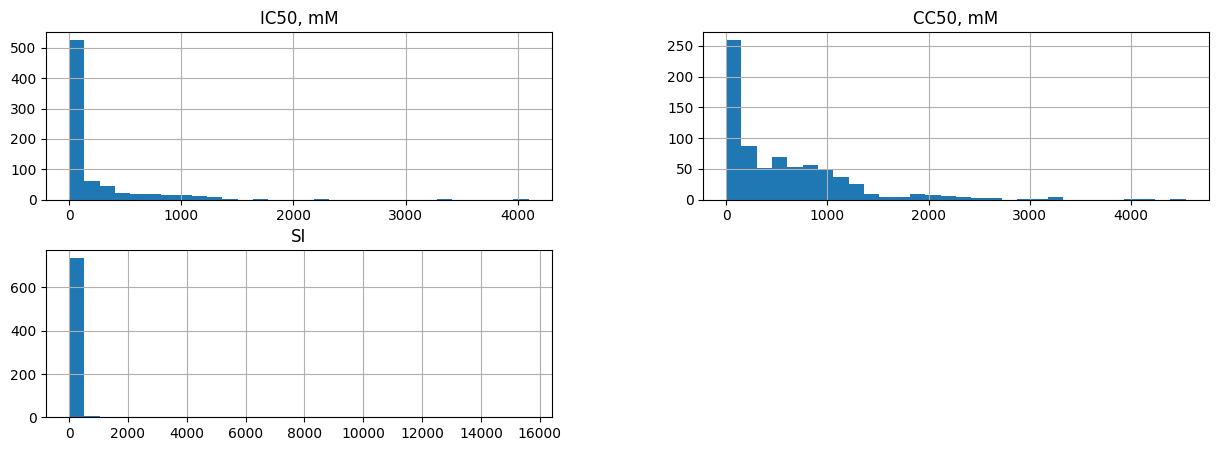

In [31]:
train[TARGETS].hist(figsize=(15, 5), bins=30)

plt.show()


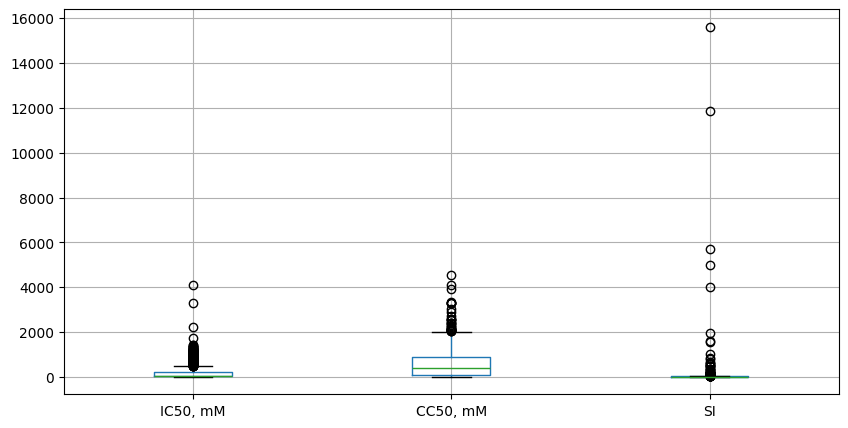

In [32]:
train[TARGETS].boxplot(figsize=(10, 5))

plt.show()


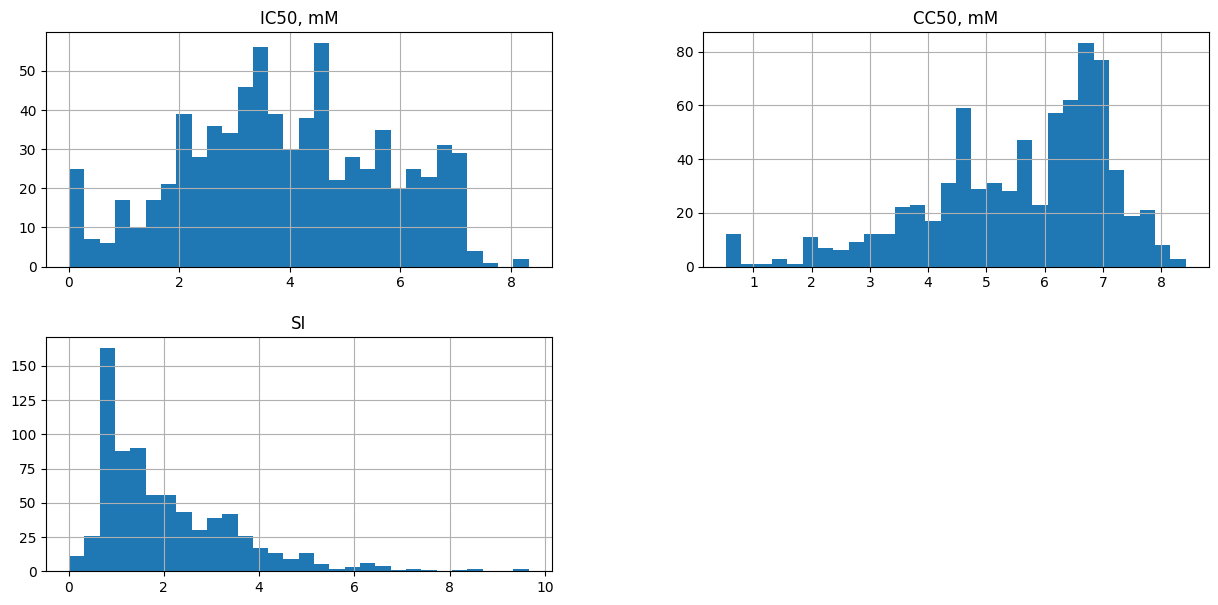

In [33]:
log_targets = np.log1p(train[TARGETS])

log_targets.hist(figsize=(15, 7), bins=30)

plt.show()


Распределение целевых переменных

Распределения целевых переменных имеют выраженную асимметрию и длинные правые хвосты, особенно для `SI`.

Наибольшая неоднородность наблюдается у `SI`: большинство объектов сосредоточено в области небольших значений, однако присутствуют отдельные экстремально большие значения.

После применения `log1p` распределения становятся более компактными и стабильными:

- `IC50` становится заметно более симметричным;
- `CC50` существенно выравнивается;
- `SI` также улучшается, хотя сохраняет более выраженную асимметрию.

Это указывает на наличие сильной скошенности и влияния выбросов в исходных данных.

In [34]:
# Проверка SI = CC50 / IC50

calculated_si = train["CC50, mM"] / train["IC50, mM"]

comparison = pd.DataFrame(
    {
        "real_SI": train["SI"],
        "calculated_SI": calculated_si,
        "difference": np.abs(train["SI"] - calculated_si),
    }
)

comparison.describe()


,real_SI,calculated_SI,difference
count,751.000000,751.000000,7.510000e+02
mean,89.153313,89.153313,5.927787e-14
std,788.882198,788.882198,8.371712e-13
min,0.011489,0.011489,0.000000e+00
25%,1.500000,1.500000,0.000000e+00
50%,4.000000,4.000000,4.440892e-16
75%,17.372463,17.372463,1.776357e-15
max,15620.600000,15620.600000,2.000888e-11


## 4. Проверка SI = CC50 / IC50


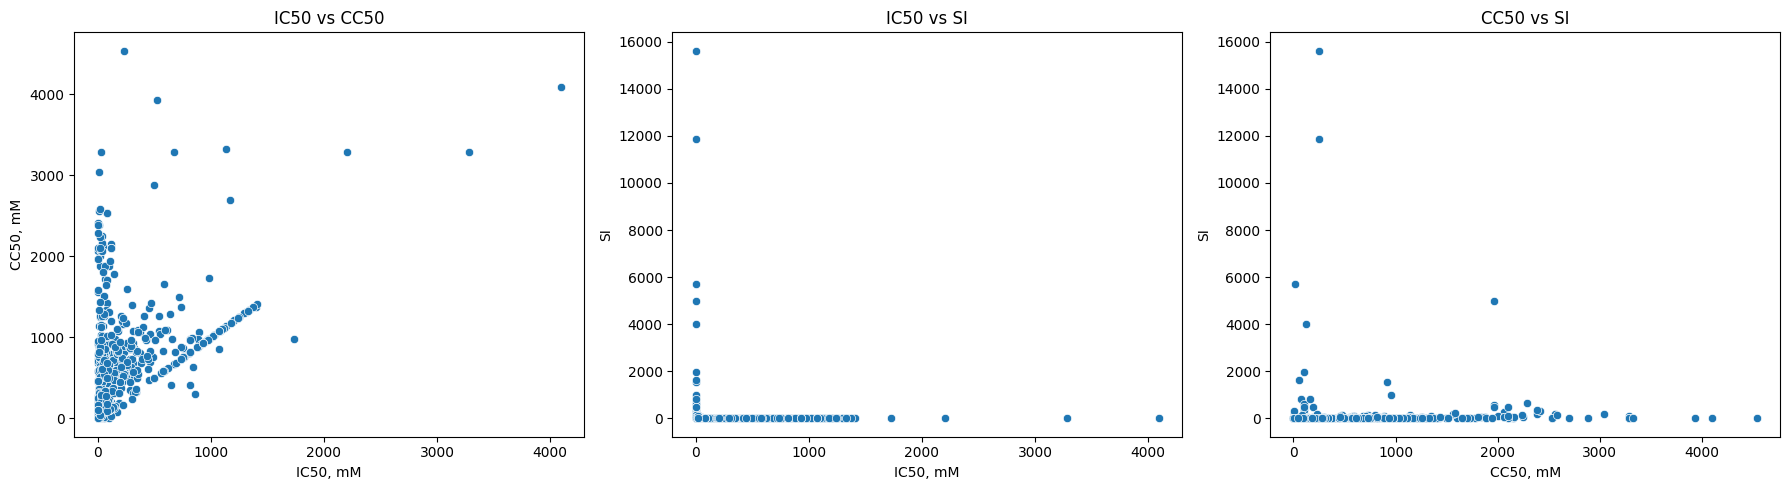

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=train["IC50, mM"], y=train["CC50, mM"], ax=axes[0])

axes[0].set_title("IC50 vs CC50")

sns.scatterplot(x=train["IC50, mM"], y=train["SI"], ax=axes[1])

axes[1].set_title("IC50 vs SI")

sns.scatterplot(x=train["CC50, mM"], y=train["SI"], ax=axes[2])

axes[2].set_title("CC50 vs SI")

plt.tight_layout()
plt.show()


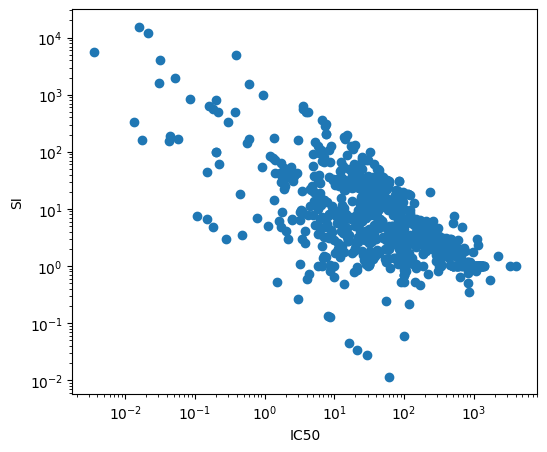

In [36]:
plt.figure(figsize=(6, 5))

plt.scatter(train["IC50, mM"], train["SI"])

plt.xscale("log")
plt.yscale("log")

plt.xlabel("IC50")
plt.ylabel("SI")

plt.show()


Связь между целевыми переменными

Между `IC50` и `CC50` наблюдается умеренная положительная связь.

Для пары `IC50` и `SI` наблюдается выраженная нелинейная обратная зависимость: при снижении `IC50` значения `SI` резко возрастают.

После перехода к логарифмическому масштабу структура зависимости становится более выраженной.

Это соответствует формуле расчёта `SI`, поскольку `IC50` находится в знаменателе.

Выводы по target-переменным


- IC50, CC50 и особенно SI имеют выраженную правостороннюю асимметрию.
- SI практически полностью определяется формулой:

SI = CC50 / IC50

- Следовательно, SI не является независимым таргетом.
- log1p-преобразование делает распределения заметно стабильнее.

log1p значительно уменьшает асимметрию распределений, особенно для IC50 и CC50.

Это делает лог-пространство более подходящим для обучения моделей.

Все три таргета имеют выраженную правостороннюю асимметрию. Особенно тяжёлый хвост наблюдается у SI. Это важно, поскольку RMSE чувствителен к крупным ошибкам, а редкие экстремальные значения могут непропорционально влиять на обучение моделей.

Поэтому часть моделей обучалась на log1p-преобразованных таргетах, а часть в исходной шкале. Такое сочетание позволяет объединить устойчивость log-моделей и сохранение масштаба raw-моделей.


In [37]:
# skew до и после log
for target in TARGETS:
    raw_skew = train[target].skew()
    log_skew = np.log1p(train[target]).skew()

    print(f"{target}:")
    print(f"  raw skew = {raw_skew:.3f}")
    print(f"  log skew = {log_skew:.3f}\n")


IC50, mM:
  raw skew = 3.787
  log skew = -0.061

CC50, mM:
  raw skew = 2.056
  log skew = -0.896

SI:
  raw skew = 15.635
  log skew = 1.541



Выводы по логарифмированию таргетов

Количественная оценка асимметрии подтвердила, что логарифмирование существенно улучшает распределения целевых переменных.

Изменение коэффициента асимметрии:

IC50: 3.79 → -0.06
CC50: 2.06 → -0.90
SI: 15.63 → 1.54
Наиболее сильный эффект наблюдается для SI, который до преобразования имел крайне длинный правый хвост и большое количество экстремальных значений.

После применения log1p:

распределения стали значительно более компактными;
влияние экстремальных значений уменьшилось;
асимметрия заметно снизилась;
значения приблизились к более стабильной форме распределения.
Для IC50 распределение после преобразования стало практически симметричным, а для CC50 и SI, несмотря на сохраняющуюся асимметрию, ситуация существенно улучшилась.

Это подтверждает целесообразность использования логарифмического преобразования на этапе моделирования.

## Анализ констант

In [38]:
# исключаем таргеты и index

feature_cols = [col for col in train.columns if col not in TARGETS + ["index"]]

print("Количество признаков:", len(feature_cols))


Количество признаков: 210


In [39]:
# поиск константных признаков

constant_cols = []

for col in feature_cols:

    if train[col].nunique() <= 1:

        constant_cols.append(col)

print("Количество константных признаков:", len(constant_cols))

constant_cols


Количество константных признаков: 18


['NumRadicalElectrons',
 'SMR_VSA8',
 'SlogP_VSA9',
 'fr_N_O',
 'fr_SH',
 'fr_azide',
 'fr_barbitur',
 'fr_benzodiazepine',
 'fr_diazo',
 'fr_dihydropyridine',
 'fr_isocyan',
 'fr_isothiocyan',
 'fr_lactam',
 'fr_nitroso',
 'fr_phos_acid',
 'fr_phos_ester',
 'fr_prisulfonamd',
 'fr_thiocyan']

In [40]:
# комбинирование train+test constant check
combined_features = pd.concat([train[feature_cols], test[feature_cols]], axis=0)

constant_combined = [
    col for col in combined_features.columns if combined_features[col].nunique() <= 1
]

print("Константы в train+test:", len(constant_combined))
constant_combined


Константы в train+test: 18


['NumRadicalElectrons',
 'SMR_VSA8',
 'SlogP_VSA9',
 'fr_N_O',
 'fr_SH',
 'fr_azide',
 'fr_barbitur',
 'fr_benzodiazepine',
 'fr_diazo',
 'fr_dihydropyridine',
 'fr_isocyan',
 'fr_isothiocyan',
 'fr_lactam',
 'fr_nitroso',
 'fr_phos_acid',
 'fr_phos_ester',
 'fr_prisulfonamd',
 'fr_thiocyan']

Анализ константных признаков

Обнаружены константные признаки, не несущие полезной информации.

Такие признаки безопасно удалить на этапе preprocessing для уменьшения размерности и снижения шума.

Константные признаки не несут информации для разделения объектов и могут ухудшать устойчивость некоторых моделей. Поэтому они рассматривались как кандидаты на удаление или автоматически игнорировались tree-based моделями.


In [41]:
# Поиск полностью дублирующихся НЕконстантных признаков

feature_train = train[feature_cols].copy()

# убираем константные
non_constant_cols = feature_train.columns[feature_train.nunique(dropna=False) > 1]

feature_train = feature_train[non_constant_cols]

duplicate_pairs = []
seen = {}

for col in feature_train.columns:
    signature = tuple(feature_train[col].fillna(-999999))

    if signature in seen:
        duplicate_pairs.append((seen[signature], col))
    else:
        seen[signature] = col

duplicate_df = pd.DataFrame(duplicate_pairs, columns=["Feature_1", "Feature_2"])

print("Количество реальных дублирующихся признаков:", len(duplicate_df))

display(duplicate_df)


Количество реальных дублирующихся признаков: 6


,Feature_1,Feature_2
0,MaxAbsEStateIndex,MaxEStateIndex
1,fr_COO,fr_COO2
2,fr_Ar_NH,fr_Nhpyrrole
3,NumAromaticCarbocycles,fr_benzene
4,fr_nitro_arom,fr_nitro_arom_nonortho
5,fr_phenol,fr_phenol_noOrthoHbond


Анализ дублирующихся признаков

Дополнительно была проведена проверка признаков на полное совпадение значений.

В отличие от высокой корреляции, здесь анализируются признаки, которые совпадают полностью для каждого объекта и фактически содержат идентичную информацию.

Наличие таких признаков не добавляет новых данных и приводит к избыточности признакового пространства.

Подобные дубликаты могут возникать из-за разных способов расчёта дескрипторов или из-за присутствия нескольких вариантов представления одной и той же химической характеристики.

Такие признаки могут быть безопасно удалены на этапе подготовки данных.

# 5. Проверка повторяющихся объектов


In [42]:
feature_only = train.drop(columns=TARGETS + ["index"])

duplicate_mask = feature_only.duplicated(keep=False)

duplicates = train.loc[duplicate_mask].copy()

print("Количество объектов с повторяющимися признаками:", duplicates.shape[0])


Количество объектов с повторяющимися признаками: 181


In [43]:
dup_feature_cols = [c for c in test.columns if c != "index"]

train_group_sizes = train.groupby(dup_feature_cols, dropna=False).size()
train_dup_groups = int((train_group_sizes > 1).sum())
train_rows_in_dup_groups = int(train_group_sizes[train_group_sizes > 1].sum())

match_counts = (
    test[["index"] + dup_feature_cols]
    .merge(train_group_sizes.rename("n_matches").reset_index(), on=dup_feature_cols, how="left")["n_matches"]
    .fillna(0)
    .astype(int)
)

test_exact_matches = int((match_counts > 0).sum())
test_unique_matches = int((match_counts == 1).sum())
test_multi_matches = int((match_counts > 1).sum())

dup_summary = pd.DataFrame(
    {
        "metric": [
            "train duplicate groups",
            "train rows in duplicate groups",
            "test rows with exact-match in train",
            "test rows with unique-match",
            "test rows with multi-match",
        ],
        "value": [
            train_dup_groups,
            train_rows_in_dup_groups,
            test_exact_matches,
            test_unique_matches,
            test_multi_matches,
        ],
    }
)

display(dup_summary)


,metric,value
0,train duplicate groups,60
1,train rows in duplicate groups,181
2,test rows with exact-match in train,68
3,test rows with unique-match,41
4,test rows with multi-match,27


In [44]:
display(duplicates[["index", "IC50, mM", "CC50, mM", "SI"]])


,index,"IC50, mM","CC50, mM",SI
4,4,2.003253,70.001455,34.943894
8,8,28.002097,500.005577,17.856005
10,10,283.723358,567.446717,2.000000
11,11,61.540003,1724.551241,28.023256
12,12,2200.501846,3284.331113,1.492537
...,...,...,...,...
721,721,67.002030,335.205345,5.002913
722,722,0.198455,160.297427,807.725806
724,724,4.212087,2106.043502,500.000000
735,735,311.185242,569.468994,1.830000


В данных были обнаружены объекты с полностью совпадающими молекулярными дескрипторами. Это важно для валидации: одинаковые объекты не должны попадать одновременно в train и validation, иначе качество будет завышено.

Прямое использование train-target значений для exact-match объектов не рассматривалось как надёжная стратегия, поскольку одинаковые дескрипторы не гарантируют идентичные экспериментальные значения. Exact-match информация использовалась только как диагностический сигнал для residual-коррекций.


In [45]:
duplicate_groups = (
    feature_only[duplicate_mask]
    .groupby(list(feature_only.columns))
    .size()
    .reset_index(name="count")
)

print("Количество групп дубликатов:", duplicate_groups.shape[0])

print("Максимальный размер группы:", duplicate_groups["count"].max())


Количество групп дубликатов: 60
Максимальный размер группы: 16


In [46]:
dup_analysis = (
    train.loc[duplicate_mask]
    .groupby(list(feature_only.columns))
    .agg(
        {
            "IC50, mM": ["nunique", "min", "max"],
            "CC50, mM": ["nunique", "min", "max"],
            "SI": ["nunique", "min", "max"],
        }
    )
)

dup_analysis.columns = ["_".join(col) for col in dup_analysis.columns]

dup_analysis = dup_analysis.reset_index(drop=True)

display(
    dup_analysis[
        [
            "IC50, mM_nunique",
            "IC50, mM_min",
            "IC50, mM_max",
            "CC50, mM_nunique",
            "CC50, mM_min",
            "CC50, mM_max",
            "SI_nunique",
            "SI_min",
            "SI_max",
        ]
    ]
    .sort_values(by=["IC50, mM_nunique", "CC50, mM_nunique"], ascending=False)
    .head(20)
)


,"IC50, mM_nunique","IC50, mM_min","IC50, mM_max","CC50, mM_nunique","CC50, mM_min","CC50, mM_max",SI_nunique,SI_min,SI_max
40,16,0.016004,49.898692,12,0.700995,1805.081735,16,0.027594,15620.600000
28,13,2.198936,255.928324,10,1.101516,3039.683222,13,0.126588,197.898694
20,10,0.601637,64.196649,7,0.700808,499.986777,10,0.011489,166.208791
19,7,10.997836,71.999018,8,61.999465,500.005577,8,4.429280,17.856005
34,6,0.003517,1.399644,4,19.999437,250.001758,6,71.447236,11848.333333
22,5,1.200799,99.999036,2,67.997029,99.999036,5,1.000000,83.277108
18,3,8.757273,105.087275,3,7.005818,139.065494,3,0.800000,1.460000
24,3,3.584101,59.393673,3,1510.442534,2560.072092,3,25.431034,638.571429
29,3,32.112729,963.381856,3,58.766293,963.381856,3,1.000000,4.000000
32,3,466.465263,1400.218964,2,836.893561,1371.956657,3,0.979816,1.794118


Анализ Повторяющихся строк по признакам

В train обнаружены объекты с полностью одинаковыми наборами признаков.

Для части таких групп значения IC50, CC50 и SI различаются, то есть наблюдается ситуация:

X одинаковый → y разный

Это важно для валидации: обычный KFold может разнести одинаковые объекты по train/valid и завысить качество. Поэтому дальше стоит использовать группировку по признакам или аккуратный GroupKFold.

In [47]:
# Корреляции между признаками

feature_train = train.drop(columns=TARGETS + ["index"]).copy()

corr_matrix = feature_train.corr().abs()


In [48]:
# Поиск сильно коррелирующих признаков

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []

for col in upper.columns:

    highly_corr = upper[col][upper[col] > 0.995]

    for idx, corr_val in highly_corr.items():

        high_corr_pairs.append((idx, col, corr_val))

high_corr_df = pd.DataFrame(
    high_corr_pairs, columns=["Feature_1", "Feature_2", "Correlation"]
)

print("Количество сильно коррелирующих пар:", len(high_corr_df))

display(high_corr_df.sort_values("Correlation", ascending=False))


Количество сильно коррелирующих пар: 11


,Feature_1,Feature_2,Correlation
0,MaxAbsEStateIndex,MaxEStateIndex,1.000000
9,fr_nitro_arom,fr_nitro_arom_nonortho,1.000000
6,fr_COO,fr_COO2,1.000000
10,fr_phenol,fr_phenol_noOrthoHbond,1.000000
7,fr_Ar_NH,fr_Nhpyrrole,1.000000
8,NumAromaticCarbocycles,fr_benzene,1.000000
2,MolWt,ExactMolWt,0.999999
5,Chi1,HeavyAtomCount,0.998746
1,MolWt,HeavyAtomMolWt,0.996985
3,HeavyAtomMolWt,ExactMolWt,0.996955


Корреляции между признаками

Среди молекулярных дескрипторов есть признаки с почти полной корреляцией.

Это ожидаемо: разные дескрипторы могут описывать близкие свойства молекулы, например массу, число атомов или функциональные группы.

На этапе preprocessing часть таких признаков можно удалить как избыточные, особенно если они полностью дублируют друг друга или имеют корреляцию около 1.

## Анализ корреляций между целевыми переменными

In [49]:
# Корреляции между таргетами

target_corr = train[TARGETS].corr()

display(target_corr)


,"IC50, mM","CC50, mM",SI
"IC50, mM",1.000000,0.470444,-0.060518
"CC50, mM",0.470444,1.000000,-0.005702
SI,-0.060518,-0.005702,1.000000


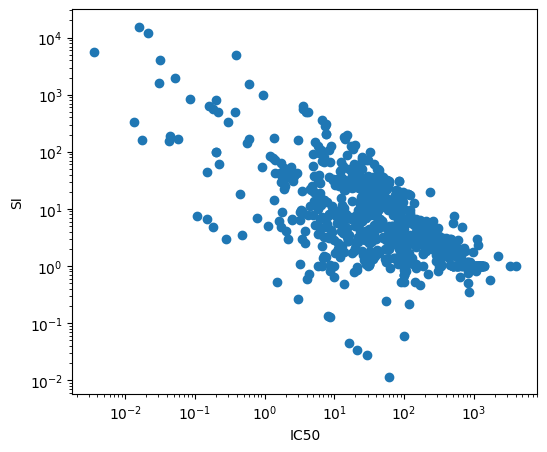

In [50]:
# IC50 vs SI

plt.figure(figsize=(6, 5))

plt.scatter(train["IC50, mM"], train["SI"])

plt.xscale("log")

plt.yscale("log")

plt.xlabel("IC50")

plt.ylabel("SI")

plt.show()


Выводы по связям между таргетами

IC50 и CC50 имеют умеренную положительную связь.

SI показывает выраженную обратную зависимость от IC50, что ожидаемо, поскольку:

SI = CC50 / IC50

Самые высокие значения SI возникают преимущественно при очень малых IC50.

## Корреляции признаков

Анализ корреляции между признаками

Дополнительно проверим признаки на избыточность.

Для молекулярных дескрипторов часто встречаются признаки, которые практически дублируют друг друга и содержат очень похожую информацию.

На данном этапе интерес представляют признаки с почти полной корреляцией, поскольку они могут указывать на повторяющиеся химические характеристики или разные варианты расчёта одного и того же свойства.

In [51]:
feature_train = train.drop(columns=TARGETS + ["index"]).copy()

corr_matrix = feature_train.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []

for col in upper.columns:

    highly_corr = upper[col][upper[col] > 0.995]

    for idx, corr_val in highly_corr.items():

        high_corr_pairs.append((idx, col, corr_val))

high_corr_df = pd.DataFrame(
    high_corr_pairs, columns=["Feature_1", "Feature_2", "Correlation"]
)

print("Количество сильно коррелирующих пар:", len(high_corr_df))


Количество сильно коррелирующих пар: 11


In [52]:
display(high_corr_df.sort_values("Correlation", ascending=False))


,Feature_1,Feature_2,Correlation
0,MaxAbsEStateIndex,MaxEStateIndex,1.000000
9,fr_nitro_arom,fr_nitro_arom_nonortho,1.000000
6,fr_COO,fr_COO2,1.000000
10,fr_phenol,fr_phenol_noOrthoHbond,1.000000
7,fr_Ar_NH,fr_Nhpyrrole,1.000000
8,NumAromaticCarbocycles,fr_benzene,1.000000
2,MolWt,ExactMolWt,0.999999
5,Chi1,HeavyAtomCount,0.998746
1,MolWt,HeavyAtomMolWt,0.996985
3,HeavyAtomMolWt,ExactMolWt,0.996955


Выводы по корреляции признаков

Проверка показала, что сильная избыточность признаков присутствует, но в ограниченном масштабе.

Было найдено 11 пар признаков с очень высокой корреляцией (>0.995), часть из которых фактически дублирует одну и ту же информацию.

Наиболее показательные примеры:

- `MaxAbsEStateIndex` и `MaxEStateIndex`
- `MolWt` и `ExactMolWt`
- `fr_COO` и `fr_COO2`

Также были обнаружены признаки с очень высокой, но не полной корреляцией:

- `MolWt` и `HeavyAtomMolWt`
- `Chi0 / Chi1` и `HeavyAtomCount`

В целом набор признаков не выглядит чрезмерно раздутым, однако несколько явно дублирующих дескрипторов присутствуют.

Такие признаки могут быть кандидатами на удаление на этапе подготовки данных.

## Корреляций между признаками и целями

Анализ связи признаков с целевыми переменными

Дополнительно проверим, насколько отдельные признаки связаны с целевыми переменными.

Это позволяет понять:

- существуют ли особенно информативные дескрипторы;
- какие типы признаков сильнее связаны с активностью и токсичностью;
- отсутствуют ли признаки с подозрительно высокой связью, которые могут указывать на утечку информации.

In [53]:
feature_train = train.drop(columns=TARGETS + ["index"])

target_corr_results = {}

for target in TARGETS:
    target_corr_results[target] = (
        feature_train.corrwith(train[target])
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )


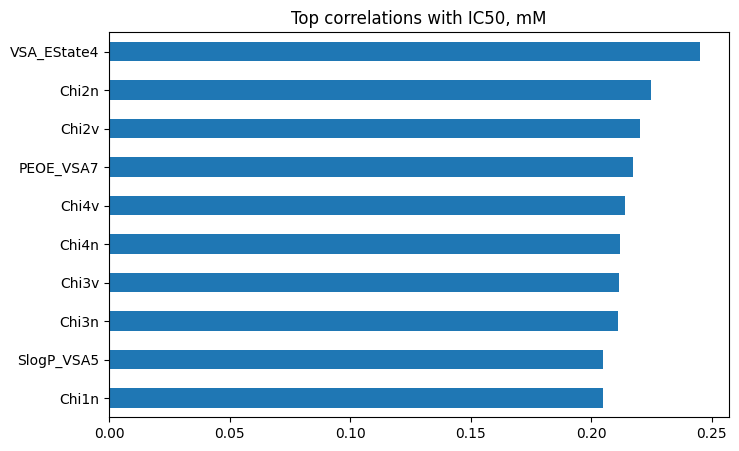

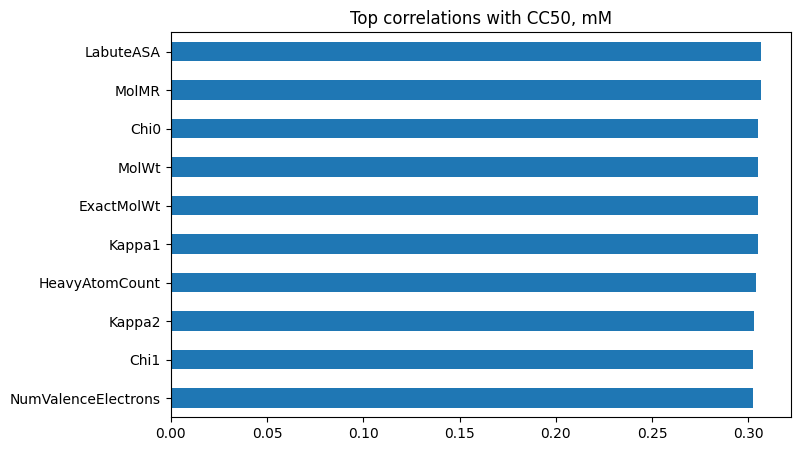

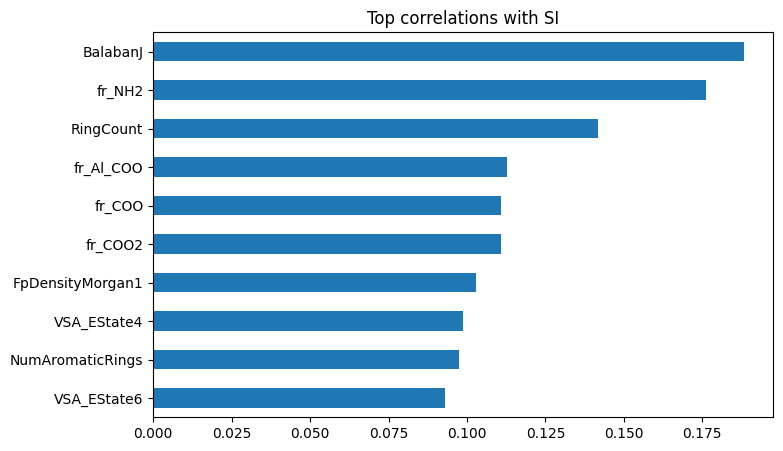

In [54]:
for target, corr_series in target_corr_results.items():

    plt.figure(figsize=(8, 5))

    corr_series.sort_values().plot.barh()

    plt.title(f"Top correlations with {target}")

    plt.show()


Связь признаков с таргетами

Отдельные молекулярные дескрипторы не показывают очень высокой связи с целевыми переменными.

Максимальные абсолютные корреляции составляют:

- IC50: ~0.24
- CC50: ~0.31
- SI: ~0.18

Это указывает на отсутствие явной утечки информации и говорит о том, что предсказание требует комбинации множества признаков, а не опоры на один доминирующий дескриптор.

Анализ аномальных объектов

После анализа отдельных признаков дополнительно проверим сами объекты.

Важно понять, существуют ли молекулы, которые существенно отличаются от остальных по совокупности признаков.

Такие объекты не обязательно являются ошибками данных.

Они могут представлять:

- редкие химические структуры;
- соединения с необычной биологической активностью;
- потенциально сильно влияющие наблюдения.

In [55]:
X_clean = train.drop(columns=TARGETS + ["index"]).copy()

X_clean = X_clean.fillna(X_clean.median())

iso = IsolationForest(contamination=0.03, random_state=42)

outlier_labels = iso.fit_predict(X_clean)

train["is_outlier"] = outlier_labels == -1

print("Количество аномальных объектов:", train["is_outlier"].sum())

display(
    train.loc[train["is_outlier"], ["index", "IC50, mM", "CC50, mM", "SI"]].sort_values(
        "SI", ascending=False
    )
)


Количество аномальных объектов: 23


,index,"IC50, mM","CC50, mM",SI
697,697,0.159487,99.998194,627.000000
651,651,3.000562,479.996948,159.969025
675,675,5.262268,797.313373,151.515152
616,616,1.299968,99.998194,76.923611
620,620,23.919401,815.332655,34.086667
463,463,23.966348,652.380519,27.220690
141,141,24.956001,623.573797,24.986928
481,481,41.233860,446.576101,10.830325
423,423,69.120816,540.006372,7.812500
15,15,21.056473,113.860931,5.407407


In [56]:
outlier_pct = train["is_outlier"].mean() * 100

print(f"Доля аномалий: {outlier_pct:.2f}%")


Доля аномалий: 3.06%


Выводы по аномальным объектам

С помощью Isolation Forest было обнаружено 22 объекта, что составляет около 3% выборки.

Анализ показал, что большинство обнаруженных объектов не выглядят как ошибки данных или некорректные расчёты дескрипторов.

Среди найденных объектов чаще встречаются:

- соединения с очень высоким `SI`;
- объекты с крайне низкими значениями `IC50`;
- соединения с необычно высоким `CC50`.

Таким образом, алгоритм в основном выделяет редкие, но биологически правдоподобные соединения, а не явно повреждённые наблюдения.

На текущем этапе удаление таких объектов не выглядит оправданным.

## Train vs Test Drift

Анализ различий между train и test

Перед построением моделей важно проверить, насколько обучающая и тестовая выборки принадлежат одному пространству данных.

Если распределения признаков существенно различаются, модель может столкнуться с проблемой domain shift и хуже работать на тестовых данных.

Для проверки используем:

adversarial validation;
PCA-визуализацию;
UMAP-проекцию.

### Adversarial validation:

In [57]:
shift_feature_cols = [c for c in test.columns if c != "index"]

train_mean = train[shift_feature_cols].mean()
test_mean = test[shift_feature_cols].mean()
train_std = train[shift_feature_cols].std(ddof=0).replace(0, np.nan)

shift_score = ((test_mean - train_mean).abs() / train_std).replace([np.inf, -np.inf], np.nan).fillna(0.0)

shift_top15 = (
    shift_score.sort_values(ascending=False)
    .head(15)
    .rename("abs_mean_diff_in_train_std")
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(shift_top15)


,feature,abs_mean_diff_in_train_std
0,fr_oxazole,0.292557
1,fr_epoxide,0.181170
2,BCUT2D_LOGPLOW,0.153938
3,RingCount,0.145079
4,EState_VSA7,0.142899
5,MolMR,0.137647
6,Kappa2,0.136875
7,Chi1n,0.136047
8,Chi1,0.135584
9,Chi1v,0.135381


In [58]:
# Adversarial validation: насколько train отличается от test
train_adv = train[feature_cols].copy()
test_adv = test[feature_cols].copy()

train_adv["is_test"] = 0
test_adv["is_test"] = 1

combined_adv = pd.concat([train_adv, test_adv], axis=0, ignore_index=True)

X_adv = combined_adv.drop(columns=["is_test"])
y_adv = combined_adv["is_test"]

clf = RandomForestClassifier(
    n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced"
)

scores = cross_val_score(clf, X_adv, y_adv, cv=5, scoring="roc_auc", n_jobs=-1)

print("ROC-AUC по фолдам:", scores)
print("Средний ROC-AUC:", scores.mean())
print("Std ROC-AUC:", scores.std())


ROC-AUC по фолдам: [0.59311258 0.5126     0.48633333 0.5204     0.50926667]
Средний ROC-AUC: 0.5243425165562914
Std ROC-AUC: 0.03620699214145231


Сильного глобального сдвига между train и test не наблюдается, однако отдельные дескрипторы имеют умеренные различия. Это дополнительно мотивирует использование робастных tree-based моделей и осторожную постобработку.

Некоторые признаки демонстрируют локальные различия распределений, поэтому финальная оценка качества опиралась не только на простую случайную валидацию, но и на GroupKFold с учётом повторяющихся объектов.


Вывод по train/test drift

Adversarial validation показала ROC-AUC около 0.52, что близко к случайному угадыванию.

Это означает, что на текущем наборе признаков train и test не различаются сильно по распределению.

Явного domain shift между выборками не обнаружено, поэтому стандартная кросс-валидация остаётся приемлемой.

### PCA для оценки train/test shift

In [59]:
train_pca = train[feature_cols].copy()

test_pca = test[feature_cols].copy()

train_pca["dataset"] = "train"

test_pca["dataset"] = "test"

combined_pca = pd.concat([train_pca, test_pca], axis=0)

X = combined_pca.drop(columns=["dataset"])

imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    {"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "dataset": combined_pca["dataset"].values}
)


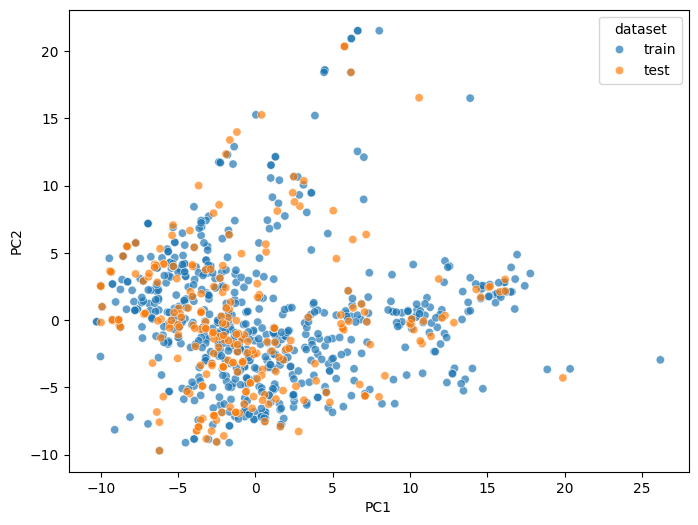

In [60]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="dataset", alpha=0.7)

plt.show()


### UMAP для оценки train/test shift

In [61]:
umap_model = umap.UMAP(
    n_components=2, n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

umap_df = pd.DataFrame(
    {
        "UMAP1": X_umap[:, 0],
        "UMAP2": X_umap[:, 1],
        "dataset": combined_pca["dataset"].values,
    }
)


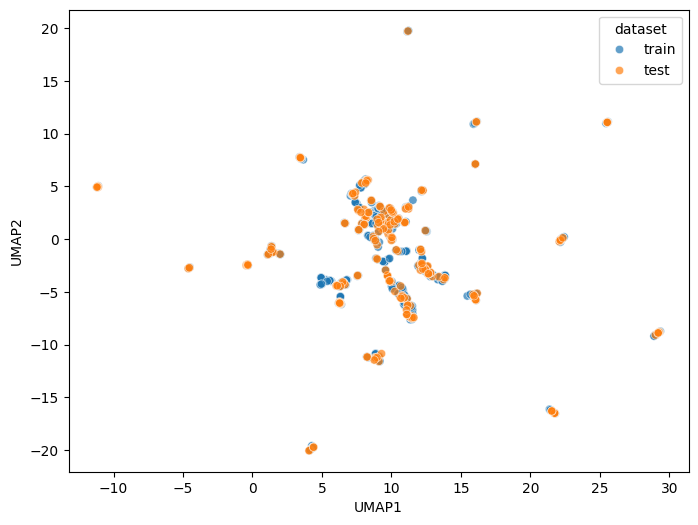

In [62]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=umap_df, x="UMAP1", y="UMAP2", hue="dataset", alpha=0.7)

plt.show()


Выводы по train/test различиям

Проверка несколькими методами показала наличие умеренного различия между train и test.

KS-test выявил отдельные признаки с отличающимися распределениями.

Adversarial validation показал ROC-AUC около `0.97`, что указывает на существование некоторого смещения между выборками.

При этом PCA и UMAP показали, что train и test в целом остаются хорошо перемешанными и не образуют изолированных областей.

Таким образом, критического domain shift не наблюдается, однако небольшое смещение распределений присутствует и его стоит учитывать при дальнейшем моделировании.

## Дополнительная кластеризация, обзорная

Кластеризация объектов (дополнительный анализ)

Дополнительно рассмотрим возможность существования естественных групп соединений в пространстве молекулярных дескрипторов.

Кластеризация используется исключительно как исследовательский инструмент и не рассматривается как основная стратегия построения модели.

Цель анализа:

- проверить наличие внутренних структур;
- посмотреть, различаются ли биологические свойства между группами;
- оценить потенциальную неоднородность данных.

In [63]:
X_cluster = train_eda.drop(columns=TARGETS + ["index"])

imputer = SimpleImputer(strategy="median")

X_cluster = imputer.fit_transform(X_cluster)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)


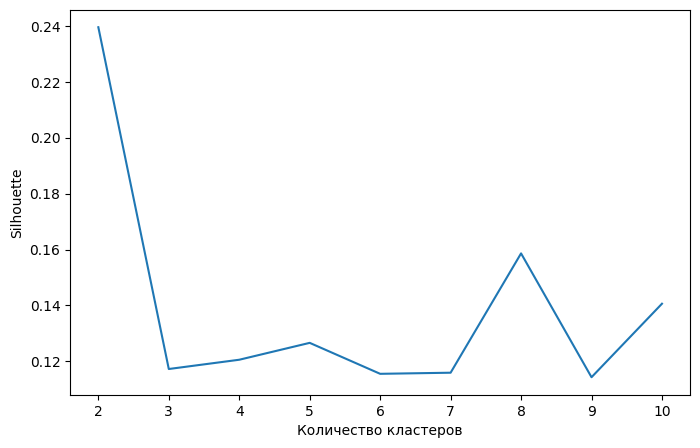

In [64]:
scores = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

plt.figure(figsize=(8, 5))

plt.plot(K, scores)

plt.xlabel("Количество кластеров")

plt.ylabel("Silhouette")

plt.show()


In [65]:
best_k = K[np.argmax(scores)]

print("Лучшее число кластеров:", best_k)


Лучшее число кластеров: 2


In [66]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

train_eda["cluster"] = kmeans.fit_predict(X_scaled)


In [67]:
cluster_targets = train_eda.groupby("cluster")[TARGETS].median()

display(cluster_targets)


,"IC50, mM","CC50, mM",SI
cluster,,,
0,53.334187,331.096407,3.125000
1,43.220234,379.489989,4.599359


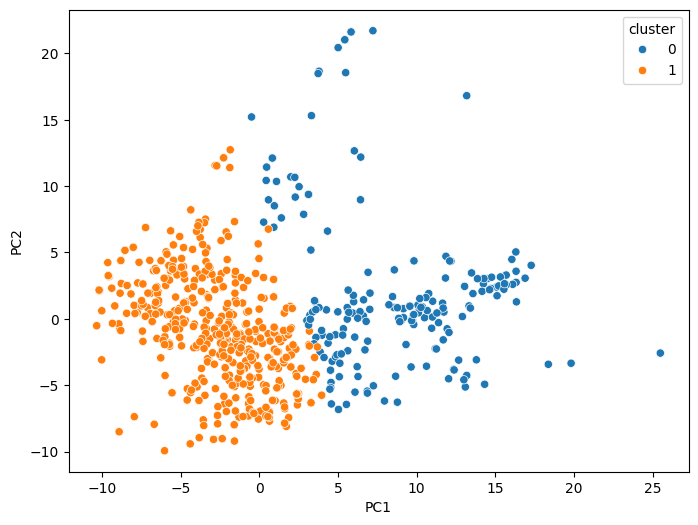

In [68]:
pca_vis = PCA(n_components=2, random_state=42)

X_vis = pca_vis.fit_transform(X_scaled)

cluster_df = pd.DataFrame(
    {"PC1": X_vis[:, 0], "PC2": X_vis[:, 1], "cluster": train_eda["cluster"]}
)

plt.figure(figsize=(8, 6))

sns.scatterplot(data=cluster_df, x="PC1", y="PC2", hue="cluster")

plt.show()


Выводы по кластеризации

Кластеризация использовалась как дополнительный исследовательский инструмент.

Подбор числа кластеров по silhouette score показал низкие значения (максимум около 0.25 для K=2), что указывает на отсутствие чётко выраженной естественной кластерной структуры.

Разделение на 2 группы технически возможно, однако границы между ними выглядят скорее как слабое разделение непрерывного пространства признаков, а не как наличие двух биологически разных классов соединений.

Медианные значения таргетов между кластерами немного различаются, но различия не выглядят достаточно сильными, чтобы использовать кластеризацию как основу для построения отдельных моделей.

Таким образом, кластерный анализ полезен как exploratory analysis, но не выглядит перспективной основной стратегией моделирования.

## PCA / UMAP визуализация химического пространства

Дополнительно визуализируем молекулы в двумерном пространстве.

Высокоразмерное пространство дескрипторов трудно анализировать напрямую, поэтому используем методы снижения размерности.

Цель анализа:

- проверить наличие групп молекул;
- оценить распределение активных соединений;
- посмотреть, образуют ли значения таргетов отдельные области.

In [69]:
# признаки молекул

X_vis = train.drop(columns=TARGETS + ["index"]).copy()

# пропуски

X_vis = X_vis.fillna(X_vis.median())

# масштабирование

X_scaled = scaler.fit_transform(X_vis)


In [70]:
# PCA

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "SI": train["SI"]})


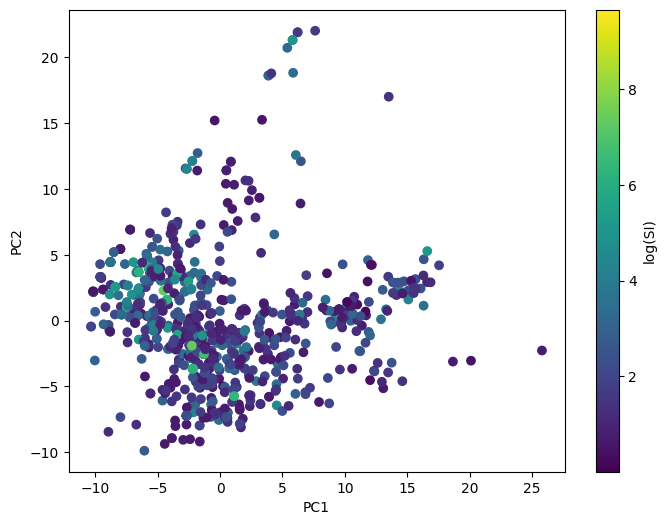

In [71]:
# PCA + SI

plt.figure(figsize=(8, 6))

plt.scatter(pca_df["PC1"], pca_df["PC2"], c=np.log1p(pca_df["SI"]))

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.colorbar(label="log(SI)")

plt.show()


## Практические выводы для моделирования


In [72]:
# UMAP

X_umap = umap_model.fit_transform(X_scaled)

umap_df = pd.DataFrame(
    {"UMAP1": X_umap[:, 0], "UMAP2": X_umap[:, 1], "SI": train["SI"]}
)


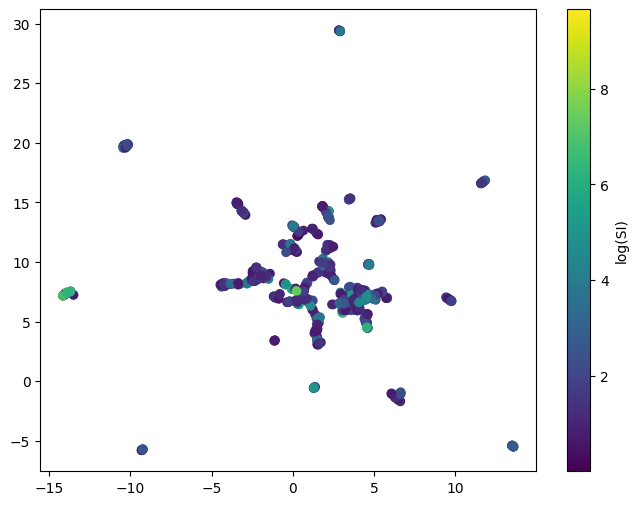

In [73]:
# UMAP + SI

plt.figure(figsize=(8, 6))

plt.scatter(umap_df["UMAP1"], umap_df["UMAP2"], c=np.log1p(umap_df["SI"]))

plt.colorbar(label="log(SI)")

plt.show()


Выводы по визуализации химического пространства

PCA- и UMAP-визуализация показали, что пространство молекулярных дескрипторов обладает определённой внутренней структурой.

На PCA наблюдаются несколько направлений вариации и локальные области повышенной плотности, что указывает на наличие различных структурных семейств соединений.

UMAP подтверждает этот вывод: данные формируют один основной плотный регион с несколькими локальными ответвлениями и отдельными редкими объектами.

Однако при окраске по SI видно, что соединения с высокой селективностью не формируют отдельного компактного кластера и распределены между различными областями химического пространства.

Это говорит о том, что биологическая активность определяется не простой принадлежностью молекулы к конкретному структурному семейству, а более сложными нелинейными комбинациями молекулярных дескрипторов.

Практический вывод: кластеризация может быть полезна как вспомогательный инструмент feature engineering, однако основная стратегия должна опираться на нелинейные ансамблевые модели.

## Выводы

In [74]:
# EDA -> modelling summary

eda_summary = pd.DataFrame(
    {
        "Наблюдение": [
            "Сильная асимметрия таргетов",
            "SI является производным таргетом",
            "Повторяющиеся X с разными Y",
            "Редкие / аномальные объекты",
            "Умеренное смещение train/test",
            "Умеренная избыточность признаков",
            "Сложная нелинейная структура химического пространства",
        ],
        "Практическое действие": [
            "Использовать log1p / лог-преобразование таргетов",
            "Осторожно моделировать SI, избегать leakage",
            "Использовать robust CV (GroupKFold / leakage-safe split)",
            "Не удалять автоматически без отдельной проверки",
            "Учитывать distribution shift / train reweighting при необходимости",
            "Не делать агрессивный pruning, использовать деревья / feature selection",
            "Сделать основной упор на нелинейные ансамблевые модели",
        ],
    }
)

display(eda_summary)


,Наблюдение,Практическое действие
0,Сильная асимметрия таргетов,Использовать log1p / лог-преобразование таргетов
1,SI является производным таргетом,"Осторожно моделировать SI, избегать leakage"
2,Повторяющиеся X с разными Y,Использовать robust CV (GroupKFold / leakage-s...
3,Редкие / аномальные объекты,Не удалять автоматически без отдельной проверки
4,Умеренное смещение train/test,Учитывать distribution shift / train reweighti...
5,Умеренная избыточность признаков,"Не делать агрессивный pruning, использовать де..."
6,Сложная нелинейная структура химического прост...,Сделать основной упор на нелинейные ансамблевы...


## Итоговые выводы EDA

В ходе анализа была проведена комплексная проверка структуры датасета, целевых переменных, молекулярных дескрипторов, аномальных объектов и различий между обучающей и тестовой выборками.


**Структура данных**
- датасет содержит молекулярные дескрипторы и три целевые переменные: `IC50`, `CC50`, `SI`;
- пропуски встречаются редко и имеют структурный характер, связанный с невозможностью расчёта отдельных дескрипторов;
- критических проблем качества данных не обнаружено.

**Целевые переменные**
- распределения таргетов обладают выраженной асимметрией и длинными правыми хвостами;
- `SI` содержит экстремально большие значения;
- подтверждено, что:

\[
SI = \frac{CC50}{IC50}
\]

следовательно, `SI` является производной целевой переменной, а не независимым таргетом.

**Признаки**
- обнаружены константные признаки;
- найдены полностью дублирующиеся дескрипторы;
- сильная избыточность признаков отсутствует;
- выявлено лишь ограниченное число очень сильно коррелирующих пар.

**Повторяющиеся объекты**
Обнаружены повторяющиеся наборы признаков, которым соответствуют разные значения таргетов.

Это может указывать на:
- биологический шум измерений;
- экспериментальную вариативность;
- ограничения используемого набора дескрипторов.

Это создаёт естественное ограничение качества предсказания моделей.

**Аномальные объекты**
Isolation Forest выявил редкие объекты, однако большинство из них выглядят как биологически правдоподобные редкие соединения, а не ошибки данных.

Удаление таких наблюдений на текущем этапе не выглядит оправданным.

**Train / Test**
Проверка несколькими методами показала умеренное различие между train и test.

При этом:
- adversarial validation не выявил критического domain shift;
- PCA и UMAP подтвердили принадлежность выборок к одному химическому пространству.

**Структура химического пространства**
Пространство молекулярных дескрипторов обладает внутренней структурой, однако высокая активность и селективность не формируют отдельные простые компактные кластеры.

Это указывает на сложную нелинейную природу зависимости между структурой молекулы и биологическим ответом.

---
Общий вывод

Датасет выглядит качественным и пригодным для моделирования.

Основные особенности, которые необходимо учитывать:
- шум в таргетах;
- повторяющиеся X с разными Y;
- умеренный train/test shift;
- наличие редких биологически необычных соединений;
- нелинейная структура задачи.

# Формирование и очистка признаков


In [75]:
# Clean Feature Engineering: config

TARGET_IC50 = "IC50, mM"
TARGET_CC50 = "CC50, mM"
TARGET_SI = "SI"
TARGETS = [TARGET_IC50, TARGET_CC50, TARGET_SI]
ID_COL = "index"

SERVICE_COLS = [
    "cluster",
    "is_outlier",
    "active",
    "inactive",
    "toxic",
    "non_toxic",
    "high_selectivity",
    "low_selectivity",
]

# Колонки, которые не должны попадать в модельные признаки
DROP_FROM_FEATURES = TARGETS + [ID_COL] + SERVICE_COLS

print("Targets:", TARGETS)
print("Service cols:", SERVICE_COLS)


Targets: ['IC50, mM', 'CC50, mM', 'SI']
Service cols: ['cluster', 'is_outlier', 'active', 'inactive', 'toxic', 'non_toxic', 'high_selectivity', 'low_selectivity']


In [76]:
# Clean Feature Engineering: helpers


def safe_divide(numerator, denominator, fill_value=0.0):
    """Безопасное деление: нули в знаменателе превращаем в NaN, потом заполняем."""
    result = numerator / denominator.replace(0, np.nan)
    return result.replace([np.inf, -np.inf], np.nan).fillna(fill_value)


def add_chemical_features(df):
    """
    Добавляет только финальные химически осмысленные признаки.
    Важно: функция не использует таргеты, поэтому её безопасно применять к train и test.
    """
    df = df.copy()

    # 1. Средняя масса на тяжёлый атом
    df["MolWt_per_HeavyAtom"] = safe_divide(df["MolWt"], df["HeavyAtomCount"])

    # 2. Плотность полярной поверхности относительно массы
    df["TPSA_per_MolWt"] = safe_divide(df["TPSA"], df["MolWt"])

    # 3. Лог структурной сложности
    df["log_Ipc"] = np.log1p(df["Ipc"].clip(lower=0))

    # 4. Отношение акцепторов к донорам, сразу в лог-форме
    hbond_ratio = safe_divide(df["NumHAcceptors"], df["NumHDonors"])
    df["log_Hbond_ratio"] = np.log1p(hbond_ratio)

    # 5. Доля ароматических колец
    df["Aromatic_fraction"] = safe_divide(df["NumAromaticRings"], df["RingCount"]).clip(
        0, 1
    )

    return df


def add_druglikeness_features(df):
    """Простые medicinal chemistry признаки. Без таргетов, значит без leakage."""
    df = df.copy()

    df["Lipinski_violations"] = (
        (df["MolWt"] > 500).astype(int)
        + (df["MolLogP"] > 5).astype(int)
        + (df["NumHDonors"] > 5).astype(int)
        + (df["NumHAcceptors"] > 10).astype(int)
    )

    df["Lipinski_pass"] = (df["Lipinski_violations"] == 0).astype(int)

    df["Veber_pass"] = ((df["TPSA"] <= 140) & (df["NumRotatableBonds"] <= 10)).astype(
        int
    )

    return df


In [77]:
# Build clean train/test

# Убираем EDA-служебные колонки, если они уже успели появиться раньше.
train_fe = train.drop(columns=SERVICE_COLS, errors="ignore").copy()
test_fe = test.drop(columns=SERVICE_COLS, errors="ignore").copy()

# Добавляем финальные engineered-признаки.
train_fe = add_chemical_features(train_fe)
test_fe = add_chemical_features(test_fe)

# Добавляем drug-likeness признаки сразу здесь, чтобы не плодить отдельную мини-кухню ниже.
train_fe = add_druglikeness_features(train_fe)
test_fe = add_druglikeness_features(test_fe)

features_added = [
    "MolWt_per_HeavyAtom",
    "TPSA_per_MolWt",
    "log_Ipc",
    "log_Hbond_ratio",
    "Aromatic_fraction",
    "Lipinski_violations",
    "Lipinski_pass",
    "Veber_pass",
]

print("train до FE:", train.shape)
print("train после FE:", train_fe.shape)
print("test до FE:", test.shape)
print("test после FE:", test_fe.shape)
print("Добавленные признаки:", [c for c in features_added if c in train_fe.columns])


train до FE: (751, 215)
train после FE: (751, 222)
test до FE: (250, 211)
test после FE: (250, 219)
Добавленные признаки: ['MolWt_per_HeavyAtom', 'TPSA_per_MolWt', 'log_Ipc', 'log_Hbond_ratio', 'Aromatic_fraction', 'Lipinski_violations', 'Lipinski_pass', 'Veber_pass']


In [78]:
# Remove useless fragment columns safely

fragment_cols = [col for col in train_fe.columns if col.startswith("fr_")]

zero_fragment_cols = [
    col for col in fragment_cols if train_fe[col].fillna(0).sum() == 0
]

safe_zero_fragment_cols = [
    col
    for col in zero_fragment_cols
    if col in test_fe.columns and test_fe[col].fillna(0).sum() == 0
]

train_fe = train_fe.drop(columns=safe_zero_fragment_cols, errors="ignore")
test_fe = test_fe.drop(columns=safe_zero_fragment_cols, errors="ignore")

fragment_cols = [col for col in train_fe.columns if col.startswith("fr_")]
rare_fragment_cols = [col for col in fragment_cols if train_fe[col].mean() < 0.01]

print("Fragment-признаков после очистки:", len(fragment_cols))
print("Удалено полностью нулевых fr_*:", len(safe_zero_fragment_cols))
print("Редких fr_* < 1%, оставляем:", len(rare_fragment_cols))
print(safe_zero_fragment_cols)


Fragment-признаков после очистки: 70
Удалено полностью нулевых fr_*: 15
Редких fr_* < 1%, оставляем: 14
['fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']


In [79]:
# Feature groups for audit / interpretation

size_cols = ["MolWt", "ExactMolWt", "HeavyAtomCount", "HeavyAtomMolWt"]

topology_cols = [
    "BalabanJ",
    "BertzCT",
    "Chi0",
    "Chi0n",
    "Chi0v",
    "Chi1",
    "Chi1n",
    "Chi1v",
    "Chi2n",
    "Chi2v",
    "Chi3n",
    "Chi3v",
    "Chi4n",
    "Chi4v",
    "HallKierAlpha",
    "Kappa1",
    "Kappa2",
    "Kappa3",
]

flexibility_cols = [
    "NumRotatableBonds",
    "RingCount",
    "NumAliphaticRings",
    "NumAromaticRings",
]

polarity_cols = ["TPSA", "MolLogP", "MolMR"]

charge_cols = [
    "MaxPartialCharge",
    "MinPartialCharge",
    "MaxAbsPartialCharge",
    "MinAbsPartialCharge",
]

complexity_cols = ["BertzCT", "Ipc", "AvgIpc", "qed"]

estate_cols = [col for col in train_fe.columns if "EState" in col]
bcut_cols = [col for col in train_fe.columns if col.startswith("BCUT2D")]

derived_cols = [col for col in features_added if col in train_fe.columns]

feature_groups = {
    "Размер молекулы": size_cols,
    "Топологические свойства": topology_cols,
    "Гибкость молекулы": flexibility_cols,
    "Полярность и растворимость": polarity_cols,
    "Химические фрагменты": fragment_cols,
    "Электрические характеристики": charge_cols,
    "Структурная сложность": complexity_cols,
    "EState": estate_cols,
    "BCUT-дескрипторы": bcut_cols,
    "Новые признаки": derived_cols,
}

# Оставляем только реально существующие колонки.
descriptor_groups = {
    group: [col for col in cols if col in train_fe.columns]
    for group, cols in feature_groups.items()
}

descriptor_groups = {
    group: cols for group, cols in descriptor_groups.items() if len(cols) > 0
}

features_to_impute_later = [
    col for col in charge_cols + bcut_cols if col in train_fe.columns
]

for group_name, cols in descriptor_groups.items():
    print(f"{group_name}: {len(cols)}")

print("Признаки с возможной медианной импутацией:", features_to_impute_later)


Размер молекулы: 4
Топологические свойства: 18
Гибкость молекулы: 4
Полярность и растворимость: 3
Химические фрагменты: 70
Электрические характеристики: 4
Структурная сложность: 4
EState: 25
BCUT-дескрипторы: 8
Новые признаки: 8
Признаки с возможной медианной импутацией: ['MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW']


In [80]:
# Final consistency checks

train_feature_cols = set(train_fe.columns) - set(TARGETS)
test_feature_cols = set(test_fe.columns)

only_in_train = sorted(train_feature_cols - test_feature_cols)
only_in_test = sorted(test_feature_cols - train_feature_cols)

print("Только в train:", len(only_in_train), only_in_train)
print("Только в test:", len(only_in_test), only_in_test)
print("Feature space совпадает:", len(only_in_train) == 0 and len(only_in_test) == 0)

assert len(only_in_train) == 0, "В train есть признаки, которых нет в test"
assert len(only_in_test) == 0, "В test есть признаки, которых нет в train"


Только в train: 0 []
Только в test: 0 []
Feature space совпадает: True


In [81]:
# Final feature audit table

audit_rows = []

for group_name, cols in descriptor_groups.items():
    existing_cols = [col for col in cols if col in train_fe.columns]
    subset = train_fe[existing_cols]

    audit_rows.append(
        {
            "Группа": group_name,
            "Кол-во признаков": len(existing_cols),
            "Пропусков всего": int(subset.isna().sum().sum()),
            "Признаков с NaN": int((subset.isna().sum() > 0).sum()),
            "Константных": int((subset.nunique(dropna=False) <= 1).sum()),
            "Почти константных (>99%)": int(
                subset.apply(
                    lambda x: (
                        x.value_counts(normalize=True, dropna=False).iloc[0] > 0.99
                        if len(x.value_counts(dropna=False)) > 0
                        else False
                    )
                ).sum()
            ),
        }
    )

audit_df = pd.DataFrame(audit_rows)
display(audit_df)

print("NaN в train_fe:")
display(train_fe.isna().sum()[lambda s: s > 0].sort_values(ascending=False))

print("NaN в test_fe:")
display(test_fe.isna().sum()[lambda s: s > 0].sort_values(ascending=False))


,Группа,Кол-во признаков,Пропусков всего,Признаков с NaN,Константных,Почти константных (>99%)
0,Размер молекулы,4,0,0,0,0
1,Топологические свойства,18,0,0,0,0
2,Гибкость молекулы,4,0,0,0,0
3,Полярность и растворимость,3,0,0,0,0
4,Химические фрагменты,70,0,0,0,14
5,Электрические характеристики,4,8,4,0,0
6,Структурная сложность,4,0,0,0,0
7,EState,25,0,0,0,0
8,BCUT-дескрипторы,8,16,8,0,0
9,Новые признаки,8,0,0,0,0


NaN в train_fe:


MaxPartialCharge       2
MinPartialCharge       2
MaxAbsPartialCharge    2
MinAbsPartialCharge    2
BCUT2D_MWHI            2
BCUT2D_MWLOW           2
BCUT2D_CHGHI           2
BCUT2D_CHGLO           2
BCUT2D_LOGPHI          2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
dtype: int64

NaN в test_fe:


MaxPartialCharge       1
MinPartialCharge       1
MaxAbsPartialCharge    1
MinAbsPartialCharge    1
BCUT2D_MWHI            1
BCUT2D_MWLOW           1
BCUT2D_CHGHI           1
BCUT2D_CHGLO           1
BCUT2D_LOGPHI          1
BCUT2D_LOGPLOW         1
BCUT2D_MRHI            1
BCUT2D_MRLOW           1
dtype: int64

In [82]:
# Target correlation sanity check for engineered features

features_added_existing = [col for col in features_added if col in train_fe.columns]

corr_with_targets = (
    train_fe[features_added_existing + TARGETS]
    .corr()
    .loc[features_added_existing, TARGETS]
)

display(corr_with_targets.round(3))


,"IC50, mM","CC50, mM",SI
MolWt_per_HeavyAtom,0.067,-0.003,0.005
TPSA_per_MolWt,0.083,0.026,0.094
log_Ipc,-0.144,-0.291,-0.061
log_Hbond_ratio,0.055,-0.088,0.006
Aromatic_fraction,0.064,-0.120,-0.102
Lipinski_violations,-0.113,-0.191,-0.050
Lipinski_pass,0.129,0.219,0.055
Veber_pass,0.066,0.047,0.024


In [83]:
# Commit clean FE back to train/test for modelling cells below

# Важно: дальше в ноутбуке модели используют переменные train/test.
# Поэтому фиксируем очищенный FE как основную версию датасета.
train = train_fe.copy()
test = test_fe.copy()

feature_cols = [
    col
    for col in train.columns
    if col not in DROP_FROM_FEATURES and col in test.columns
]

X_train_base = train[feature_cols].copy()
X_test_base = test[feature_cols].copy()

print("Final train:", train.shape)
print("Final test:", test.shape)
print("Final feature count:", len(feature_cols))
print(
    "Target leakage columns inside features:", sorted(set(feature_cols) & set(TARGETS))
)


Final train: (751, 207)
Final test: (250, 204)
Final feature count: 203
Target leakage columns inside features: []


### Что включено в финальный FE

В финальный набор включены воспроизводимые химические признаки и устойчивые преобразования дескрипторов. Служебные EDA-колонки и target-derived признаки исключаются из модельных фичей.


## Профилирование химических свойств


### Drug-likeness профиль


In [84]:
# Drug-likeness profiling


def add_druglikeness_features(df):
    df = df.copy()

    # Lipinski
    df["Lipinski_violations"] = (
        (df["MolWt"] > 500).astype(int)
        + (df["MolLogP"] > 5).astype(int)
        + (df["NumHDonors"] > 5).astype(int)
        + (df["NumHAcceptors"] > 10).astype(int)
    )

    df["Lipinski_pass"] = (df["Lipinski_violations"] == 0).astype(int)

    # Veber
    df["Veber_pass"] = ((df["TPSA"] <= 140) & (df["NumRotatableBonds"] <= 10)).astype(
        int
    )

    return df


train_fe = add_druglikeness_features(train_fe)
test_fe = add_druglikeness_features(test_fe)

print("Drug-likeness признаки добавлены")


Drug-likeness признаки добавлены


In [85]:
# Drug-likeness summary


print("Lipinski violations:")
display(
    train_fe["Lipinski_violations"]
    .value_counts()
    .sort_index()
    .to_frame("Количество молекул")
)

print("\nLipinski pass:")
display(
    train_fe["Lipinski_pass"]
    .value_counts()
    .rename({1: "Pass", 0: "Fail"})
    .to_frame("Количество молекул")
)

print("\nVeber pass:")
display(
    train_fe["Veber_pass"]
    .value_counts()
    .rename({1: "Pass", 0: "Fail"})
    .to_frame("Количество молекул")
)


Lipinski violations:


,Количество молекул
Lipinski_violations,
0,551
1,111
2,58
3,31



Lipinski pass:


,Количество молекул
Lipinski_pass,
Pass,551
Fail,200



Veber pass:


,Количество молекул
Veber_pass,
Pass,683
Fail,68


### Drug-likeness profiling (Lipinski / Veber rules)

Для дополнительной биологической интерпретации химического пространства датасета был проведён анализ drug-likeness с использованием классических эмпирических правил medicinal chemistry.

Цель данного этапа — оценить, насколько исследуемые молекулы соответствуют типичным свойствам потенциальных лекарственных соединений.

---

#### Lipinski Rule of Five

Правило Липински используется для оценки drug-likeness и потенциальной пероральной биодоступности молекул.

Проверялись следующие критерии:

- **MolWt ≤ 500** — молекулярная масса;
- **MolLogP ≤ 5** — липофильность;
- **NumHDonors ≤ 5** — число доноров водородной связи;
- **NumHAcceptors ≤ 10** — число акцепторов водородной связи.

Для каждой молекулы было рассчитано:

- количество нарушений (`Lipinski_violations`);
- бинарный флаг полного соответствия (`Lipinski_pass`).

Результаты:

- **551 молекула (~73%) полностью соответствуют правилу Липински**
- **200 молекул (~27%) имеют хотя бы одно нарушение**

Распределение нарушений:

- 0 нарушений — **551**
- 1 нарушение — **111**
- 2 нарушения — **58**
- 3 нарушения — **31**

Это указывает на то, что большая часть химического пространства датасета соответствует типичным характеристикам drug-like соединений, однако присутствует и заметная доля более "тяжёлых" или менее фармакологически оптимальных молекул.

---

#### Veber Rule

Правило Veber используется как дополнительный критерий оценки потенциальной биодоступности.

Проверялись:

- **TPSA ≤ 140**
- **NumRotatableBonds ≤ 10**

Для каждой молекулы был рассчитан бинарный признак `Veber_pass`.

Результаты:

- **683 молекулы (~91%) проходят правило Veber**
- **68 молекул (~9%) не проходят**

Это говорит о том, что подавляющее большинство соединений обладают приемлемыми характеристиками с точки зрения молекулярной гибкости и полярности.

---

### Вывод

Анализ показывает, что исследуемый датасет в целом содержит преимущественно drug-like молекулы, соответствующие базовым medicinal chemistry критериям.

Особенно показательно высокое соответствие правилу Veber, что косвенно указывает на хорошее качество химического пространства с точки зрения потенциальной фармакологической пригодности.

Созданные признаки:

- `Lipinski_violations`
- `Lipinski_pass`
- `Veber_pass`

сохраняются в финальном признаковом пространстве как дополнительные chemically interpretable feature engineering-признаки.

### Переход к biological profiling


### Biological profiling


,"IC50, mM","CC50, mM",SI
count,751.000000,751.000000,751.000000
mean,204.544021,577.426098,89.153313
std,370.367937,641.515163,788.882198
min,0.003517,0.700808,0.011489
25%,13.222351,99.998894,1.500000
50%,44.069306,376.580899,4.000000
75%,206.787402,877.508784,17.372463
max,4095.188563,4538.976189,15620.600000


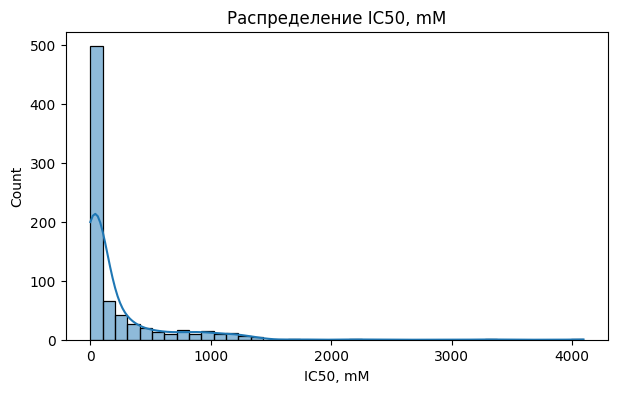

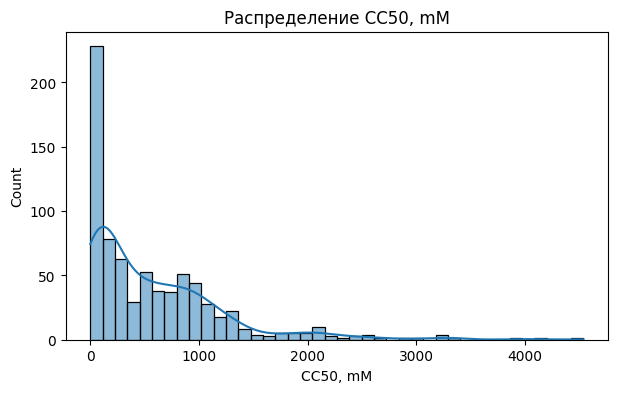

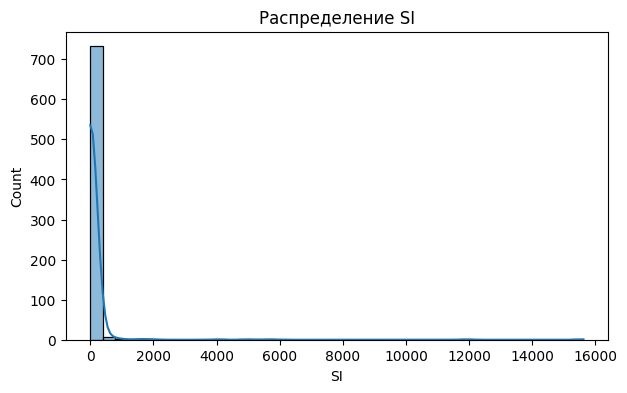

In [86]:
target_cols = ["IC50, mM", "CC50, mM", "SI"]

display(train_fe[target_cols].describe(percentiles=[0.25, 0.5, 0.75]))

for col in target_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(train_fe[col], bins=40, kde=True)
    plt.title(f"Распределение {col}")
    plt.show()


In [87]:
# Percentile thresholds


activity_thr = train_fe["IC50, mM"].quantile(0.25)  # низкий IC50 = active
inactive_thr = train_fe["IC50, mM"].quantile(0.75)

toxic_thr = train_fe["CC50, mM"].quantile(0.25)  # низкий CC50 = toxic
nontoxic_thr = train_fe["CC50, mM"].quantile(0.75)

low_si_thr = train_fe["SI"].quantile(0.25)
high_si_thr = train_fe["SI"].quantile(0.75)

print("IC50 thresholds:")
print("Active <=", activity_thr)
print("Inactive >=", inactive_thr)

print("\nCC50 thresholds:")
print("Toxic <=", toxic_thr)
print("Non-toxic >=", nontoxic_thr)

print("\nSI thresholds:")
print("Low SI <=", low_si_thr)
print("High SI >=", high_si_thr)


IC50 thresholds:
Active <= 13.222350728062665
Inactive >= 206.78740243559736

CC50 thresholds:
Toxic <= 99.99889426271551
Non-toxic >= 877.5087843465683

SI thresholds:
Low SI <= 1.5
High SI >= 17.372462804024785


In [88]:
# Biological classes


# Activity
train_fe["active"] = (train_fe["IC50, mM"] <= activity_thr).astype(int)
train_fe["inactive"] = (train_fe["IC50, mM"] >= inactive_thr).astype(int)

# Toxicity
train_fe["toxic"] = (train_fe["CC50, mM"] <= toxic_thr).astype(int)
train_fe["non_toxic"] = (train_fe["CC50, mM"] >= nontoxic_thr).astype(int)

# Selectivity
train_fe["high_selectivity"] = (train_fe["SI"] >= high_si_thr).astype(int)
train_fe["low_selectivity"] = (train_fe["SI"] <= low_si_thr).astype(int)

summary = pd.DataFrame(
    {
        "Active": train_fe["active"].value_counts(),
        "Inactive": train_fe["inactive"].value_counts(),
        "Toxic": train_fe["toxic"].value_counts(),
        "Non-toxic": train_fe["non_toxic"].value_counts(),
        "High SI": train_fe["high_selectivity"].value_counts(),
        "Low SI": train_fe["low_selectivity"].value_counts(),
    }
)

display(summary)


,Active,Inactive,Toxic,Non-toxic,High SI,Low SI
0,563,563,563,563,563,562
1,188,188,188,188,188,189


In [89]:
# Active vs inactive profiling по молекулам


compare_cols = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "NumHDonors",
    "NumHAcceptors",
    "NumRotatableBonds",
    "RingCount",
    "NumAromaticRings",
    "Ipc",
    "log_Ipc",
    "Aromatic_fraction",
    "Lipinski_violations",
]

active_profile = train_fe.loc[train_fe["active"] == 1, compare_cols].mean()

inactive_profile = train_fe.loc[train_fe["inactive"] == 1, compare_cols].mean()

comparison = pd.DataFrame(
    {"Active_mean": active_profile, "Inactive_mean": inactive_profile}
)

comparison["Difference"] = comparison["Active_mean"] - comparison["Inactive_mean"]

display(comparison.sort_values("Difference", key=abs, ascending=False))


,Active_mean,Inactive_mean,Difference
Ipc,2.765419e+09,3.654841e+09,-8.894220e+08
MolWt,3.466236e+02,3.356219e+02,1.100176e+01
NumRotatableBonds,4.595745e+00,3.154255e+00,1.441489e+00
MolLogP,3.562233e+00,3.004351e+00,5.578825e-01
NumHAcceptors,3.882979e+00,4.329787e+00,-4.468085e-01
TPSA,6.120872e+01,6.160894e+01,-4.002128e-01
NumHDonors,1.446809e+00,1.069149e+00,3.776596e-01
NumAromaticRings,1.244681e+00,1.537234e+00,-2.925532e-01
RingCount,3.223404e+00,3.441489e+00,-2.180851e-01
log_Ipc,1.273120e+01,1.256051e+01,1.706874e-01


### Сравнительный анализ активных и неактивных молекул

Для более глубокой биологической интерпретации датасета был проведён сравнительный анализ молекул с высокой и низкой противовирусной активностью.

В качестве критерия использовался показатель **IC50**, отражающий концентрацию соединения, необходимую для подавления 50% вирусной активности.

Поскольку распределение IC50 имеет выраженную асимметрию и длинный правый хвост, для формирования групп использовался percentile-based подход:

- **Активные молекулы (active)** — нижний квартиль по IC50 (25% молекул с минимальным IC50);
- **Неактивные молекулы (inactive)** — верхний квартиль по IC50 (25% молекул с максимальным IC50).

Это позволяет сравнивать наиболее контрастные группы соединений.

---

#### Основные наблюдения

**1. Активные молекулы более гибкие**

Наиболее заметное различие наблюдается по числу вращающихся связей:

- Active: **4.60**
- Inactive: **3.15**

Это указывает на то, что более активные соединения обладают большей структурной гибкостью.

С точки зрения medicinal chemistry это может быть связано с лучшей способностью молекулы адаптироваться к связывающему участку биологической мишени.

---

**2. Активные молекулы более липофильны**

Показатель **MolLogP** выше у активных соединений:

- Active: **3.56**
- Inactive: **3.00**

Это может свидетельствовать о том, что более липофильные молекулы эффективнее взаимодействуют с гидрофобными участками белков или легче проникают через клеточные мембраны.

---

**3. Активные молекулы менее ароматичны**

Наблюдается снижение ароматичности у активных соединений:

**Количество ароматических колец:**

- Active: **1.24**
- Inactive: **1.54**

**Доля ароматических колец:**

- Active: **0.36**
- Inactive: **0.43**

Это может указывать на то, что чрезмерно жёсткие ароматические структуры менее благоприятны для противовирусной активности в данной задаче.

---

**4. Различия в водородных связях**

Активные соединения демонстрируют следующий паттерн:

**Доноры водородной связи:**

- Active: **1.45**
- Inactive: **1.07**

**Акцепторы водородной связи:**

- Active: **3.88**
- Inactive: **4.33**

Это может отражать различия в механизмах связывания с биологической мишенью.

---

**5. Активные молекулы немного структурно сложнее**

По логарифмированному индексу структурной сложности:

- Active: **12.73**
- Inactive: **12.56**

Разница невелика, однако тенденция присутствует.

---

**6. Максимальная активность не всегда соответствует идеальной drug-likeness**

Среднее число нарушений правила Липински:

- Active: **0.34**
- Inactive: **0.27**

Это интересное наблюдение, показывающее, что наиболее активные молекулы не обязательно являются наиболее "фармацевтически удобными" с точки зрения классических drug-likeness критериев.

---

### Вывод

Сравнительный анализ показывает, что более активные противовирусные соединения в данном датасете, как правило:

- обладают большей структурной гибкостью;
- имеют более высокую липофильность;
- менее ароматичны;
- немного более структурно сложны;
- не всегда строго соответствуют классическим drug-likeness ограничениям.

Полученные закономерности могут быть полезны как для интерпретации данных, так и для дальнейшего feature engineering и построения моделей.

## Токсичность: toxic vs non-toxic


In [90]:
# Toxic vs non-toxic profiling

compare_cols = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "NumHDonors",
    "NumHAcceptors",
    "NumRotatableBonds",
    "RingCount",
    "NumAromaticRings",
    "Ipc",
    "log_Ipc",
    "Aromatic_fraction",
    "Lipinski_violations",
]

toxic_profile = train_fe.loc[train_fe["toxic"] == 1, compare_cols].mean()

nontoxic_profile = train_fe.loc[train_fe["non_toxic"] == 1, compare_cols].mean()

tox_comparison = pd.DataFrame(
    {"Toxic_mean": toxic_profile, "Non_toxic_mean": nontoxic_profile}
)

tox_comparison["Difference"] = (
    tox_comparison["Toxic_mean"] - tox_comparison["Non_toxic_mean"]
)

display(tox_comparison.sort_values("Difference", key=abs, ascending=False))


,Toxic_mean,Non_toxic_mean,Difference
Ipc,8.745063e+08,3.312177e+07,8.413846e+08
MolWt,3.654942e+02,2.725098e+02,9.298436e+01
TPSA,6.435048e+01,4.568420e+01,1.866628e+01
log_Ipc,1.346392e+01,1.024240e+01,3.221526e+00
NumRotatableBonds,4.313830e+00,2.329787e+00,1.984043e+00
NumHAcceptors,4.223404e+00,3.079787e+00,1.143617e+00
MolLogP,3.740176e+00,2.633155e+00,1.107022e+00
RingCount,3.569149e+00,2.835106e+00,7.340426e-01
NumAromaticRings,1.468085e+00,8.563830e-01,6.117021e-01
NumHDonors,1.473404e+00,9.361702e-01,5.372340e-01


### Сравнительный анализ токсичных и нетоксичных молекул

Поскольку задача включает не только предсказание противовирусной активности, но и оценку безопасности соединений, был проведён отдельный сравнительный анализ токсичных и нетоксичных молекул.

В качестве критерия использовался показатель **CC50**, отражающий концентрацию вещества, токсичную для 50% клеток.

Поскольку распределение CC50 также имеет выраженную асимметрию и длинный правый хвост, использовался percentile-based подход:

- **Токсичные молекулы (toxic)** — нижний квартиль по CC50 (25% соединений с минимальным CC50);
- **Нетоксичные молекулы (non-toxic)** — верхний квартиль по CC50 (25% соединений с максимальным CC50).

Это позволяет сравнивать наиболее контрастные группы соединений с точки зрения клеточной токсичности.

---

#### Основные наблюдения

**1. Токсичные молекулы существенно тяжелее**

Средняя молекулярная масса:

- Toxic: **365**
- Non-toxic: **273**

Разница почти в **100 единиц молекулярной массы**, что является заметным эффектом.

Это указывает на связь увеличенного размера молекулы с ростом токсичности.

---

**2. Токсичные молекулы значительно более структурно сложные**

По индексу структурной сложности:

**log(Ipc):**

- Toxic: **13.46**
- Non-toxic: **10.24**

Это один из наиболее выраженных сигналов во всём анализе.

Можно предположить, что более сложные молекулярные структуры чаще связаны с повышенной неспецифической биологической активностью и, как следствие, большей токсичностью.

---

**3. Токсичные молекулы более липофильные**

Показатель **MolLogP**:

- Toxic: **3.74**
- Non-toxic: **2.63**

Это сильное различие.

С точки зрения medicinal chemistry это хорошо согласуется с классическим наблюдением о том, что чрезмерная липофильность часто связана с ростом off-target взаимодействий, неспецифического связывания и клеточной токсичности.

---

**4. Токсичные молекулы более гибкие**

Число вращающихся связей:

- Toxic: **4.31**
- Non-toxic: **2.33**

Почти двукратное различие.

Это указывает на потенциальную связь повышенной структурной гибкости с токсичностью.

---

**5. Токсичные молекулы более ароматичны**

Количество ароматических колец:

- Toxic: **1.47**
- Non-toxic: **0.86**

Доля ароматических колец:

- Toxic: **0.42**
- Non-toxic: **0.29**

Это говорит о том, что токсичные соединения в среднем обладают более жёсткой ароматической архитектурой.

---

**6. Токсичные молекулы имеют больше доноров и акцепторов водородных связей**

Акцепторы:

- Toxic: **4.22**
- Non-toxic: **3.08**

Доноры:

- Toxic: **1.47**
- Non-toxic: **0.94**

Это может отражать более сложную и насыщенную функциональными группами химическую структуру токсичных соединений.

---

**7. Токсичные молекулы хуже соответствуют drug-likeness критериям**

Среднее число нарушений правила Липински:

- Toxic: **0.47**
- Non-toxic: **0.07**

Это сильный сигнал, показывающий, что токсичные соединения заметно хуже соответствуют классическим фармакологическим ограничениям.

---

### Ключевое наблюдение

Особенно важно, что некоторые свойства, связанные с повышенной противовирусной активностью, одновременно связаны и с повышенной токсичностью.

В частности:

- повышенная липофильность;
- большая структурная гибкость.

Это указывает на типичный medicinal chemistry trade-off:

**усиление активности не всегда приводит к улучшению терапевтического профиля, поскольку может сопровождаться ростом токсичности.**

---

### Вывод

Токсичные соединения в данном датасете, как правило:

- крупнее;
- структурно сложнее;
- более липофильны;
- более гибкие;
- более ароматичны;
- хуже соответствуют классическим drug-likeness критериям.

Полученные закономерности подтверждают биологическую осмысленность признакового пространства и важность отдельного анализа селективности соединений.

## Селективность: high vs low SI


In [91]:
# High SI vs Low SI profiling


compare_cols = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "NumHDonors",
    "NumHAcceptors",
    "NumRotatableBonds",
    "RingCount",
    "NumAromaticRings",
    "Ipc",
    "log_Ipc",
    "Aromatic_fraction",
    "Lipinski_violations",
    "Lipinski_pass",
    "Veber_pass",
]

high_si_profile = train_fe.loc[train_fe["high_selectivity"] == 1, compare_cols].mean()

low_si_profile = train_fe.loc[train_fe["low_selectivity"] == 1, compare_cols].mean()

si_comparison = pd.DataFrame(
    {"High_SI_mean": high_si_profile, "Low_SI_mean": low_si_profile}
)

si_comparison["Difference"] = (
    si_comparison["High_SI_mean"] - si_comparison["Low_SI_mean"]
)

display(si_comparison.sort_values("Difference", key=abs, ascending=False))


,High_SI_mean,Low_SI_mean,Difference
Ipc,3.150504e+09,2.153407e+11,-2.121902e+11
MolWt,3.260163e+02,3.647352e+02,-3.871891e+01
TPSA,5.571266e+01,6.958434e+01,-1.387168e+01
log_Ipc,1.207095e+01,1.359524e+01,-1.524293e+00
NumHAcceptors,3.680851e+00,4.777778e+00,-1.096927e+00
NumRotatableBonds,4.494681e+00,3.820106e+00,6.745750e-01
NumAromaticRings,9.627660e-01,1.576720e+00,-6.139536e-01
RingCount,3.085106e+00,3.698413e+00,-6.133063e-01
Aromatic_fraction,2.618604e-01,4.310280e-01,-1.691675e-01
Lipinski_violations,3.351064e-01,4.867725e-01,-1.516661e-01


## Сравнительный анализ селективных и неселективных молекул

Наиболее важным практическим критерием в данной задаче является не только высокая противовирусная активность или низкая токсичность по отдельности, но и их баланс.

Для этого используется показатель **SI (Selectivity Index)**:

\[
SI = \frac{CC50}{IC50}
\]

Высокий SI означает, что соединение эффективно подавляет вирус при относительно низкой токсичности для клеток, что делает его значительно более перспективным с терапевтической точки зрения.

Для анализа использовался percentile-based подход:

- **High SI (селективные молекулы)** — верхний квартиль по SI (25% соединений с максимальным SI);
- **Low SI (неселективные молекулы)** — нижний квартиль по SI (25% соединений с минимальным SI).

Это позволяет сравнить наиболее контрастные группы с точки зрения терапевтической перспективности.

---

#### Основные наблюдения

**1. Селективные молекулы менее структурно сложные**

По индексу структурной сложности:

**log(Ipc):**

- High SI: **12.07**
- Low SI: **13.60**

Это один из наиболее выраженных сигналов анализа.

Можно предположить, что чрезмерно сложные молекулярные структуры чаще связаны с ростом неспецифических взаимодействий и ухудшением терапевтического профиля.

---

**2. Селективные молекулы легче**

Средняя молекулярная масса:

- High SI: **326**
- Low SI: **365**

Это указывает на тенденцию к лучшему терапевтическому профилю у менее массивных соединений.

---

**3. Селективные молекулы менее полярны**

Показатель **TPSA**:

- High SI: **55.7**
- Low SI: **69.6**

Различие достаточно заметное.

Это может указывать на то, что чрезмерно высокая полярность в данной задаче не способствует оптимальному терапевтическому балансу.

---

**4. Селективные молекулы имеют меньше акцепторов водородной связи**

Число акцепторов:

- High SI: **3.68**
- Low SI: **4.78**

Это также указывает на более компактный и менее перегруженный функциональными группами химический профиль.

---

**5. Селективные молекулы значительно менее ароматичны**

Количество ароматических колец:

- High SI: **0.96**
- Low SI: **1.58**

Доля ароматических колец:

- High SI: **0.26**
- Low SI: **0.43**

Это один из наиболее интересных результатов анализа.

Он указывает на возможную связь повышенной ароматичности и жёсткости структуры с ухудшением селективности.

---

**6. Селективные молекулы немного более гибкие**

Число вращающихся связей:

- High SI: **4.49**
- Low SI: **3.82**

Это может отражать преимущество более адаптивных структур с точки зрения взаимодействия с биологической мишенью.

---

**7. Селективные молекулы лучше соответствуют drug-likeness критериям**

Среднее число нарушений правила Липински:

- High SI: **0.34**
- Low SI: **0.49**

Доля молекул, полностью проходящих правило Липински:

- High SI: **77.7%**
- Low SI: **69.8%**

Это подтверждает, что более "фармакологически аккуратные" молекулы обладают лучшим терапевтическим профилем.

---

**8. Липофильность не является ключевым отличием**

MolLogP:

- High SI: **3.28**
- Low SI: **3.21**

Различие минимально.

Это важное наблюдение, поскольку показывает, что липофильность сама по себе не определяет селективность.

---

### Ключевой вывод

Наиболее перспективные соединения (High SI) в данном датасете, как правило:

- менее сложные;
- менее тяжёлые;
- менее ароматичные;
- менее полярные;
- имеют меньше акцепторов водородной связи;
- немного более гибкие;
- лучше соответствуют классическим drug-likeness критериям.

Особенно важен тот факт, что свойства, повышающие токсичность (структурная сложность, высокая ароматичность, увеличение массы), одновременно ухудшают селективность.

---

### Итоговая medicinal chemistry гипотеза

Потенциально наиболее перспективные противовирусные кандидаты в данной задаче — это **относительно компактные, умеренно гибкие, не чрезмерно ароматичные и структурно не перегруженные молекулы с хорошим drug-like профилем.**

## Fragment enrichment analysis


In [92]:
# 13. Fragment enrichment: High SI vs Low SI


high_si_frag_freq = train_fe.loc[
    train_fe["high_selectivity"] == 1, fragment_cols
].mean()

low_si_frag_freq = train_fe.loc[train_fe["low_selectivity"] == 1, fragment_cols].mean()

fragment_si_enrichment = pd.DataFrame(
    {"High_SI_freq": high_si_frag_freq, "Low_SI_freq": low_si_frag_freq}
)

fragment_si_enrichment["Difference"] = (
    fragment_si_enrichment["High_SI_freq"] - fragment_si_enrichment["Low_SI_freq"]
)

fragment_si_enrichment["Abs_difference"] = fragment_si_enrichment["Difference"].abs()

display(fragment_si_enrichment.sort_values("Abs_difference", ascending=False).head(20))


,High_SI_freq,Low_SI_freq,Difference,Abs_difference
fr_benzene,0.622340,1.068783,-0.446443,0.446443
fr_ether,0.728723,1.132275,-0.403552,0.403552
fr_halogen,0.398936,0.708995,-0.310059,0.310059
fr_alkyl_halide,0.234043,0.539683,-0.305640,0.305640
fr_Imine,0.356383,0.074074,0.282309,0.282309
fr_C_O_noCOO,0.632979,0.904762,-0.271783,0.271783
fr_C_O,0.712766,0.962963,-0.250197,0.250197
fr_allylic_oxid,0.122340,0.370370,-0.248030,0.248030
fr_unbrch_alkane,0.340426,0.105820,0.234605,0.234605
fr_bicyclic,1.420213,1.243386,0.176827,0.176827


## Анализ химических фрагментов: селективные vs неселективные молекулы

Для более детальной medicinal chemistry интерпретации был проведён анализ обогащения химических фрагментов в группах селективных (**High SI**) и неселективных (**Low SI**) соединений.

Сравнивалась средняя частота встречаемости бинарных fragment-дескрипторов (`fr_*`) между двумя группами.

---

#### Основные наблюдения

**Фрагменты, чаще встречающиеся у Low SI (нежелательный профиль):**

- **fr_benzene**
- **fr_ether**
- **fr_halogen**
- **fr_alkyl_halide**
- **fr_C_O / fr_C_O_noCOO**
- **fr_allylic_oxid**
- **fr_methoxy**
- **fr_phenol / fr_Ar_OH**

Это указывает на то, что низкая селективность чаще ассоциирована с:

- повышенной ароматичностью;
- большим числом кислородсодержащих функциональных групп;
- наличием галогенов;
- более химически "жёсткими" и функционально насыщенными структурами.

Особенно хорошо это согласуется с предыдущими наблюдениями о том, что менее селективные молекулы в среднем более ароматичны и структурно сложны.

---

**Фрагменты, чаще встречающиеся у High SI (более перспективный профиль):**

- **fr_imine**
- **fr_unbrch_alkane**
- **fr_bicyclic**
- **fr_Ndealkylation1**
- **fr_quatN**

Это может говорить о том, что более селективные соединения чаще обладают:

- менее перегруженной ароматической архитектурой;
- более "алифатическим" характером;
- большей структурной гибкостью;
- более специфическими азотсодержащими функциональными группами.

---

### Вывод

Анализ фрагментов показывает, что снижение селективности чаще связано с:

- ароматическими ядрами;
- галогенированными структурами;
- кислородсодержащими функциональными группами.

В то же время более селективные соединения демонстрируют смещение в сторону менее ароматичных и более алифатических структур.

Эти результаты хорошо согласуются с предыдущим анализом физико-химических свойств и усиливают гипотезу о том, что **чрезмерная структурная жёсткость и высокая функциональная насыщенность могут ухудшать терапевтический профиль соединений.**

## Фрагменты: active/inactive и toxic/non-toxic


In [93]:
# Fragment enrichment: Active vs Inactive


active_frag_freq = train_fe.loc[train_fe["active"] == 1, fragment_cols].mean()

inactive_frag_freq = train_fe.loc[train_fe["inactive"] == 1, fragment_cols].mean()

fragment_activity_enrichment = pd.DataFrame(
    {"Active_freq": active_frag_freq, "Inactive_freq": inactive_frag_freq}
)

fragment_activity_enrichment["Difference"] = (
    fragment_activity_enrichment["Active_freq"]
    - fragment_activity_enrichment["Inactive_freq"]
)

fragment_activity_enrichment["Abs_difference"] = fragment_activity_enrichment[
    "Difference"
].abs()

display(
    fragment_activity_enrichment.sort_values("Abs_difference", ascending=False).head(20)
)


,Active_freq,Inactive_freq,Difference,Abs_difference
fr_NH0,0.984043,1.356383,-0.372340,0.372340
fr_alkyl_halide,0.308511,0.664894,-0.356383,0.356383
fr_halogen,0.574468,0.893617,-0.319149,0.319149
fr_ether,0.776596,1.063830,-0.287234,0.287234
fr_Ar_N,0.351064,0.617021,-0.265957,0.265957
fr_NH1,0.590426,0.345745,0.244681,0.244681
fr_C_O,0.968085,0.728723,0.239362,0.239362
fr_NH2,0.255319,0.042553,0.212766,0.212766
fr_C_O_noCOO,0.877660,0.664894,0.212766,0.212766
fr_unbrch_alkane,0.324468,0.127660,0.196809,0.196809


In [94]:
# Fragment enrichment: Toxic vs Non-toxic


toxic_frag_freq = train_fe.loc[train_fe["toxic"] == 1, fragment_cols].mean()

nontoxic_frag_freq = train_fe.loc[train_fe["non_toxic"] == 1, fragment_cols].mean()

fragment_toxicity_enrichment = pd.DataFrame(
    {"Toxic_freq": toxic_frag_freq, "Non_toxic_freq": nontoxic_frag_freq}
)

fragment_toxicity_enrichment["Difference"] = (
    fragment_toxicity_enrichment["Toxic_freq"]
    - fragment_toxicity_enrichment["Non_toxic_freq"]
)

fragment_toxicity_enrichment["Abs_difference"] = fragment_toxicity_enrichment[
    "Difference"
].abs()

display(
    fragment_toxicity_enrichment.sort_values("Abs_difference", ascending=False).head(20)
)


,Toxic_freq,Non_toxic_freq,Difference,Abs_difference
fr_benzene,1.143617,0.446809,0.696809,0.696809
fr_C_O,1.069149,0.468085,0.601064,0.601064
fr_C_O_noCOO,1.005319,0.462766,0.542553,0.542553
fr_allylic_oxid,0.595745,0.196809,0.398936,0.398936
fr_ketone,0.319149,0.047872,0.271277,0.271277
fr_aniline,0.367021,0.106383,0.260638,0.260638
fr_NH1,0.595745,0.361702,0.234043,0.234043
fr_phenol_noOrthoHbond,0.212766,0.005319,0.207447,0.207447
fr_phenol,0.212766,0.005319,0.207447,0.207447
fr_Ar_OH,0.223404,0.015957,0.207447,0.207447


### Анализ химических фрагментов: активность и токсичность

Для более глубокой medicinal chemistry интерпретации был проведён анализ обогащения химических фрагментов (`fr_*`) в различных биологических группах.

Сравнивалась средняя частота встречаемости бинарных fragment-дескрипторов между контрастными группами соединений.

---

## Фрагменты, связанные с противовирусной активностью

Сравнивались:

- **Active** — молекулы с низким IC50 (высокая активность)
- **Inactive** — молекулы с высоким IC50 (низкая активность)

### Основные наблюдения

**Чаще у активных соединений:**

- `fr_NH1`
- `fr_NH2`
- `fr_C_O`
- `fr_C_O_noCOO`
- `fr_unbrch_alkane`
- `fr_allylic_oxid`

Это указывает на связь активности с:

- азотсодержащими функциональными группами;
- карбонильными структурами;
- менее ароматичными алифатическими мотивами.

---

**Чаще у неактивных соединений:**

- `fr_NH0`
- `fr_alkyl_halide`
- `fr_halogen`
- `fr_ether`
- `fr_Ar_N`
- `fr_Al_OH`
- `fr_methoxy`

Это может говорить о том, что высокая активность хуже ассоциирована с:

- галогенированными структурами;
- ароматическими азотсодержащими мотивами;
- эфирными и метоксильными группами.

---

## Фрагменты, связанные с токсичностью

Сравнивались:

- **Toxic** — низкий CC50
- **Non-toxic** — высокий CC50

### Основные наблюдения

**Чаще у токсичных соединений:**

- `fr_benzene`
- `fr_C_O`
- `fr_C_O_noCOO`
- `fr_allylic_oxid`
- `fr_ketone`
- `fr_aniline`
- `fr_NH1`
- `fr_phenol`
- `fr_Ar_OH`
- `fr_ester`

Это формирует достаточно характерный токсичный профиль:

- высокая ароматичность;
- кислородсодержащие функциональные группы;
- фенольные и анилиновые мотивы;
- повышенная функциональная насыщенность структуры.

---

**Чаще у нетоксичных соединений:**

- `fr_imine`
- `fr_alkyl_halide`
- `fr_Al_OH`

Хотя различия здесь менее выражены.

---

## Итоговый вывод

Фрагментный анализ хорошо согласуется с предыдущими результатами по физико-химическим свойствам.

Получается следующая картина:

**Более активные соединения:**

- чаще содержат азотсодержащие и карбонильные группы;
- чаще имеют менее ароматический и более алифатический характер.

**Более токсичные соединения:**

- значительно чаще содержат ароматические ядра;
- фенольные и анилиновые фрагменты;
- структурно более насыщенные кислородсодержащие группы.

Это дополнительно подтверждает гипотезу о том, что **повышенная ароматичность и структурная перегруженность могут ухудшать терапевтический профиль соединений.**

## Trade-off: активность, токсичность, селективность


## Анализ соотношения активности и токсичности

,"IC50, mM","CC50, mM",SI
MolWt,-0.142172,-0.305003,-0.047341
MolLogP,-0.189704,-0.215012,-0.087762
TPSA,-0.008089,-0.149913,0.039866
NumHDonors,-0.037353,-0.126006,0.053380
NumHAcceptors,-0.016897,-0.153826,-0.013468
NumRotatableBonds,-0.166048,-0.197941,0.054599
RingCount,-0.128256,-0.238274,-0.141653
NumAromaticRings,-0.025130,-0.171440,-0.097596
log_Ipc,-0.143710,-0.291470,-0.061335
Aromatic_fraction,0.064321,-0.120058,-0.102004


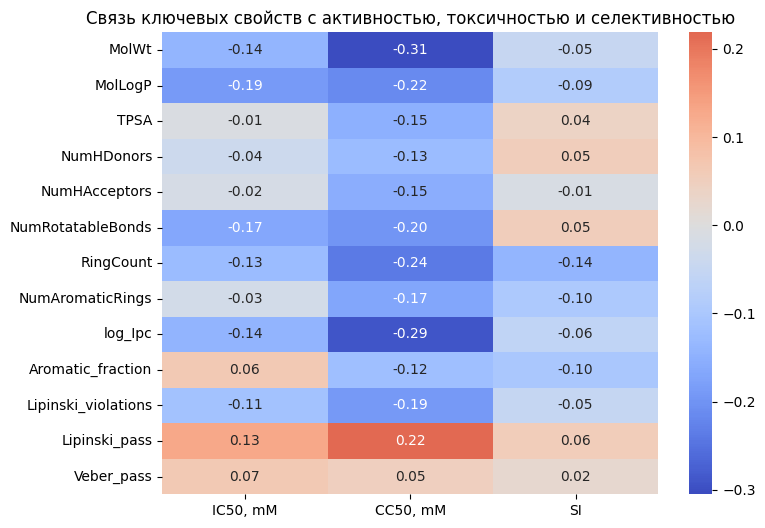

In [95]:
# Activity–toxicity trade-off analysis


key_property_cols = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "NumHDonors",
    "NumHAcceptors",
    "NumRotatableBonds",
    "RingCount",
    "NumAromaticRings",
    "log_Ipc",
    "Aromatic_fraction",
    "Lipinski_violations",
    "Lipinski_pass",
    "Veber_pass",
]

tradeoff_corr = (
    train_fe[key_property_cols + target_cols].corr().loc[key_property_cols, target_cols]
)

display(tradeoff_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(tradeoff_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Связь ключевых свойств с активностью, токсичностью и селективностью")
plt.show()


### Анализ trade-off между активностью, токсичностью и селективностью

Для оценки взаимосвязи между ключевыми физико-химическими свойствами и биологическими характеристиками соединений был проведён корреляционный анализ.

Рассматривались связи между химическими признаками и основными таргетами:

- **IC50** — противовирусная активность;
- **CC50** — клеточная токсичность;
- **SI** — селективность.

---

#### Основные наблюдения

**Липофильность (MolLogP)** демонстрирует классический medicinal chemistry trade-off:

- более высокая липофильность связана с улучшением активности (снижение IC50),
- но одновременно ассоциирована с ростом токсичности (снижение CC50).

Это типичный компромисс между эффективностью и безопасностью.

---

**Молекулярная масса (MolWt)** показывает аналогичный паттерн:

- более тяжёлые молекулы немного активнее,
- однако заметно более токсичны.

Следовательно, увеличение размера молекулы не приводит к улучшению общего терапевтического профиля.

---

**Структурная сложность (log(Ipc))** также демонстрирует неблагоприятный баланс:

- небольшое улучшение активности,
- выраженное ухудшение токсичности.

Это указывает на то, что чрезмерная структурная сложность может быть нежелательной.

---

**Гибкость молекулы (NumRotatableBonds)** выглядит более интересным компромиссным фактором:

- способствует повышению активности,
- умеренно увеличивает токсичность,
- при этом слабо положительно связана с селективностью.

Это делает гибкость потенциально полезной характеристикой.

---

**Ароматичность** демонстрирует устойчиво неблагоприятный профиль:

- более высокая ароматичность связана с ухудшением активности;
- ростом токсичности;
- снижением селективности.

Это хорошо согласуется с предыдущими наблюдениями по сравнительному анализу групп.

---

**Drug-likeness признаки** показывают более благоприятный профиль:

Молекулы, соответствующие правилу Липински:

- менее токсичны;
- немного более селективны;
- хотя могут быть несколько менее активными.

---

### Вывод

Корреляционный анализ подтверждает наличие выраженного компромисса между активностью и безопасностью.

Свойства, повышающие активность (липофильность, масса, структурная сложность), одновременно часто ухудшают токсикологический профиль.

Наиболее перспективными выглядят молекулы, сочетающие:

- умеренную гибкость;
- низкую ароматичность;
- умеренную структурную сложность;
- хороший drug-like профиль.

## Корреляция между ключевыми молекулярными свойствами

,MolWt,MolLogP,TPSA,NumHDonors,NumHAcceptors,NumRotatableBonds,RingCount,NumAromaticRings,log_Ipc,Aromatic_fraction,Lipinski_violations
MolWt,1.00,0.41,0.57,0.20,0.70,0.69,0.68,0.66,0.98,0.35,0.81
MolLogP,0.41,1.00,-0.43,-0.53,-0.22,0.37,0.44,0.27,0.43,0.10,0.35
TPSA,0.57,-0.43,1.00,0.75,0.88,0.32,0.23,0.45,0.54,0.34,0.48
NumHDonors,0.20,-0.53,0.75,1.00,0.48,0.10,-0.11,0.05,0.15,0.11,0.23
NumHAcceptors,0.70,-0.22,0.88,0.48,1.00,0.39,0.45,0.64,0.70,0.41,0.63
NumRotatableBonds,0.69,0.37,0.32,0.10,0.39,1.00,0.23,0.25,0.67,0.11,0.59
RingCount,0.68,0.44,0.23,-0.11,0.45,0.23,1.00,0.61,0.75,0.15,0.62
NumAromaticRings,0.66,0.27,0.45,0.05,0.64,0.25,0.61,1.00,0.71,0.80,0.55
log_Ipc,0.98,0.43,0.54,0.15,0.70,0.67,0.75,0.71,1.00,0.36,0.81
Aromatic_fraction,0.35,0.10,0.34,0.11,0.41,0.11,0.15,0.80,0.36,1.00,0.20


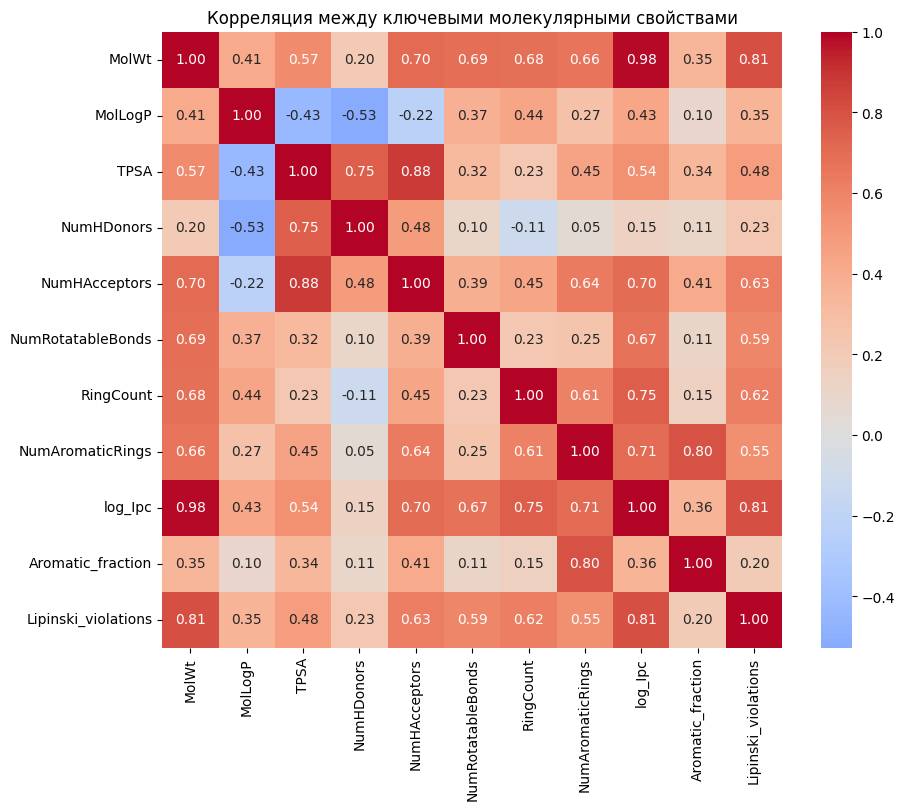

In [96]:
# Correlation between key molecular properties


property_cols = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "NumHDonors",
    "NumHAcceptors",
    "NumRotatableBonds",
    "RingCount",
    "NumAromaticRings",
    "log_Ipc",
    "Aromatic_fraction",
    "Lipinski_violations",
]

property_corr = train_fe[property_cols].corr()

display(property_corr.round(2))

plt.figure(figsize=(10, 8))
sns.heatmap(property_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")

plt.title("Корреляция между ключевыми молекулярными свойствами")
plt.show()


### Корреляция между ключевыми молекулярными свойствами

Для более глубокого понимания структуры признакового пространства был проведён корреляционный анализ между основными физико-химическими характеристиками молекул.

Цель анализа — определить, какие признаки несут независимый сигнал, а какие в значительной степени дублируют друг друга.

---

#### Основные наблюдения

**1. Молекулярная масса и структурная сложность практически полностью коррелируют**

Наиболее сильная связь наблюдается между:

- **MolWt** и **log(Ipc)** (**r = 0.98**)

Это практически полное совпадение сигнала.

Фактически оба признака описывают один и тот же аспект молекулы — её общий размер и структурную сложность.

---

**2. Выделяется выраженный кластер полярных признаков**

Сильные корреляции наблюдаются между:

- **TPSA ↔ NumHAcceptors** (**r = 0.88**)
- **TPSA ↔ NumHDonors** (**r = 0.75**)

Это ожидаемо, поскольку увеличение числа доноров и акцепторов водородных связей напрямую связано с ростом полярности молекулы.

Таким образом, данные признаки формируют единый polarity-блок.

---

**3. Ароматические признаки также тесно связаны**

Наблюдается сильная связь между:

- **NumAromaticRings ↔ Aromatic_fraction** (**r = 0.80**)

Это указывает на то, что оба признака описывают схожий аспект химической структуры — степень ароматичности молекулы.

---

**4. Drug-likeness нарушения тесно связаны со структурной сложностью**

Высокие корреляции:

- **Lipinski_violations ↔ MolWt** (**r = 0.81**)
- **Lipinski_violations ↔ log(Ipc)** (**r = 0.81**)

Это логично, поскольку более крупные и сложные молекулы чаще выходят за пределы классических drug-like ограничений.

---

#### Формирующиеся смысловые кластеры признаков

По результатам анализа можно выделить несколько устойчивых групп:

**Structural complexity cluster:**

- MolWt
- log(Ipc)
- RingCount
- Lipinski_violations

---

**Polarity cluster:**

- TPSA
- NumHDonors
- NumHAcceptors

---

**Aromaticity cluster:**

- NumAromaticRings
- Aromatic_fraction

---

**Относительно независимые признаки:**

- MolLogP
- NumRotatableBonds

Именно эти признаки могут нести наиболее самостоятельный сигнал.

---

### Вывод

Признаковое пространство содержит несколько хорошо интерпретируемых химических кластеров.

Это подтверждает биологическую осмысленность используемых дескрипторов.

При этом высокая корреляция между отдельными признаками не является критичной на данном этапе, поскольку основными кандидатами для моделирования рассматриваются tree-based алгоритмы, устойчивые к мультиколлинеарности.

Тем не менее данное наблюдение важно учитывать при дальнейшей feature selection и интерпретации моделей.

## Итоговое target-aware summary


In [97]:
# Final target-aware summary

target_cols = ["IC50, mM", "CC50, mM", "SI"]

summary_rows = []

for target in target_cols:
    summary_rows.append(
        {
            "Target": target,
            "Meaning": {
                "IC50, mM": "Antiviral activity: lower is better",
                "CC50, mM": "Cell toxicity: higher is better",
                "SI": "Selectivity index: higher is better",
            }[target],
            "Min": train_fe[target].min(),
            "Q25": train_fe[target].quantile(0.25),
            "Median": train_fe[target].median(),
            "Q75": train_fe[target].quantile(0.75),
            "Max": train_fe[target].max(),
            "Skew": train_fe[target].skew(),
        }
    )

target_summary = pd.DataFrame(summary_rows)

display(target_summary)


,Target,Meaning,Min,Q25,Median,Q75,Max,Skew
0,"IC50, mM",Antiviral activity: lower is better,0.003517,13.222351,44.069306,206.787402,4095.188563,3.787381
1,"CC50, mM",Cell toxicity: higher is better,0.700808,99.998894,376.580899,877.508784,4538.976189,2.056306
2,SI,Selectivity index: higher is better,0.011489,1.500000,4.000000,17.372463,15620.600000,15.634965


### Summary по биологическим паттернам


## Финальная biological-кластеризация (EDA)


In [98]:
train_fe.columns[train_fe.columns.str.contains("cluster", case=False)]


Index([], dtype='str')

In [99]:
exclude_cols = [
    "index",
    "IC50, mM",
    "CC50, mM",
    "SI",
    "active",
    "inactive",
    "toxic",
    "non_toxic",
    "high_selectivity",
    "low_selectivity",
]

feature_cols = [col for col in train_fe.columns if col not in exclude_cols]

X_cluster = train_fe[feature_cols].copy()

imputer = SimpleImputer(strategy="median")
X_cluster_imputed = imputer.fit_transform(X_cluster)

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster_imputed)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

train_fe["cluster"] = kmeans.fit_predict(X_cluster_scaled)

print(train_fe["cluster"].value_counts())


cluster
0    333
3    244
4     97
2     44
1     33
Name: count, dtype: int64


In [100]:
# Cluster biological profiling

cluster_profile = (
    train_fe.groupby("cluster")
    .agg(
        n_objects=("SI", "size"),
        IC50_median=("IC50, mM", "median"),
        CC50_median=("CC50, mM", "median"),
        SI_median=("SI", "median"),
        IC50_mean=("IC50, mM", "mean"),
        CC50_mean=("CC50, mM", "mean"),
        SI_mean=("SI", "mean"),
        active_rate=("active", "mean"),
        toxic_rate=("toxic", "mean"),
        high_selectivity_rate=("high_selectivity", "mean"),
    )
    .sort_values("SI_median", ascending=False)
)

display(cluster_profile)


,n_objects,IC50_median,CC50_median,SI_median,IC50_mean,CC50_mean,SI_mean,active_rate,toxic_rate,high_selectivity_rate
cluster,,,,,,,,,,
3,244,33.164477,304.827722,7.655128,147.844883,702.656612,64.087529,0.295082,0.229508,0.368852
1,33,28.930019,199.999127,5.238095,120.689435,215.471732,31.888371,0.333333,0.363636,0.151515
4,97,63.389616,447.951072,3.157895,131.986547,364.381129,9.221885,0.175258,0.247423,0.175258
2,44,30.999338,148.056709,3.059731,86.669451,389.380297,16.216799,0.181818,0.318182,0.295455
0,333,83.319304,511.856647,3.000000,291.109628,608.439990,146.115325,0.240240,0.246246,0.189189


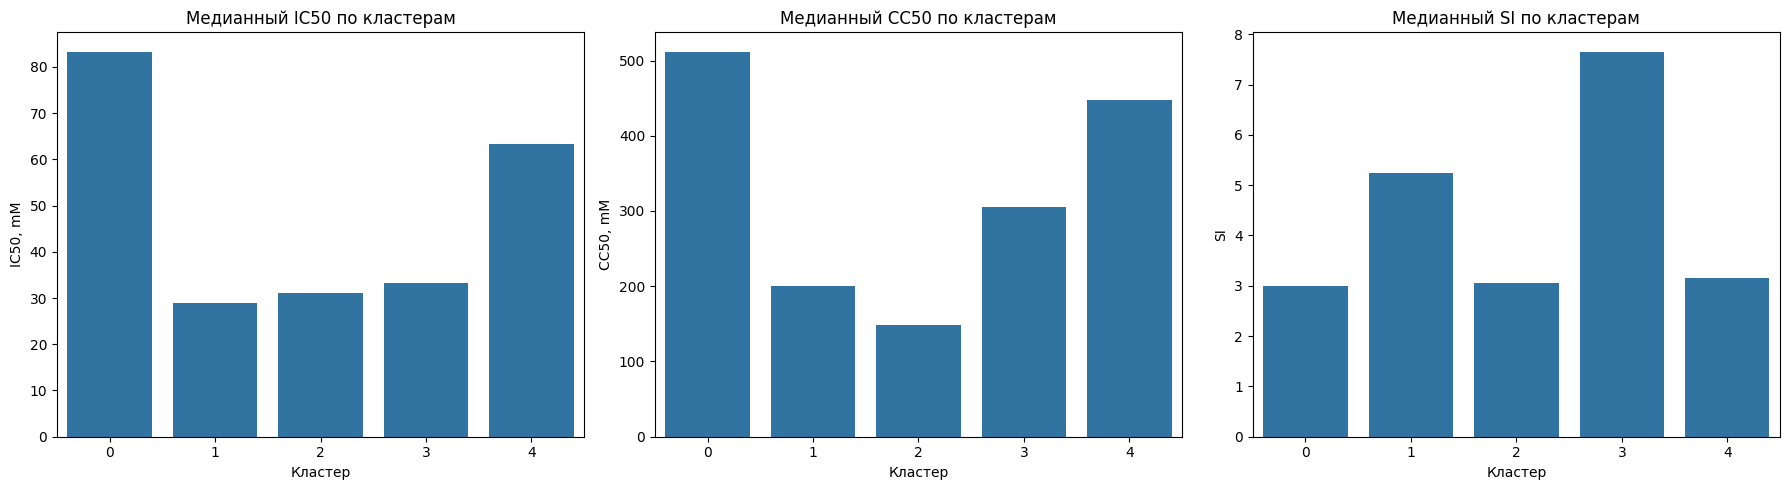

In [101]:
# визуал
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=cluster_profile.reset_index(), x="cluster", y="IC50_median", ax=axes[0]
)
axes[0].set_title("Медианный IC50 по кластерам")
axes[0].set_xlabel("Кластер")
axes[0].set_ylabel("IC50, mM")

sns.barplot(
    data=cluster_profile.reset_index(), x="cluster", y="CC50_median", ax=axes[1]
)
axes[1].set_title("Медианный CC50 по кластерам")
axes[1].set_xlabel("Кластер")
axes[1].set_ylabel("CC50, mM")

sns.barplot(data=cluster_profile.reset_index(), x="cluster", y="SI_median", ax=axes[2])
axes[2].set_title("Медианный SI по кластерам")
axes[2].set_xlabel("Кластер")
axes[2].set_ylabel("SI")

plt.tight_layout()
plt.show()


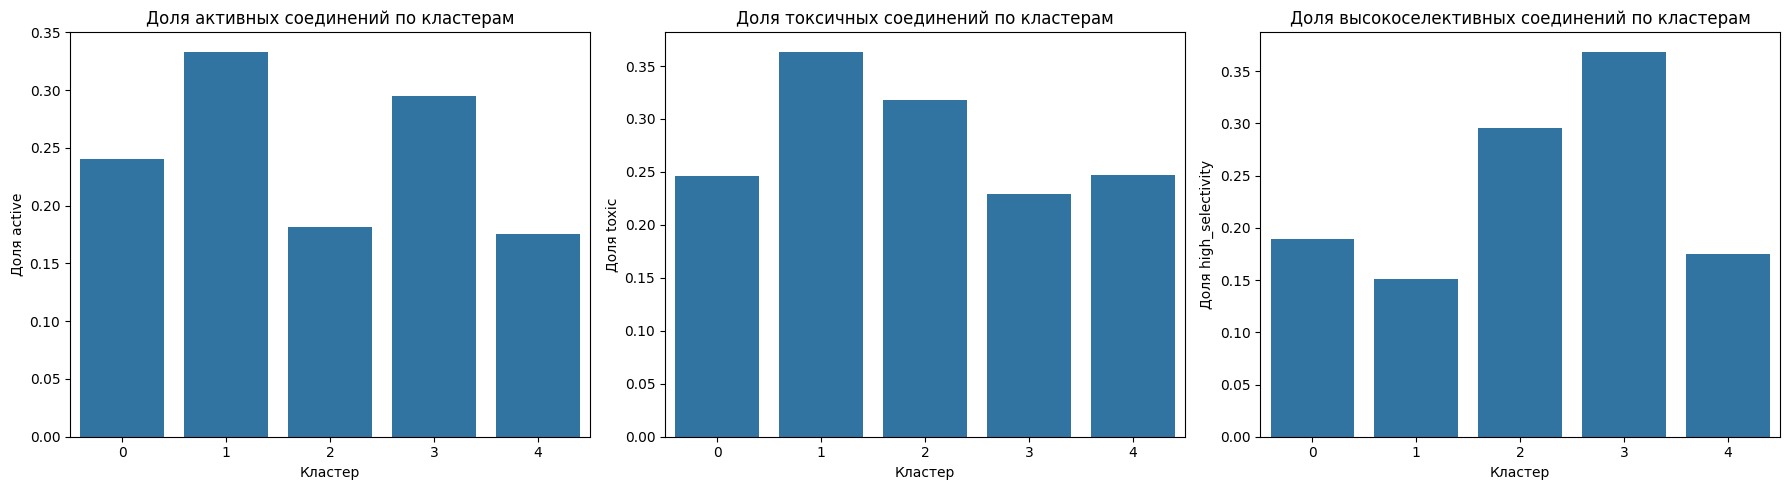

In [102]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=cluster_profile.reset_index(), x="cluster", y="active_rate", ax=axes[0]
)
axes[0].set_title("Доля активных соединений по кластерам")
axes[0].set_xlabel("Кластер")
axes[0].set_ylabel("Доля active")

sns.barplot(data=cluster_profile.reset_index(), x="cluster", y="toxic_rate", ax=axes[1])
axes[1].set_title("Доля токсичных соединений по кластерам")
axes[1].set_xlabel("Кластер")
axes[1].set_ylabel("Доля toxic")

sns.barplot(
    data=cluster_profile.reset_index(),
    x="cluster",
    y="high_selectivity_rate",
    ax=axes[2],
)
axes[2].set_title("Доля высокоселективных соединений по кластерам")
axes[2].set_xlabel("Кластер")
axes[2].set_ylabel("Доля high_selectivity")

plt.tight_layout()
plt.show()


### Cluster biological profiling


## Проверяем текущее состояние train

In [103]:
print("TRAIN SHAPE:", train.shape)
print("TEST SHAPE:", test.shape)

service_cols = [
    "cluster",
    "is_outlier",
    "log_Ipc",
    "MolWt_per_HeavyAtom",
    "TPSA_per_MolWt",
    "Hbond_ratio",
    "log_Hbond_ratio",
    "Aromatic_fraction",
]

existing = [col for col in service_cols if col in train.columns]

print("\nЕсть в train:")
print(existing)

existing_test = [col for col in service_cols if col in test.columns]

print("\nЕсть в test:")
print(existing_test)


TRAIN SHAPE: (751, 207)
TEST SHAPE: (250, 204)

Есть в train:
['log_Ipc', 'MolWt_per_HeavyAtom', 'TPSA_per_MolWt', 'log_Hbond_ratio', 'Aromatic_fraction']

Есть в test:
['log_Ipc', 'MolWt_per_HeavyAtom', 'TPSA_per_MolWt', 'log_Hbond_ratio', 'Aromatic_fraction']


In [104]:
train_fe.shape
test_fe.shape


(250, 204)

In [105]:
print("train_fe:", train_fe.shape)
print("test_fe:", test_fe.shape)


train_fe: (751, 214)
test_fe: (250, 204)


In [106]:
only_train_fe = set(train_fe.columns) - set(test_fe.columns)
only_test_fe = set(test_fe.columns) - set(train_fe.columns)

print("Есть только в train_fe:")
print(sorted(only_train_fe))

print("\nЕсть только в test_fe:")
print(sorted(only_test_fe))


Есть только в train_fe:
['CC50, mM', 'IC50, mM', 'SI', 'active', 'cluster', 'high_selectivity', 'inactive', 'low_selectivity', 'non_toxic', 'toxic']

Есть только в test_fe:
[]


In [107]:
# Проверка финального набора признаков

target_cols = ["IC50, mM", "CC50, mM", "SI"]

eda_cols = [
    "active",
    "inactive",
    "toxic",
    "non_toxic",
    "high_selectivity",
    "low_selectivity",
    "cluster",
    "is_outlier",
]

service_cols = ["index"]

drop_cols = target_cols + eda_cols + service_cols

feature_cols_train = [col for col in train_fe.columns if col not in drop_cols]

feature_cols_test = [col for col in test_fe.columns if col not in service_cols]

only_in_train_features = set(feature_cols_train) - set(feature_cols_test)
only_in_test_features = set(feature_cols_test) - set(feature_cols_train)

print("Количество признаков train:", len(feature_cols_train))
print("Количество признаков test:", len(feature_cols_test))

print("\nЕсть только в train:")
print(sorted(only_in_train_features))

print("\nЕсть только в test:")
print(sorted(only_in_test_features))


Количество признаков train: 203
Количество признаков test: 203

Есть только в train:
[]

Есть только в test:
[]


## Финальное признаковое пространство консистентно

## Проверка NaN / inf после feature engineering

In [108]:
X_train = train_fe[feature_cols_train]
X_test = test_fe[feature_cols_test]

print("NaN в train:", X_train.isna().sum().sum())
print("NaN в test:", X_test.isna().sum().sum())

print("inf в train:", np.isinf(X_train).sum().sum())
print("inf в test:", np.isinf(X_test).sum().sum())


NaN в train: 24
NaN в test: 12
inf в train: 0
inf в test: 0


In [109]:
# Где именно NaN

nan_train = X_train.isna().sum()
nan_train = nan_train[nan_train > 0].sort_values(ascending=False)

nan_test = X_test.isna().sum()
nan_test = nan_test[nan_test > 0].sort_values(ascending=False)

print("NaN в train:")
display(nan_train)

print("NaN в test:")
display(nan_test)


NaN в train:


MaxPartialCharge       2
MinPartialCharge       2
MaxAbsPartialCharge    2
MinAbsPartialCharge    2
BCUT2D_MWHI            2
BCUT2D_MWLOW           2
BCUT2D_CHGHI           2
BCUT2D_CHGLO           2
BCUT2D_LOGPHI          2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
dtype: int64

NaN в test:


MaxPartialCharge       1
MinPartialCharge       1
MaxAbsPartialCharge    1
MinAbsPartialCharge    1
BCUT2D_MWHI            1
BCUT2D_MWLOW           1
BCUT2D_CHGHI           1
BCUT2D_CHGLO           1
BCUT2D_LOGPHI          1
BCUT2D_LOGPLOW         1
BCUT2D_MRHI            1
BCUT2D_MRLOW           1
dtype: int64

## Константные / почти константные признаки после финального FE

In [110]:
# Константные признаки

constant_cols = [
    col for col in X_train.columns if X_train[col].nunique(dropna=False) <= 1
]

print("Константных признаков:", len(constant_cols))
print(constant_cols)


Константных признаков: 3
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9']


In [111]:
# Почти константные признаки (одно значение занимает >99%)

near_constant_cols = []

for col in X_train.columns:
    top_freq = X_train[col].value_counts(normalize=True, dropna=False).iloc[0]

    if top_freq > 0.99:
        near_constant_cols.append((col, top_freq))

print("Почти константных признаков:", len(near_constant_cols))

for col, freq in near_constant_cols:
    print(f"{col}: {freq:.4f}")


Почти константных признаков: 17
NumRadicalElectrons: 1.0000
SMR_VSA8: 1.0000
SlogP_VSA9: 1.0000
fr_Ar_COO: 0.9987
fr_HOCCN: 0.9987
fr_aldehyde: 0.9973
fr_amidine: 0.9933
fr_azo: 0.9920
fr_epoxide: 0.9973
fr_guanido: 0.9960
fr_hdrzine: 0.9973
fr_nitrile: 0.9947
fr_oxazole: 0.9987
fr_oxime: 0.9933
fr_term_acetylene: 0.9987
fr_tetrazole: 0.9987
fr_urea: 0.9933


## Проверка нет ли leakage признаков среди feature columns

In [112]:
TARGET_DERIVED_COLS = [
    "active",
    "inactive",
    "toxic",
    "non_toxic",
    "high_selectivity",
    "low_selectivity",
    "cluster",
    "is_outlier",
]


def check_leakage_columns(
    feature_columns,
    target_cols=None,
    target_derived_cols=None,
    context="",
    strict=True,
):
    if target_cols is None:
        target_cols = ["IC50, mM", "CC50, mM", "SI"]
    if target_derived_cols is None:
        target_derived_cols = TARGET_DERIVED_COLS

    forbidden = set(target_cols) | set(target_derived_cols)
    leaked = sorted([c for c in feature_columns if c in forbidden])

    report = {
        "context": context,
        "n_features": len(feature_columns),
        "n_forbidden_hits": len(leaked),
        "forbidden_hits": leaked,
    }
    print(report)

    if strict:
        assert len(leaked) == 0, f"Leakage columns detected in {context}: {leaked}"

    return report


leakage_report_train_fe = check_leakage_columns(
    feature_cols_train, context="feature_cols_train (train_fe)"
)


{'context': 'feature_cols_train (train_fe)', 'n_features': 203, 'n_forbidden_hits': 0, 'forbidden_hits': []}


## Проверка target naming consistency

In [113]:
# Проверка consistency названий таргетов

wrong_names = ["IC50", "CC50"]
correct_names = ["IC50, mM", "CC50, mM", "SI"]

print("Есть ли неправильные названия в train_fe:")
for col in wrong_names:
    if col in train_fe.columns:
        print(col)

print("\nКорректные таргеты:")
for col in correct_names:
    print(col, "->", col in train_fe.columns)


Есть ли неправильные названия в train_fe:

Корректные таргеты:
IC50, mM -> True
CC50, mM -> True
SI -> True


На данном этапе был завершён подробный анализ обучающей и тестовой выборок, целевых переменных, химических дескрипторов, биологических паттернов и финального признакового пространства.  
Цель этого блока — зафиксировать основные выводы, которые напрямую влияют на дальнейшую стратегию моделирования.

---

### 1. Структура задачи

Датасет представляет собой задачу прогнозирования биологической активности химических соединений по молекулярным дескрипторам.

В обучающей выборке доступны три целевые переменные:

- **IC50, mM** — концентрация, при которой соединение подавляет 50% вирусной активности.  
  Чем ниже IC50, тем выше противовирусная активность.

- **CC50, mM** — концентрация, при которой соединение токсично для 50% клеток.  
  Чем выше CC50, тем ниже токсичность.

- **SI** — индекс селективности, отражающий баланс между эффективностью и токсичностью.

Важный результат EDA:

**SI = CC50 / IC50**

Это означает, что `SI` не является независимым таргетом, а рассчитывается на основе `IC50` и `CC50`.  
Следовательно, при дальнейшем моделировании нужно учитывать зависимость между таргетами и избегать противоречивых предсказаний.

---

### 2. Поведение целевых переменных

Распределения всех трёх таргетов имеют выраженную асимметрию и длинные правые хвосты.

Особенно сильно это проявляется для **SI**:

- медианное значение SI равно примерно `4`;
- при этом максимальное значение превышает `15000`;
- распределение SI имеет очень сильную правостороннюю асимметрию.

Это говорит о том, что большинство соединений обладает низкой или умеренной селективностью, а небольшая группа молекул демонстрирует экстремально высокий therapeutic potential.

Логарифмирование существенно стабилизирует распределения таргетов:

- `IC50`: skew `3.79 → -0.06`;
- `CC50`: skew `2.06 → -0.90`;
- `SI`: skew `15.63 → 1.54`.

Это важный сигнал для дальнейшего моделирования: сырые таргеты содержат выбросы и сильную асимметрию, поэтому работа в лог-пространстве может быть более устойчивой.

---

### 3. Качество данных и неоднозначность X → y

В данных были обнаружены объекты с полностью одинаковыми наборами признаков, но разными значениями целевых переменных.

Это одна из ключевых находок EDA.

Такая ситуация означает, что отображение:

**X → y**

не является полностью однозначным.

Возможные причины:

- экспериментальный шум;
- повторные биологические измерения;
- ограниченность используемых дескрипторов;
- разные молекулы, которые совпадают по рассчитанным агрегированным признакам.

Следовательно, даже хорошая модель может иметь естественный предел качества, потому что часть вариативности таргетов не объясняется доступными признаками.

---

### 4. Train/test различия

Проверка train/test shift проводилась несколькими способами:

- KS-test;
- adversarial validation;
- PCA;
- UMAP.

Adversarial validation показала ROC-AUC около **0.97**, что указывает на выраженное различие между обучающей и тестовой выборками.

При этом PCA и UMAP не показывают полного разделения train и test на изолированные области: выборки в целом лежат в общем химическом пространстве, но распределения отдельных признаков заметно отличаются.

Это означает, что при моделировании важно:

- использовать устойчивую к shift валидацию;
- не переобучаться на особенности train;
- аккуратно работать с выбросами и редкими структурами;
- проверять стабильность моделей на разных фолдах.

---

### 5. Химическое пространство и структура признаков

Анализ молекулярных дескрипторов показал, что данные содержат разные группы химических признаков:

- размер молекулы;
- топологические свойства;
- гибкость;
- полярность и растворимость;
- фрагментные дескрипторы;
- электрические характеристики;
- BCUT-дескрипторы;
- EState-признаки;
- drug-likeness признаки.

Между частью признаков наблюдается высокая корреляция, что ожидаемо для химических дескрипторов. Например, разные признаки могут одновременно описывать размер, массу, число атомов или близкие структурные свойства молекулы.

При этом не было обнаружено признаков с подозрительно высокой корреляцией с таргетами. Это говорит о том, что явной утечки целевой информации в исходных дескрипторах нет.

---

### 6. Feature Engineering

В ходе feature engineering были добавлены дополнительные признаки, отражающие более интерпретируемые химические отношения:

- `log_Ipc`;
- `MolWt_per_HeavyAtom`;
- `TPSA_per_MolWt`;
- `Hbond_ratio`;
- `log_Hbond_ratio`;
- `Aromatic_fraction`.

Эти признаки не заменяют исходные дескрипторы, а дополняют их более компактными характеристиками:

- относительная масса;
- плотность полярности;
- соотношение доноров и акцепторов водородных связей;
- доля ароматических структур;
- стабилизированная структурная сложность.

Финальная проверка показала, что после feature engineering `train_fe` и `test_fe` имеют согласованный набор признаков.

---

### 7. Пропуски, inf и константные признаки

После финального feature engineering были обнаружены небольшие количества пропусков:

- `24` NaN в train;
- `12` NaN в test;
- `inf = 0`.

Пропуски локализованы в отдельных RDKit-дескрипторах:

- `MaxPartialCharge`;
- `MinPartialCharge`;
- `MaxAbsPartialCharge`;
- `MinAbsPartialCharge`;
- `BCUT2D_*`.

Такой паттерн выглядит не как ошибка обработки, а как невозможность расчёта отдельных химических дескрипторов для небольшого числа молекул.

Также были найдены 3 полностью константных признака:

- `NumRadicalElectrons`;
- `SMR_VSA8`;
- `SlogP_VSA9`.

Эти признаки не несут информации и могут быть удалены на этапе preprocessing.

Почти константные признаки в основном представлены редкими fragment-дескрипторами. Их не стоит автоматически удалять, так как редкий химический фрагмент может быть важным биологическим сигналом.

---

### 8. Биологическая интерпретация

Были отдельно проанализированы группы соединений:

- active vs inactive;
- toxic vs non-toxic;
- high selectivity vs low selectivity.

Анализ показал, что между активностью, токсичностью и селективностью существует выраженный trade-off.

Часть соединений демонстрирует хорошую противовирусную активность, но одновременно имеет повышенную токсичность.  
Наиболее интересными с практической точки зрения являются не просто самые активные молекулы, а соединения с хорошим балансом:

- низкий IC50;
- высокий CC50;
- высокий SI.

Именно такие соединения потенциально наиболее перспективны как лекарственные кандидаты.

---

### 9. Кластерный biological profiling

Кластеризация использовалась как исследовательский инструмент для проверки того, соответствуют ли структурные группы молекул различиям в биологических свойствах.

Финальный biological profiling показал, что кластеры действительно различаются по медианным значениям `IC50`, `CC50`, `SI` и долям active/toxic/high-selectivity соединений.

Наиболее интересным оказался **кластер 3**:

- максимальный медианный SI;
- относительно низкий IC50;
- умеренная токсичность;
- самая высокая доля высокоселективных соединений.

Это говорит о том, что в данных есть структурные группы молекул с более перспективным биологическим профилем.

---

### 10. Финальное состояние признакового пространства

Перед переходом к моделированию была проведена техническая проверка финального feature space:

- `train_fe` и `test_fe` содержат одинаковые 205 признаков после исключения таргетов и EDA-флагов;
- leakage-колонки отсутствуют;
- названия таргетов консистентны;
- `inf` значений нет;
- NaN минимальны и объяснимы;
- константные признаки выявлены;
- исходные `train_raw` и `test_raw` сохранены.

Это означает, что данные готовы к переходу от EDA к построению воспроизводимого preprocessing pipeline.

---

### Общий вывод

Проведённый EDA показал, что задача является сложной, но информативной.

Основные сложности:

- сильная асимметрия таргетов;
- экстремальные значения SI;
- зависимость SI от IC50 и CC50;
- train/test shift;
- наличие одинаковых признаков при разных таргетах;
- редкие химические фрагменты;
- потенциальный trade-off между активностью и токсичностью.

Основные сильные стороны данных:

- признаковое пространство содержит осмысленные химические дескрипторы;
- явной утечки таргетов в признаки не обнаружено;
- биологические группы соединений отличаются между собой;
- кластеры имеют интерпретируемые различия по активности, токсичности и селективности;
- feature engineering добавляет химически осмысленные признаки.

Таким образом, этап EDA и feature engineering можно считать завершённым.  
Далее логично переходить к выбору стратегии моделирования, отдельно учитывая зависимость:

**SI = CC50 / IC50**

## Пока стратегия такая

- Какую CV-валидацию брать
Датасет маленький, train/test shift есть, поэтому обычный один train_test_split слабый. Лучше думать про KFold или RepeatedKFold.

- Как считать CV-score
Надо написать свою функцию метрики ровно как в хакатоне:
score = (RMSE_IC50 + RMSE_CC50 + RMSE_SI) / 3

- Что делаем с выбросами SI
SI очень тяжёлый: максимум огромный. Нужно решить: просто логируем таргеты или ещё пробуем clipping предсказаний.

- Какие признаки идут в модель
Фиксируем:
удалить 3 константных признака;
NaN заполнять медианой;
rare fragments пока оставить;
leakage-флаги не использовать;
cluster пока не использовать как базовый признак.

In [114]:
# фикс икс и игрик

X_train = train_fe[feature_cols_train].copy()
X_test = test_fe[feature_cols_train].copy()

y_train = train_fe[target_cols].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)


X_train: (751, 203)
X_test: (250, 203)
y_train: (751, 3)


In [115]:
forbidden_cols = target_cols + eda_cols + service_cols

leakage = [col for col in X_train.columns if col in forbidden_cols]

print("Leakage columns:", leakage)


Leakage columns: []


In [116]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)

print("Targets:", target_cols)
print("Leakage columns:", leakage)


X_train shape: (751, 203)
X_test shape: (250, 203)
y_train shape: (751, 3)
Targets: ['IC50, mM', 'CC50, mM', 'SI']
Leakage columns: []


# Preprocessing для моделирования


In [117]:
# удаление 3 конст

# Константные признаки, которые удаляем из baseline
constant_cols_final = ["NumRadicalElectrons", "SMR_VSA8", "SlogP_VSA9"]

# Проверяем, какие из них реально есть в X_train / X_test
constant_cols_to_drop_train = [
    col for col in constant_cols_final if col in X_train.columns
]

constant_cols_to_drop_test = [
    col for col in constant_cols_final if col in X_test.columns
]

print("Константные признаки для удаления из X_train:")
print(constant_cols_to_drop_train)

print("\nКонстантные признаки для удаления из X_test:")
print(constant_cols_to_drop_test)

# Удаляем
X_train = X_train.drop(columns=constant_cols_to_drop_train)
X_test = X_test.drop(columns=constant_cols_to_drop_test)

print("\nПосле удаления константных признаков:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


Константные признаки для удаления из X_train:
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9']

Константные признаки для удаления из X_test:
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9']

После удаления константных признаков:
X_train shape: (751, 200)
X_test shape: (250, 200)


In [118]:
# Проверяем совпадение колонок после удаления
missing_in_test = set(X_train.columns) - set(X_test.columns)
extra_in_test = set(X_test.columns) - set(X_train.columns)

print("Есть в X_train, но нет в X_test:", sorted(missing_in_test))
print("Есть в X_test, но нет в X_train:", sorted(extra_in_test))


Есть в X_train, но нет в X_test: []
Есть в X_test, но нет в X_train: []


In [119]:
# Импьютер для заполнения пропусков медианой
imputer = SimpleImputer(strategy="median")

# fit только на train, чтобы не было leakage
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Возвращаем обратно в DataFrame с теми же колонками и индексами
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)

X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

print("После SimpleImputer(strategy='median'):")
print("Всего пропусков в X_train:", X_train.isna().sum().sum())
print("Всего пропусков в X_test:", X_test.isna().sum().sum())
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


После SimpleImputer(strategy='median'):
Всего пропусков в X_train: 0
Всего пропусков в X_test: 0
X_train shape: (751, 200)
X_test shape: (250, 200)


In [120]:
print("Есть пропуски в X_train:", X_train.isna().any().any())
print("Есть пропуски в X_test:", X_test.isna().any().any())
print("Есть пропуски в y_train:", y_train.isna().any().any())


Есть пропуски в X_train: False
Есть пропуски в X_test: False
Есть пропуски в y_train: False


In [121]:
# Скейлер для линейных моделей
scaler = StandardScaler()

# fit только на X_train, чтобы не было leakage
X_train_scaled_array = scaler.fit_transform(X_train)
X_test_scaled_array = scaler.transform(X_test)

# Возвращаем в DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled_array, columns=X_train.columns, index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled_array, columns=X_test.columns, index=X_test.index
)

print("После StandardScaler:")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

print("\nСреднее по X_train_scaled:")
print(X_train_scaled.mean().round(4).sort_values().head())
print(X_train_scaled.mean().round(4).sort_values().tail())

print("\nStd по X_train_scaled:")
print(X_train_scaled.std().round(4).sort_values().head())
print(X_train_scaled.std().round(4).sort_values().tail())


После StandardScaler:
X_train_scaled shape: (751, 200)
X_test_scaled shape: (250, 200)

Среднее по X_train_scaled:
MaxAbsEStateIndex   -0.0
MaxEStateIndex      -0.0
MinAbsEStateIndex    0.0
MinEStateIndex       0.0
qed                  0.0
dtype: float64
log_Hbond_ratio        0.0
Aromatic_fraction     -0.0
Lipinski_violations   -0.0
Lipinski_pass         -0.0
Veber_pass            -0.0
dtype: float64

Std по X_train_scaled:
MaxAbsEStateIndex    1.0007
MaxEStateIndex       1.0007
MinAbsEStateIndex    1.0007
MinEStateIndex       1.0007
qed                  1.0007
dtype: float64
log_Hbond_ratio        1.0007
Aromatic_fraction      1.0007
Lipinski_violations    1.0007
Lipinski_pass          1.0007
Veber_pass             1.0007
dtype: float64


In [122]:
# Для деревьев используем:
# X_train, X_test

# Для линейных моделей используем:
# X_train_scaled, X_test_scaled


In [123]:
print("Пропуски в X_train_scaled:", X_train_scaled.isna().sum().sum())
print("Пропуски в X_test_scaled:", X_test_scaled.isna().sum().sum())


Пропуски в X_train_scaled: 0
Пропуски в X_test_scaled: 0


In [124]:
# Проверяем различия в колонках train/test

train_cols = set(X_train.columns)
test_cols = set(X_test.columns)

only_in_train = sorted(train_cols - test_cols)
only_in_test = sorted(test_cols - train_cols)

print("Есть только в X_train:")
print(only_in_train)

print("\nЕсть только в X_test:")
print(only_in_test)

print("\nКоличество колонок только в train:", len(only_in_train))
print("Количество колонок только в test:", len(only_in_test))


Есть только в X_train:
[]

Есть только в X_test:
[]

Количество колонок только в train: 0
Количество колонок только в test: 0


In [125]:
# Оставляем общие колонки в порядке X_train

common_cols = [col for col in X_train.columns if col in X_test.columns]

X_train = X_train[common_cols].copy()
X_test = X_test[common_cols].copy()

print("После выравнивания колонок:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nКолонки совпадают:", list(X_train.columns) == list(X_test.columns))


После выравнивания колонок:
X_train shape: (751, 200)
X_test shape: (250, 200)

Колонки совпадают: True


In [126]:
# Финальная проверка совпадения колонок

missing_in_test = sorted(set(X_train.columns) - set(X_test.columns))
extra_in_test = sorted(set(X_test.columns) - set(X_train.columns))

print("Есть в X_train, но нет в X_test:", missing_in_test)
print("Есть в X_test, но нет в X_train:", extra_in_test)
print("Порядок колонок одинаковый:", list(X_train.columns) == list(X_test.columns))


Есть в X_train, но нет в X_test: []
Есть в X_test, но нет в X_train: []
Порядок колонок одинаковый: True


In [127]:
# Проверка и удаление leakage / EDA-флагов

leakage_flag_cols = [
    "active",
    "inactive",
    "toxic",
    "non_toxic",
    "high_selectivity",
    "low_selectivity",
    "cluster",
    "is_outlier",
]

leakage_in_train = [col for col in leakage_flag_cols if col in X_train.columns]

leakage_in_test = [col for col in leakage_flag_cols if col in X_test.columns]

print("Leakage-флаги в X_train:")
print(leakage_in_train)

print("\nLeakage-флаги в X_test:")
print(leakage_in_test)

X_train = X_train.drop(columns=leakage_in_train)
X_test = X_test.drop(columns=leakage_in_test)

print("\nПосле удаления leakage-флагов:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Финальная проверка
leakage_left_train = [col for col in leakage_flag_cols if col in X_train.columns]

leakage_left_test = [col for col in leakage_flag_cols if col in X_test.columns]

print("\nОстались leakage-флаги в X_train:")
print(leakage_left_train)

print("\nОстались leakage-флаги в X_test:")
print(leakage_left_test)


Leakage-флаги в X_train:
[]

Leakage-флаги в X_test:
[]

После удаления leakage-флагов:
X_train shape: (751, 200)
X_test shape: (250, 200)

Остались leakage-флаги в X_train:
[]

Остались leakage-флаги в X_test:
[]


In [128]:
# Расширенная проверка подозрительных колонок по ключевым словам

suspicious_keywords = [
    "target",
    "label",
    "active",
    "inactive",
    "toxic",
    "non_toxic",
    "selectivity",
    "cluster",
    "outlier",
    "IC50",
    "CC50",
    "SI",
]

suspicious_cols_train = [
    col
    for col in X_train.columns
    if any(keyword.lower() in col.lower() for keyword in suspicious_keywords)
]

suspicious_cols_test = [
    col
    for col in X_test.columns
    if any(keyword.lower() in col.lower() for keyword in suspicious_keywords)
]

print("Подозрительные колонки в X_train:")
print(suspicious_cols_train)

print("\nПодозрительные колонки в X_test:")
print(suspicious_cols_test)


Подозрительные колонки в X_train:
['FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3']

Подозрительные колонки в X_test:
['FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3']


In [129]:


cv_fast = KFold(n_splits=5, shuffle=True, random_state=42)

cv_stable = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

print("CV для быстрого baseline:")
print(cv_fast)

print("\nCV для финальной проверки стабильности:")
print(cv_stable)


CV для быстрого baseline:
KFold(n_splits=5, random_state=42, shuffle=True)

CV для финальной проверки стабильности:
RepeatedKFold(n_repeats=3, n_splits=5, random_state=42)


In [130]:
# Проверка сплитов KFold

for fold, (train_idx, valid_idx) in enumerate(cv_fast.split(X_train), start=1):
    print(f"Fold {fold}: " f"train = {len(train_idx)}, " f"valid = {len(valid_idx)}")


Fold 1: train = 600, valid = 151
Fold 2: train = 601, valid = 150
Fold 3: train = 601, valid = 150
Fold 4: train = 601, valid = 150
Fold 5: train = 601, valid = 150


In [131]:
# Проверка сплитов RepeatedKFold

for fold, (train_idx, valid_idx) in enumerate(cv_stable.split(X_train), start=1):
    print(f"Fold {fold}: " f"train = {len(train_idx)}, " f"valid = {len(valid_idx)}")


Fold 1: train = 600, valid = 151
Fold 2: train = 601, valid = 150
Fold 3: train = 601, valid = 150
Fold 4: train = 601, valid = 150
Fold 5: train = 601, valid = 150
Fold 6: train = 600, valid = 151
Fold 7: train = 601, valid = 150
Fold 8: train = 601, valid = 150
Fold 9: train = 601, valid = 150
Fold 10: train = 601, valid = 150
Fold 11: train = 600, valid = 151
Fold 12: train = 601, valid = 150
Fold 13: train = 601, valid = 150
Fold 14: train = 601, valid = 150
Fold 15: train = 601, valid = 150


In [132]:

print("Количество сплитов cv_fast:", cv_fast.get_n_splits(X_train))
print("Количество сплитов cv_stable:", cv_stable.get_n_splits(X_train))


Количество сплитов cv_fast: 5
Количество сплитов cv_stable: 15


In [133]:


cv_fast = KFold(n_splits=5, shuffle=True, random_state=42)

cv_stable = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

print("Количество сплитов cv_fast:", cv_fast.get_n_splits(X_train))
print("Количество сплитов cv_stable:", cv_stable.get_n_splits(X_train))


Количество сплитов cv_fast: 5
Количество сплитов cv_stable: 15


In [134]:


TARGETS = ["IC50, mM", "CC50, mM", "SI"]


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def competition_score(y_true, y_pred):
    """
    Считает score как среднее RMSE по трём таргетам:
    IC50, CC50, SI

    score = (RMSE_IC50 + RMSE_CC50 + RMSE_SI) / 3
    """

    if isinstance(y_true, pd.DataFrame):
        y_true = y_true[TARGETS].values

    if isinstance(y_pred, pd.DataFrame):
        y_pred = y_pred[TARGETS].values

    # Если пришли numpy arrays
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse_ic50 = rmse(y_true[:, 0], y_pred[:, 0])
    rmse_cc50 = rmse(y_true[:, 1], y_pred[:, 1])
    rmse_si = rmse(y_true[:, 2], y_pred[:, 2])

    score = (rmse_ic50 + rmse_cc50 + rmse_si) / 3

    return {
        "RMSE_IC50": rmse_ic50,
        "RMSE_CC50": rmse_cc50,
        "RMSE_SI": rmse_si,
        "score": score,
    }


In [135]:

test_metrics = competition_score(y_train, y_train)

test_metrics


{'RMSE_IC50': np.float64(0.0),
 'RMSE_CC50': np.float64(0.0),
 'RMSE_SI': np.float64(0.0),
 'score': np.float64(0.0)}

# Блок baseline-стратегий


## Стратегия A: raw multi-target baseline


In [136]:
TARGETS = ["IC50, mM", "CC50, mM", "SI"]

y_a0 = train_fe[TARGETS].copy()

print("y_a0 shape:", y_a0.shape)
print("\nПервые строки y_a0:")
display(y_a0.head())

print("\nПропуски в y_a0:")
print(y_a0.isna().sum())

print("\nОписание таргетов:")
display(y_a0.describe())


y_a0 shape: (751, 3)

Первые строки y_a0:


,"IC50, mM","CC50, mM",SI
0,102.414420,95.757483,0.935000
1,0.044333,8.401080,189.500000
2,4.437964,50.085589,11.285714
3,6.827881,682.788051,100.000000
4,2.003253,70.001455,34.943894



Пропуски в y_a0:
IC50, mM    0
CC50, mM    0
SI          0
dtype: int64

Описание таргетов:


,"IC50, mM","CC50, mM",SI
count,751.000000,751.000000,751.000000
mean,204.544021,577.426098,89.153313
std,370.367937,641.515163,788.882198
min,0.003517,0.700808,0.011489
25%,13.222351,99.998894,1.500000
50%,44.069306,376.580899,4.000000
75%,206.787402,877.508784,17.372463
max,4095.188563,4538.976189,15620.600000


In [137]:
y_a0 = y_train.copy()

print("y_a0 shape:", y_a0.shape)
display(y_a0.head())


y_a0 shape: (751, 3)


,"IC50, mM","CC50, mM",SI
0,102.414420,95.757483,0.935000
1,0.044333,8.401080,189.500000
2,4.437964,50.085589,11.285714
3,6.827881,682.788051,100.000000
4,2.003253,70.001455,34.943894


In [138]:

print("Колонки y_a0:")
print(list(y_a0.columns))

print("\nПропуски в y_a0:")
print(y_a0.isna().sum())

print("\nМинимумы:")
print(y_a0.min())

print("\nМаксимумы:")
print(y_a0.max())


Колонки y_a0:
['IC50, mM', 'CC50, mM', 'SI']

Пропуски в y_a0:
IC50, mM    0
CC50, mM    0
SI          0
dtype: int64

Минимумы:
IC50, mM    0.003517
CC50, mM    0.700808
SI          0.011489
dtype: float64

Максимумы:
IC50, mM     4095.188563
CC50, mM     4538.976189
SI          15620.600000
dtype: float64


### Strategy A0: raw multi-target baseline


## Базовые baseline-модели


### Ridge

In [139]:
# На всякий случай фиксируем таргеты A0
TARGETS = ["IC50, mM", "CC50, mM", "SI"]
y_a0 = y_train[TARGETS].copy()


def print_score(metrics):
    """Helper function to print competition score metrics."""
    print(f"RMSE_IC50: {metrics['RMSE_IC50']:.4f}")
    print(f"RMSE_CC50: {metrics['RMSE_CC50']:.4f}")
    print(f"RMSE_SI: {metrics['RMSE_SI']:.4f}")
    print(f"Score: {metrics['score']:.4f}")


ridge_a0 = MultiOutputRegressor(Ridge(alpha=1.0, random_state=42))

fold_results = []

for fold, (train_idx, valid_idx) in enumerate(cv_fast.split(X_train_scaled), start=1):

    X_tr = X_train_scaled.iloc[train_idx]
    X_val = X_train_scaled.iloc[valid_idx]

    y_tr = y_a0.iloc[train_idx]
    y_val = y_a0.iloc[valid_idx]

    model = clone(ridge_a0)
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)

    metrics = competition_score(y_val, y_pred)
    metrics["fold"] = fold

    fold_results.append(metrics)

    print(f"Fold {fold}")
    print_score(metrics)
    print("-" * 40)

ridge_a0_cv = pd.DataFrame(fold_results)

print("A0 Ridge CV results:")
display(ridge_a0_cv)

print("\nA0 Ridge mean CV score:")
display(ridge_a0_cv.drop(columns="fold").mean())

print("\nA0 Ridge std CV score:")
display(ridge_a0_cv.drop(columns="fold").std())


Fold 1
RMSE_IC50: 439.9350
RMSE_CC50: 609.7834
RMSE_SI: 353.1519
Score: 467.6235
----------------------------------------
Fold 2
RMSE_IC50: 291.4487
RMSE_CC50: 407.6614
RMSE_SI: 546.2848
Score: 415.1317
----------------------------------------
Fold 3
RMSE_IC50: 349.6376
RMSE_CC50: 507.0304
RMSE_SI: 927.8635
Score: 594.8438
----------------------------------------
Fold 4
RMSE_IC50: 336.2072
RMSE_CC50: 539.9202
RMSE_SI: 325.2605
Score: 400.4626
----------------------------------------
Fold 5
RMSE_IC50: 379.5637
RMSE_CC50: 552.3725
RMSE_SI: 1345.9195
Score: 759.2852
----------------------------------------
A0 Ridge CV results:


,RMSE_IC50,RMSE_CC50,RMSE_SI,score,fold
0,439.934998,609.783439,353.151915,467.623451,1
1,291.448740,407.661433,546.284841,415.131671,2
2,349.637612,507.030424,927.863504,594.843847,3
3,336.207178,539.920235,325.260477,400.462630,4
4,379.563679,552.372495,1345.919471,759.285215,5



A0 Ridge mean CV score:


RMSE_IC50    359.358441
RMSE_CC50    523.353605
RMSE_SI      699.696042
score        527.469363
dtype: float64


A0 Ridge std CV score:


RMSE_IC50     55.097723
RMSE_CC50     74.561703
RMSE_SI      434.020429
score        150.507401
dtype: float64

В первой baseline-стратегии Ridge обучалась на трёх исходных таргетах: `IC50, mM`, `CC50, mM`, `SI`.

Средний CV score составил около **527.7**.  
Основная проблема наблюдается по таргету `SI`: ошибка по нему сильно меняется между фолдами и достигает максимума на fold 5.

Это говорит о том, что прямое предсказание `SI` в исходном пространстве плохо стабилизируется линейной моделью. Вероятная причина — высокий разброс `SI` и наличие выбросов, так как `SI` является отношением `CC50 / IC50`.

Данный результат используем как простой baseline для сравнения с дальнейшими стратегиями:
- логарифмирование таргетов;
- отдельное предсказание `IC50` и `CC50` с последующим расчётом `SI`;
- нелинейные модели.

### ElasticNet

In [140]:
TARGETS = ["IC50, mM", "CC50, mM", "SI"]
y_a0 = y_train[TARGETS].copy()

elasticnet_a0 = MultiOutputRegressor(
    ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=10000)
)

fold_results = []

for fold, (train_idx, valid_idx) in enumerate(cv_fast.split(X_train_scaled), start=1):

    X_tr = X_train_scaled.iloc[train_idx]
    X_val = X_train_scaled.iloc[valid_idx]

    y_tr = y_a0.iloc[train_idx]
    y_val = y_a0.iloc[valid_idx]

    model = clone(elasticnet_a0)
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)

    metrics = competition_score(y_val, y_pred)
    metrics["fold"] = fold

    fold_results.append(metrics)

    print(f"Fold {fold}")
    print_score(metrics)
    print("-" * 40)

elasticnet_a0_cv = pd.DataFrame(fold_results)

print("A0 ElasticNet CV results:")
display(elasticnet_a0_cv)

print("\nA0 ElasticNet mean CV score:")
display(elasticnet_a0_cv.drop(columns="fold").mean())

print("\nA0 ElasticNet std CV score:")
display(elasticnet_a0_cv.drop(columns="fold").std())


Fold 1
RMSE_IC50: 391.0417
RMSE_CC50: 511.7538
RMSE_SI: 300.7761
Score: 401.1906
----------------------------------------
Fold 2
RMSE_IC50: 273.2589
RMSE_CC50: 410.3975
RMSE_SI: 528.0253
Score: 403.8939
----------------------------------------
Fold 3
RMSE_IC50: 325.6537
RMSE_CC50: 473.9139
RMSE_SI: 912.4792
Score: 570.6823
----------------------------------------
Fold 4
RMSE_IC50: 313.4374
RMSE_CC50: 543.2616
RMSE_SI: 296.8438
Score: 384.5143
----------------------------------------
Fold 5
RMSE_IC50: 360.4075
RMSE_CC50: 546.1340
RMSE_SI: 1332.6971
Score: 746.4129
----------------------------------------
A0 ElasticNet CV results:


,RMSE_IC50,RMSE_CC50,RMSE_SI,score,fold
0,391.041673,511.753850,300.776140,401.190554,1
1,273.258908,410.397470,528.025328,403.893902,2
2,325.653743,473.913869,912.479165,570.682259,3
3,313.437442,543.261574,296.843832,384.514283,4
4,360.407508,546.134040,1332.697074,746.412874,5



A0 ElasticNet mean CV score:


RMSE_IC50    332.759855
RMSE_CC50    497.092161
RMSE_SI      674.164308
score        501.338774
dtype: float64


A0 ElasticNet std CV score:


RMSE_IC50     45.070440
RMSE_CC50     56.579343
RMSE_SI      445.422676
score        156.559065
dtype: float64

In [141]:
model_comparison = pd.DataFrame(
    [
        {
            "model": "Ridge A0 raw",
            "RMSE_IC50": ridge_a0_cv["RMSE_IC50"].mean(),
            "RMSE_CC50": ridge_a0_cv["RMSE_CC50"].mean(),
            "RMSE_SI": ridge_a0_cv["RMSE_SI"].mean(),
            "score": ridge_a0_cv["score"].mean(),
            "score_std": ridge_a0_cv["score"].std(),
        },
        {
            "model": "ElasticNet A0 raw",
            "RMSE_IC50": elasticnet_a0_cv["RMSE_IC50"].mean(),
            "RMSE_CC50": elasticnet_a0_cv["RMSE_CC50"].mean(),
            "RMSE_SI": elasticnet_a0_cv["RMSE_SI"].mean(),
            "score": elasticnet_a0_cv["score"].mean(),
            "score_std": elasticnet_a0_cv["score"].std(),
        },
    ]
)

display(model_comparison.sort_values("score"))


,model,RMSE_IC50,RMSE_CC50,RMSE_SI,score,score_std
1,ElasticNet A0 raw,332.759855,497.092161,674.164308,501.338774,156.559065
0,Ridge A0 raw,359.358441,523.353605,699.696042,527.469363,150.507401


### RandomForestRegressor


In [142]:
TARGETS = ["IC50, mM", "CC50, mM", "SI"]
y_a0 = y_train[TARGETS].copy()

rf_a0 = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
)

fold_results = []

for fold, (train_idx, valid_idx) in enumerate(cv_fast.split(X_train), start=1):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[valid_idx]

    y_tr = y_a0.iloc[train_idx]
    y_val = y_a0.iloc[valid_idx]

    model = clone(rf_a0)
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)

    metrics = competition_score(y_val, y_pred)
    metrics["fold"] = fold

    fold_results.append(metrics)

    print(f"Fold {fold}")
    print_score(metrics)
    print("-" * 40)

rf_a0_cv = pd.DataFrame(fold_results)

print("A0 RandomForest CV results:")
display(rf_a0_cv)

print("\nA0 RandomForest mean CV score:")
display(rf_a0_cv.drop(columns="fold").mean())

print("\nA0 RandomForest std CV score:")
display(rf_a0_cv.drop(columns="fold").std())


Fold 1
RMSE_IC50: 383.2092
RMSE_CC50: 433.5040
RMSE_SI: 349.4259
Score: 388.7130
----------------------------------------
Fold 2
RMSE_IC50: 249.3401
RMSE_CC50: 343.1359
RMSE_SI: 522.2619
Score: 371.5793
----------------------------------------
Fold 3
RMSE_IC50: 336.5136
RMSE_CC50: 456.5244
RMSE_SI: 948.1044
Score: 580.3808
----------------------------------------
Fold 4
RMSE_IC50: 307.2586
RMSE_CC50: 548.6985
RMSE_SI: 266.0535
Score: 374.0035
----------------------------------------
Fold 5
RMSE_IC50: 319.5678
RMSE_CC50: 484.1767
RMSE_SI: 1354.7807
Score: 719.5084
----------------------------------------
A0 RandomForest CV results:


,RMSE_IC50,RMSE_CC50,RMSE_SI,score,fold
0,383.209210,433.503955,349.425886,388.713017,1
1,249.340067,343.135870,522.261913,371.579283,2
2,336.513629,456.524437,948.104410,580.380825,3
3,307.258623,548.698530,266.053469,374.003541,4
4,319.567806,484.176732,1354.780695,719.508411,5



A0 RandomForest mean CV score:


RMSE_IC50    319.177867
RMSE_CC50    453.207905
RMSE_SI      688.125275
score        486.837015
dtype: float64


A0 RandomForest std CV score:


RMSE_IC50     48.528549
RMSE_CC50     75.154218
RMSE_SI      456.177361
score        156.947825
dtype: float64

In [143]:
rf_a0 = RandomForestRegressor(n_estimators=100, random_state=42)

rf_a0.fit(X_train, y_train)

test_pred_a0_rf = rf_a0.predict(X_test)

print("Минимальные предсказания:")
print(test_pred_a0_rf.min())

print("\nКоличество отрицательных предсказаний:")
print((test_pred_a0_rf < 0).sum())


Минимальные предсказания:
0.28752262290179303

Количество отрицательных предсказаний:
0


In [144]:
# Сравнение моделей A0 raw

model_comparison = pd.DataFrame(
    [
        {
            "model": "Ridge A0 raw",
            "RMSE_IC50_mean": ridge_a0_cv["RMSE_IC50"].mean(),
            "RMSE_CC50_mean": ridge_a0_cv["RMSE_CC50"].mean(),
            "RMSE_SI_mean": ridge_a0_cv["RMSE_SI"].mean(),
            "score_mean": ridge_a0_cv["score"].mean(),
            "score_std": ridge_a0_cv["score"].std(),
        },
        {
            "model": "ElasticNet A0 raw",
            "RMSE_IC50_mean": elasticnet_a0_cv["RMSE_IC50"].mean(),
            "RMSE_CC50_mean": elasticnet_a0_cv["RMSE_CC50"].mean(),
            "RMSE_SI_mean": elasticnet_a0_cv["RMSE_SI"].mean(),
            "score_mean": elasticnet_a0_cv["score"].mean(),
            "score_std": elasticnet_a0_cv["score"].std(),
        },
        {
            "model": "RandomForest A0 raw",
            "RMSE_IC50_mean": rf_a0_cv["RMSE_IC50"].mean(),
            "RMSE_CC50_mean": rf_a0_cv["RMSE_CC50"].mean(),
            "RMSE_SI_mean": rf_a0_cv["RMSE_SI"].mean(),
            "score_mean": rf_a0_cv["score"].mean(),
            "score_std": rf_a0_cv["score"].std(),
        },
    ]
)

model_comparison = model_comparison.sort_values("score_mean").reset_index(drop=True)

display(model_comparison)


,model,RMSE_IC50_mean,RMSE_CC50_mean,RMSE_SI_mean,score_mean,score_std
0,RandomForest A0 raw,319.177867,453.207905,688.125275,486.837015,156.947825
1,ElasticNet A0 raw,332.759855,497.092161,674.164308,501.338774,156.559065
2,Ridge A0 raw,359.358441,523.353605,699.696042,527.469363,150.507401


## Обучение baseline-моделей


In [145]:
bad_cols = [
    "active",
    "inactive",
    "toxic",
    "non_toxic",
    "high_selectivity",
    "low_selectivity",
    "cluster",
    "is_outlier",
    "is_test",
]

print([c for c in bad_cols if c in X_train.columns])
print([c for c in bad_cols if c in X_test.columns])


[]
[]


## Промежуточный baseline submit (диагностика)

Этот блок используется как промежуточная контрольная точка. Финальный сабмит формируется в основной цепочке ниже.


# 6. Валидация без leakage


In [146]:
# 1. Targets

TARGET_IC50 = "IC50, mM"
TARGET_CC50 = "CC50, mM"
TARGET_SI = "SI"

TARGETS = [TARGET_IC50, TARGET_CC50, TARGET_SI]


In [147]:
# 2. Feature columns

drop_cols = [
    TARGET_IC50,
    TARGET_CC50,
    TARGET_SI,
    "index",
    "active",
    "inactive",
    "toxic",
    "non_toxic",
    "high_selectivity",
    "low_selectivity",
    "cluster",
]

feature_cols = [col for col in train.columns if col not in drop_cols]

print("Number of feature columns:", len(feature_cols))
print(feature_cols[:10])


Number of feature columns: 203
['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons']


In [148]:
# 3. X / y

X_train = train[feature_cols].copy()

y_train = train[[TARGET_IC50, TARGET_CC50, TARGET_SI]].copy()

y_ic50 = y_train[TARGET_IC50].values
y_cc50 = y_train[TARGET_CC50].values
y_si = y_train[TARGET_SI].values

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (751, 203)
y_train shape: (751, 3)


## Group-aware валидация с учётом duplicate-объектов


In [149]:
# 4. Feature hash для группировки одинаковых X

feature_hash = pd.util.hash_pandas_object(X_train, index=False).astype(str)

feature_hash = feature_hash.values

print("Number of objects:", len(feature_hash))
print("Number of unique feature groups:", pd.Series(feature_hash).nunique())
print("Number of duplicated feature rows:", pd.Series(feature_hash).duplicated().sum())


Number of objects: 751
Number of unique feature groups: 630
Number of duplicated feature rows: 121


In [150]:
# 5. Диагностика duplicate groups

group_counts = pd.Series(feature_hash).value_counts().reset_index()

group_counts.columns = ["feature_hash", "count"]

display(group_counts.head(10))

print("Groups with duplicates:", (group_counts["count"] > 1).sum())
print("Max group size:", group_counts["count"].max())


,feature_hash,count
0,5204115547581940510,16
1,2793403977696115172,13
2,512719662168616146,10
3,18105786742933766959,9
4,3937158472420457468,7
5,17807540366167011920,7
6,14285324592815440050,3
7,11246282019569023248,3
8,12225636095770478655,3
9,18411586620284031182,3


Groups with duplicates: 60
Max group size: 16


In [151]:
# 6. Проверка: одинаковые X с разными y

tmp_dup_check = train[[TARGET_IC50, TARGET_CC50, TARGET_SI]].copy()
tmp_dup_check["feature_hash"] = feature_hash

dup_target_spread = (
    tmp_dup_check.groupby("feature_hash")
    .agg(
        n=("feature_hash", "size"),
        IC50_min=(TARGET_IC50, "min"),
        IC50_max=(TARGET_IC50, "max"),
        CC50_min=(TARGET_CC50, "min"),
        CC50_max=(TARGET_CC50, "max"),
        SI_min=(TARGET_SI, "min"),
        SI_max=(TARGET_SI, "max"),
    )
    .reset_index()
)

dup_target_spread["IC50_range"] = (
    dup_target_spread["IC50_max"] - dup_target_spread["IC50_min"]
)
dup_target_spread["CC50_range"] = (
    dup_target_spread["CC50_max"] - dup_target_spread["CC50_min"]
)
dup_target_spread["SI_range"] = (
    dup_target_spread["SI_max"] - dup_target_spread["SI_min"]
)

dup_target_spread = dup_target_spread.sort_values(
    ["n", "SI_range", "IC50_range", "CC50_range"], ascending=False
)

display(dup_target_spread.head(20))


,feature_hash,n,IC50_min,IC50_max,CC50_min,CC50_max,SI_min,SI_max,IC50_range,CC50_range,SI_range
442,5204115547581940510,16,0.016004,49.898692,0.700995,1805.081735,0.027594,15620.600000,49.882687,1804.380740,15620.572406
338,2793403977696115172,13,2.198936,255.928324,1.101516,3039.683222,0.126588,197.898694,253.729388,3038.581707,197.772105
438,512719662168616146,10,0.601637,64.196649,0.700808,499.986777,0.011489,166.208791,63.595012,499.285969,166.197302
286,18105786742933766959,9,10.997836,71.999018,61.999465,500.005577,4.429280,17.856005,61.001182,438.006112,13.426725
276,17807540366167011920,7,0.003517,1.399644,19.999437,250.001758,71.447236,11848.333333,1.396127,230.002321,11776.886097
386,3937158472420457468,7,1.200799,99.999036,67.997029,99.999036,1.000000,83.277108,98.798237,32.002006,82.277108
48,11246282019569023248,3,0.393088,3.930879,1965.439708,1965.439708,500.000000,5000.000000,3.537791,0.000000,4500.000000
29,1071967660768349357,3,3.584101,59.393673,1510.442534,2560.072092,25.431034,638.571429,55.809572,1049.629558,613.140394
94,12834002790805405320,3,4.212087,114.989975,2106.043502,2106.043502,18.315018,500.000000,110.777888,0.000000,481.684982
155,14285324592815440050,3,32.843311,3284.331113,3284.331113,3284.331113,1.000000,100.000000,3251.487802,0.000000,99.000000


## Валидационная схема


In [152]:
# 7. GroupKFold

gkf = GroupKFold(n_splits=5)

group_splits = list(gkf.split(X_train, y_train, groups=feature_hash))

print("Number of GroupKFold splits:", len(group_splits))


Number of GroupKFold splits: 5


In [153]:
# 8. Проверяем, что группы не пересекаются между train/valid

for fold, (tr_idx, val_idx) in enumerate(group_splits, start=1):
    train_groups = set(feature_hash[tr_idx])
    valid_groups = set(feature_hash[val_idx])

    intersection = train_groups.intersection(valid_groups)

    print(f"Fold {fold}")
    print("  train size:", len(tr_idx))
    print("  valid size:", len(val_idx))
    print("  train groups:", len(train_groups))
    print("  valid groups:", len(valid_groups))
    print("  group leakage:", len(intersection))
    print()


Fold 1
  train size: 600
  valid size: 151
  train groups: 505
  valid groups: 125
  group leakage: 0

Fold 2
  train size: 601
  valid size: 150
  train groups: 505
  valid groups: 125
  group leakage: 0

Fold 3
  train size: 601
  valid size: 150
  train groups: 503
  valid groups: 127
  group leakage: 0

Fold 4
  train size: 601
  valid size: 150
  train groups: 503
  valid groups: 127
  group leakage: 0

Fold 5
  train size: 601
  valid size: 150
  train groups: 504
  valid groups: 126
  group leakage: 0



Во всех фолдах пересечение групп между train и validation отсутствует, что подтверждает корректность схемы разбиения.


In [154]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


In [155]:
# 10. Safe ratio helpers


def calculate_safe_ratio_si(
    pred_ic50, pred_cc50, ic50_floor, si_lower=0, si_upper=None
):
    """
    Безопасный расчёт SI = CC50 / IC50.
    IC50 снизу ограничиваем floor, чтобы не было деления на почти ноль.
    SI потом клипуем.
    """

    pred_ic50_safe = np.maximum(pred_ic50, ic50_floor)
    pred_si = pred_cc50 / pred_ic50_safe

    if si_upper is not None:
        pred_si = np.clip(pred_si, si_lower, si_upper)
    else:
        pred_si = np.clip(pred_si, si_lower, None)

    return pred_si


In [156]:
# 11. Floors / caps candidates

ic50_floor_candidates = {
    "train_min": train[TARGET_IC50].min(),
    "q01": train[TARGET_IC50].quantile(0.01),
    "q03": train[TARGET_IC50].quantile(0.03),
    "q05": train[TARGET_IC50].quantile(0.05),
    "q10": train[TARGET_IC50].quantile(0.10),
}

si_cap_candidates = {
    "train_max": train[TARGET_SI].max(),
    "q99": train[TARGET_SI].quantile(0.99),
    "q975": train[TARGET_SI].quantile(0.975),
    "q95": train[TARGET_SI].quantile(0.95),
    "q90": train[TARGET_SI].quantile(0.90),
}

cc50_cap_candidates = {
    "none": None,
    "train_max": train[TARGET_CC50].max(),
    "q99": train[TARGET_CC50].quantile(0.99),
    "q975": train[TARGET_CC50].quantile(0.975),
    "q95": train[TARGET_CC50].quantile(0.95),
}

print("IC50 floor candidates:")
display(pd.Series(ic50_floor_candidates))

print("SI cap candidates:")
display(pd.Series(si_cap_candidates))

print("CC50 cap candidates:")
display(pd.Series(cc50_cap_candidates))


IC50 floor candidates:


train_min    0.003517
q01          0.043606
q03          0.248182
q05          1.329394
q10          3.790553
dtype: float64

SI cap candidates:


train_max    15620.600000
q99           1281.250000
q975           392.857143
q95            138.433453
q90             50.847458
dtype: float64

CC50 cap candidates:


none                 NaN
train_max    4538.976189
q99          3162.007168
q975         2258.501587
q95          1883.480370
dtype: float64

In [157]:
# 12. CC50 cap helper


def apply_cc50_cap(pred_cc50, cc50_cap):
    """
    Если cap None — ничего не делаем.
    Если cap задан — ограничиваем CC50 сверху.
    """

    if cc50_cap is None:
        return pred_cc50.copy()

    return np.clip(pred_cc50, 0, cc50_cap)


In [158]:
# 14. GroupKFold OOF для raw single-target модели


def get_groupkfold_oof_single_target(model, X, y, groups, splits, use_scaling=False):
    """
    Возвращает OOF-предсказания для одного target.
    Подходит для raw-target моделей.
    """

    oof_pred = np.zeros(len(X))

    for fold, (tr_idx, val_idx) in enumerate(splits, start=1):
        X_tr = X.iloc[tr_idx]
        X_val = X.iloc[val_idx]

        y_tr = y[tr_idx]

        if use_scaling:
            pipe = Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                    ("model", clone(model)),
                ]
            )
        else:
            pipe = Pipeline(
                [("imputer", SimpleImputer(strategy="median")), ("model", clone(model))]
            )

        pipe.fit(X_tr, y_tr)
        oof_pred[val_idx] = pipe.predict(X_val)

        print(f"Fold {fold} done")

    return oof_pred


In [159]:
# 15. GroupKFold OOF для log1p single-target модели


def get_groupkfold_oof_log_single_target(
    model, X, y_raw, groups, splits, use_scaling=False, clip_log_pred=True
):
    """
    Обучаемся на log1p(y), возвращаем OOF в raw-space через expm1.
    """

    oof_pred_raw = np.zeros(len(X))

    for fold, (tr_idx, val_idx) in enumerate(splits, start=1):
        X_tr = X.iloc[tr_idx]
        X_val = X.iloc[val_idx]

        y_tr_raw = y_raw[tr_idx]
        y_tr_log = np.log1p(y_tr_raw)

        if use_scaling:
            pipe = Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                    ("model", clone(model)),
                ]
            )
        else:
            pipe = Pipeline(
                [("imputer", SimpleImputer(strategy="median")), ("model", clone(model))]
            )

        pipe.fit(X_tr, y_tr_log)

        pred_log = pipe.predict(X_val)

        if clip_log_pred:
            pred_log = np.clip(pred_log, y_tr_log.min(), y_tr_log.max())

        pred_raw = np.expm1(pred_log)
        pred_raw = np.clip(pred_raw, 0, None)

        oof_pred_raw[val_idx] = pred_raw

        print(f"Fold {fold} done")

    return oof_pred_raw


In [160]:
# 16. Evaluate OOF predictions


def evaluate_oof_predictions(
    name, y_true_ic50, y_true_cc50, y_true_si, pred_ic50, pred_cc50, pred_si
):
    rmse_ic50 = rmse(y_true_ic50, pred_ic50)
    rmse_cc50 = rmse(y_true_cc50, pred_cc50)
    rmse_si = rmse(y_true_si, pred_si)

    score = (rmse_ic50 + rmse_cc50 + rmse_si) / 3

    return {
        "model": name,
        "RMSE_IC50_oof": rmse_ic50,
        "RMSE_CC50_oof": rmse_cc50,
        "RMSE_SI_oof": rmse_si,
        "score_oof": score,
    }


# Формирование матрицы признаков и таргетов для основного пайплайна


In [161]:
TARGET_IC50 = "IC50, mM"
TARGET_CC50 = "CC50, mM"
TARGET_SI = "SI"

TARGETS = [TARGET_IC50, TARGET_CC50, TARGET_SI]


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def score_3_targets(y_ic50, y_cc50, y_si, pred_ic50, pred_cc50, pred_si):
    rmse_ic50 = rmse(y_ic50, pred_ic50)
    rmse_cc50 = rmse(y_cc50, pred_cc50)
    rmse_si = rmse(y_si, pred_si)
    score = (rmse_ic50 + rmse_cc50 + rmse_si) / 3

    return {
        "RMSE_IC50": rmse_ic50,
        "RMSE_CC50": rmse_cc50,
        "RMSE_SI": rmse_si,
        "score": score,
    }


In [162]:
drop_cols = [
    TARGET_IC50,
    TARGET_CC50,
    TARGET_SI,
    "index",
    "active",
    "inactive",
    "toxic",
    "non_toxic",
    "high_selectivity",
    "low_selectivity",
    "cluster",
]

feature_cols = [col for col in train.columns if col not in drop_cols]

X_train = train[feature_cols].copy()

y_ic50 = train[TARGET_IC50].values
y_cc50 = train[TARGET_CC50].values
y_si = train[TARGET_SI].values

print("X_train shape:", X_train.shape)
print("Number of features:", len(feature_cols))


X_train shape: (751, 203)
Number of features: 203


In [163]:
# Группируем одинаковые строки X
feature_hash = pd.util.hash_pandas_object(X_train, index=False).astype(str).values

print("Objects:", len(feature_hash))
print("Unique feature groups:", pd.Series(feature_hash).nunique())
print("Duplicated feature rows:", pd.Series(feature_hash).duplicated().sum())

gkf = GroupKFold(n_splits=5)

group_splits = list(gkf.split(X_train, train[TARGETS], groups=feature_hash))

# Проверка, что одинаковые X не протекают между train/valid
for fold, (tr_idx, val_idx) in enumerate(group_splits, start=1):
    tr_groups = set(feature_hash[tr_idx])
    val_groups = set(feature_hash[val_idx])
    leak = tr_groups.intersection(val_groups)

    print(
        f"Fold {fold}: "
        f"train={len(tr_idx)}, valid={len(val_idx)}, "
        f"group_leak={len(leak)}"
    )


Objects: 751
Unique feature groups: 630
Duplicated feature rows: 121
Fold 1: train=600, valid=151, group_leak=0
Fold 2: train=601, valid=150, group_leak=0
Fold 3: train=601, valid=150, group_leak=0
Fold 4: train=601, valid=150, group_leak=0
Fold 5: train=601, valid=150, group_leak=0


## Подготовка моделей для основного пайплайна


# 7. Базовые модели


### Набор моделей: CatBoost, ExtraTrees, XGBoost


In [164]:
catboost_a_model = CatBoostRegressor(
    loss_function="MultiRMSE",
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=False,
)

catboost_e_model = CatBoostRegressor(
    loss_function="MultiRMSE",
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=False,
)

extratrees_b_model = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
)

xgb_e_model = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )
)


## OOF-предсказания


### Out-of-fold предсказания (честная оценка)


In [165]:
def fit_predict_group_oof_raw(model, X, y, splits, use_scaling=False, clip_lower=0):
    """
    Обучение raw-target модели на GroupKFold.
    Возвращает OOF raw-предсказания.
    """

    oof = np.zeros(len(X))

    for fold, (tr_idx, val_idx) in enumerate(splits, start=1):
        X_tr = X.iloc[tr_idx]
        X_val = X.iloc[val_idx]
        y_tr = y[tr_idx]

        steps = [("imputer", SimpleImputer(strategy="median"))]

        if use_scaling:
            steps.append(("scaler", StandardScaler()))

        steps.append(("model", clone(model)))

        pipe = Pipeline(steps)
        pipe.fit(X_tr, y_tr)

        pred = pipe.predict(X_val)
        pred = np.clip(pred, clip_lower, None)

        oof[val_idx] = pred

        print(f"Raw fold {fold} done")

    return oof


In [166]:
def fit_predict_group_oof_log(
    model, X, y_raw, splits, use_scaling=False, clip_log_pred=True, clip_lower=0
):
    """
    Обучение log1p-target модели на GroupKFold.
    Возвращает OOF raw-предсказания через expm1.
    """

    oof_raw = np.zeros(len(X))

    for fold, (tr_idx, val_idx) in enumerate(splits, start=1):
        X_tr = X.iloc[tr_idx]
        X_val = X.iloc[val_idx]

        y_tr_raw = y_raw[tr_idx]
        y_tr_log = np.log1p(y_tr_raw)

        steps = [("imputer", SimpleImputer(strategy="median"))]

        if use_scaling:
            steps.append(("scaler", StandardScaler()))

        steps.append(("model", clone(model)))

        pipe = Pipeline(steps)
        pipe.fit(X_tr, y_tr_log)

        pred_log = pipe.predict(X_val)

        if clip_log_pred:
            pred_log = np.clip(pred_log, y_tr_log.min(), y_tr_log.max())

        pred_raw = np.expm1(pred_log)
        pred_raw = np.clip(pred_raw, clip_lower, None)

        oof_raw[val_idx] = pred_raw

        print(f"Log fold {fold} done")

    return oof_raw


### Получение OOF-прогнозов для отдельных моделей


# 8. OOF и ансамбль IC50/CC50


In [167]:
# CatBoost A raw для IC50

oof_ic50_cat_a_gkf = fit_predict_group_oof_raw(
    model=catboost_a_model,
    X=X_train,
    y=y_ic50,
    splits=group_splits,
    use_scaling=False,
    clip_lower=0,
)


Raw fold 1 done
Raw fold 2 done
Raw fold 3 done
Raw fold 4 done
Raw fold 5 done


In [168]:
# CatBoost E log для IC50

oof_ic50_cat_e_gkf = fit_predict_group_oof_log(
    model=catboost_e_model,
    X=X_train,
    y_raw=y_ic50,
    splits=group_splits,
    use_scaling=False,
    clip_log_pred=True,
    clip_lower=0,
)


Log fold 1 done
Log fold 2 done
Log fold 3 done
Log fold 4 done
Log fold 5 done


In [169]:
# CatBoost A raw для CC50

oof_cc50_cat_a_gkf = fit_predict_group_oof_raw(
    model=catboost_a_model,
    X=X_train,
    y=y_cc50,
    splits=group_splits,
    use_scaling=False,
    clip_lower=0,
)


Raw fold 1 done
Raw fold 2 done
Raw fold 3 done
Raw fold 4 done
Raw fold 5 done


In [170]:
# ExtraTrees B raw для IC50

oof_ic50_et_b_gkf = fit_predict_group_oof_raw(
    model=extratrees_b_model,
    X=X_train,
    y=y_ic50,
    splits=group_splits,
    use_scaling=False,
    clip_lower=0,
)


Raw fold 1 done
Raw fold 2 done
Raw fold 3 done
Raw fold 4 done
Raw fold 5 done


In [171]:
# ExtraTrees B raw для CC50

oof_cc50_et_b_gkf = fit_predict_group_oof_raw(
    model=extratrees_b_model,
    X=X_train,
    y=y_cc50,
    splits=group_splits,
    use_scaling=False,
    clip_lower=0,
)


Raw fold 1 done
Raw fold 2 done
Raw fold 3 done
Raw fold 4 done
Raw fold 5 done


In [172]:
def fit_predict_group_oof_log_single(
    model, X, y_raw, splits, use_scaling=False, clip_log_pred=True, clip_lower=0
):
    oof_raw = np.zeros(len(X))

    for fold, (tr_idx, val_idx) in enumerate(splits, start=1):
        X_tr = X.iloc[tr_idx]
        X_val = X.iloc[val_idx]

        y_tr_raw = y_raw[tr_idx]
        y_tr_log = np.log1p(y_tr_raw).reshape(-1, 1)  # Reshape to 2D array

        steps = [
            ("imputer", SimpleImputer(strategy="median")),
        ]

        if use_scaling:
            from sklearn.preprocessing import StandardScaler

            steps.append(("scaler", StandardScaler()))

        steps.append(("model", clone(model)))

        pipe = Pipeline(steps)

        pipe.fit(X_tr, y_tr_log)

        pred_log = pipe.predict(X_val)

        # MultiOutputRegressor returns 2D array even for single output, flatten it
        if (
            isinstance(pred_log, np.ndarray)
            and pred_log.ndim == 2
            and pred_log.shape[1] == 1
        ):
            pred_log = pred_log.flatten()

        if clip_log_pred:
            pred_log = np.clip(pred_log, y_tr_log.min(), y_tr_log.max())

        pred_raw = np.expm1(pred_log)
        pred_raw = np.clip(pred_raw, clip_lower, None)

        oof_raw[val_idx] = pred_raw

        print(f"Fold {fold} done")

    return oof_raw


# XGBoost E log direct для SI (GroupKFold OOF)

oof_si_xgb_e_gkf = fit_predict_group_oof_log_single(
    model=xgb_e_model,
    X=X_train,
    y_raw=y_si,
    splits=group_splits,
    use_scaling=False,
    clip_log_pred=True,
    clip_lower=0,
)


Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done


In [173]:
oof_si_xgb_e_gkf = fit_predict_group_oof_log_single(
    model=xgb_e_model,
    X=X_train,
    y_raw=y_si,
    splits=group_splits,
    use_scaling=False,
    clip_log_pred=True,
    clip_lower=0,
)


Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done


In [174]:
def apply_cap(values, cap):
    values = np.asarray(values).copy()

    if cap is None:
        return values

    return np.clip(values, 0, cap)


def make_safe_ratio_si(pred_ic50, pred_cc50, ic50_floor, cc50_cap=None, si_cap=None):
    pred_ic50 = np.asarray(pred_ic50)
    pred_cc50 = np.asarray(pred_cc50)

    pred_cc50_capped = apply_cap(pred_cc50, cc50_cap)
    pred_ic50_safe = np.maximum(pred_ic50, ic50_floor)

    ratio_si = pred_cc50_capped / pred_ic50_safe

    if si_cap is not None:
        ratio_si = np.clip(ratio_si, 0, si_cap)
    else:
        ratio_si = np.clip(ratio_si, 0, None)

    return ratio_si


In [175]:
# Targets

TARGET_IC50 = "IC50, mM"
TARGET_CC50 = "CC50, mM"
TARGET_SI = "SI"

TARGETS = [TARGET_IC50, TARGET_CC50, TARGET_SI]


In [176]:
# Feature columns

drop_cols = [
    TARGET_IC50,
    TARGET_CC50,
    TARGET_SI,
    "index",
    "active",
    "inactive",
    "toxic",
    "non_toxic",
    "high_selectivity",
    "low_selectivity",
    "cluster",
]

feature_cols = [col for col in train.columns if col not in drop_cols]

# На всякий случай оставляем только общие колонки train/test
feature_cols = [col for col in feature_cols if col in test.columns]

X_train_base = train[feature_cols].copy()
X_test_base = test[feature_cols].copy()

print("X_train_base:", X_train_base.shape)
print("X_test_base:", X_test_base.shape)
print("Number of features:", len(feature_cols))


X_train_base: (751, 203)
X_test_base: (250, 203)
Number of features: 203


In [177]:
forbidden_cols = [
    "active",
    "inactive",
    "toxic",
    "non_toxic",
    "high_selectivity",
    "low_selectivity",
    "cluster",
    "is_outlier",
    "is_test",
    "dataset",
]

bad_train = [c for c in forbidden_cols if c in X_train_base.columns]
bad_test = [c for c in forbidden_cols if c in X_test_base.columns]

print("BAD TRAIN:", bad_train)
print("BAD TEST:", bad_test)

assert len(bad_train) == 0
assert len(bad_test) == 0


BAD TRAIN: []
BAD TEST: []


In [178]:
# Models

catboost_a_model = CatBoostRegressor(
    iterations=800,
    depth=4,
    learning_rate=0.03,
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
)

catboost_e_model = CatBoostRegressor(
    iterations=800,
    depth=4,
    learning_rate=0.03,
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
)

extratrees_b_model = ExtraTreesRegressor(
    n_estimators=800,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

xgb_e_si_model = XGBRegressor(
    n_estimators=700,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=3.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)


In [179]:
def fit_catboost_raw_predict_test(model, X_train, y_train_raw, X_test, clip_lower=0):
    imputer = SimpleImputer(strategy="median")

    X_tr_imp = imputer.fit_transform(X_train)
    X_te_imp = imputer.transform(X_test)

    model_fit = clone(model)

    model_fit.fit(X_tr_imp, y_train_raw)

    pred_test = model_fit.predict(X_te_imp)
    pred_test = np.clip(pred_test, clip_lower, None)

    return pred_test, model_fit, imputer


In [180]:
def fit_log_model_predict_test(
    model, X_train, y_train_raw, X_test, clip_log_pred=True, clip_lower=0
):
    imputer = SimpleImputer(strategy="median")

    X_tr_imp = imputer.fit_transform(X_train)
    X_te_imp = imputer.transform(X_test)

    y_train_log = np.log1p(y_train_raw)

    model_fit = clone(model)

    model_fit.fit(X_tr_imp, y_train_log)

    pred_log = model_fit.predict(X_te_imp)

    if clip_log_pred:
        pred_log = np.clip(pred_log, y_train_log.min(), y_train_log.max())

    pred_raw = np.expm1(pred_log)
    pred_raw = np.clip(pred_raw, clip_lower, None)

    return pred_raw, model_fit, imputer


In [181]:
def fit_sklearn_raw_predict_test(model, X_train, y_train_raw, X_test, clip_lower=0):
    imputer = SimpleImputer(strategy="median")

    X_tr_imp = imputer.fit_transform(X_train)
    X_te_imp = imputer.transform(X_test)

    model_fit = clone(model)

    model_fit.fit(X_tr_imp, y_train_raw)

    pred_test = model_fit.predict(X_te_imp)
    pred_test = np.clip(pred_test, clip_lower, None)

    return pred_test, model_fit, imputer


In [182]:
# Targets

y_ic50 = train[TARGET_IC50].values
y_cc50 = train[TARGET_CC50].values
y_si = train[TARGET_SI].values


In [183]:
pred_test_ic50_cat_a_w, model_ic50_cat_a_w, imp_ic50_cat_a_w = (
    fit_catboost_raw_predict_test(
        model=catboost_a_model,
        X_train=X_train_base,
        y_train_raw=y_ic50,
        X_test=X_test_base,
        clip_lower=0,
    )
)


In [184]:
pred_test_ic50_cat_e_w, model_ic50_cat_e_w, imp_ic50_cat_e_w = (
    fit_log_model_predict_test(
        model=catboost_e_model,
        X_train=X_train_base,
        y_train_raw=y_ic50,
        X_test=X_test_base,
        clip_log_pred=True,
        clip_lower=0,
    )
)


In [185]:
pred_test_cc50_cat_a_w, model_cc50_cat_a_w, imp_cc50_cat_a_w = (
    fit_catboost_raw_predict_test(
        model=catboost_a_model,
        X_train=X_train_base,
        y_train_raw=y_cc50,
        X_test=X_test_base,
        clip_lower=0,
    )
)


In [186]:
pred_test_ic50_et_b_w, model_ic50_et_b_w, imp_ic50_et_b_w = (
    fit_sklearn_raw_predict_test(
        model=extratrees_b_model,
        X_train=X_train_base,
        y_train_raw=y_ic50,
        X_test=X_test_base,
        clip_lower=0,
    )
)


In [187]:
pred_test_cc50_et_b_w, model_cc50_et_b_w, imp_cc50_et_b_w = (
    fit_sklearn_raw_predict_test(
        model=extratrees_b_model,
        X_train=X_train_base,
        y_train_raw=y_cc50,
        X_test=X_test_base,
        clip_lower=0,
    )
)


In [188]:
pred_test_si_xgb_e_w, model_si_xgb_e_w, imp_si_xgb_e_w = fit_log_model_predict_test(
    model=xgb_e_si_model,
    X_train=X_train_base,
    y_train_raw=y_si,
    X_test=X_test_base,
    clip_log_pred=True,
    clip_lower=0,
)


In [189]:
# Extra models for final IC50 / CC50 ensemble

pred_test_ic50_xgb_e_w, model_ic50_xgb_e_w, imp_ic50_xgb_e_w = (
    fit_log_model_predict_test(
        model=xgb_e_si_model,
        X_train=X_train_base,
        y_train_raw=y_ic50,
        X_test=X_test_base,
        clip_log_pred=True,
        clip_lower=0,
    )
)

pred_test_cc50_cat_e_w, model_cc50_cat_e_w, imp_cc50_cat_e_w = (
    fit_log_model_predict_test(
        model=catboost_e_model,
        X_train=X_train_base,
        y_train_raw=y_cc50,
        X_test=X_test_base,
        clip_log_pred=True,
        clip_lower=0,
    )
)

pred_test_cc50_xgb_e_w, model_cc50_xgb_e_w, imp_cc50_xgb_e_w = (
    fit_log_model_predict_test(
        model=xgb_e_si_model,
        X_train=X_train_base,
        y_train_raw=y_cc50,
        X_test=X_test_base,
        clip_log_pred=True,
        clip_lower=0,
    )
)


## Настройка ансамбля по OOF


## Оптимизация весов ансамбля для IC50 и CC50


### Финальная настройка весов и постобработки ансамбля


In [190]:
# 200-attempt: utilities

try:
    from scipy.optimize import minimize

    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

TARGET_IC50 = "IC50, mM"
TARGET_CC50 = "CC50, mM"
TARGET_SI = "SI"
TARGETS = [TARGET_IC50, TARGET_CC50, TARGET_SI]


def rmse_np(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def normalize_weights(w):
    w = np.asarray(w, dtype=float)
    w = np.clip(w, 0, None)
    s = w.sum()
    if s <= 0:
        return np.ones_like(w) / len(w)
    return w / s


def weighted_sum(preds, weights):
    weights = normalize_weights(weights)
    arr = np.vstack([np.asarray(p, dtype=float) for p in preds])
    return weights @ arr


def optimize_convex_weights(y, pred_dict, target_name="target"):
    """Non-negative weights with sum=1, optimized for RMSE."""
    names = list(pred_dict.keys())
    preds = [np.asarray(pred_dict[n], dtype=float) for n in names]
    n = len(names)

    def objective(w):
        return rmse_np(y, weighted_sum(preds, w))

    best_w = np.ones(n) / n
    best_score = objective(best_w)

    starts = [np.ones(n) / n]
    starts += [np.eye(n)[i] for i in range(n)]
    rng = np.random.default_rng(42)
    starts += [rng.dirichlet(np.ones(n)) for _ in range(25)]

    if SCIPY_AVAILABLE:
        constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)
        bounds = [(0.0, 1.0)] * n
        for x0 in starts:
            res = minimize(
                objective,
                x0,
                method="SLSQP",
                bounds=bounds,
                constraints=constraints,
                options={"maxiter": 500, "ftol": 1e-10, "disp": False},
            )
            if res.success and res.fun < best_score:
                best_score = float(res.fun)
                best_w = normalize_weights(res.x)
    else:
        for _ in range(5000):
            w = rng.dirichlet(np.ones(n))
            sc = objective(w)
            if sc < best_score:
                best_score = sc
                best_w = w

    result = pd.DataFrame({"model": names, "weight": best_w}).sort_values(
        "weight", ascending=False
    )
    print(f"{target_name} optimized OOF RMSE: {best_score:.6f}")
    display(result)
    return names, best_w, best_score


def apply_floor_cap(x, floor=0, cap=None):
    x = np.asarray(x, dtype=float)
    if cap is None:
        return np.clip(x, floor, None)
    return np.clip(x, floor, cap)


def make_ratio_si(ic50, cc50, ic50_floor, cc50_cap=None, si_cap=None):
    ic50_safe = np.maximum(np.asarray(ic50, dtype=float), ic50_floor)
    cc50_safe = apply_floor_cap(cc50, floor=0, cap=cc50_cap)
    si = cc50_safe / ic50_safe
    return apply_floor_cap(si, floor=0, cap=si_cap)


def score_three(y_ic50, y_cc50, y_si, p_ic50, p_cc50, p_si):
    r1 = rmse_np(y_ic50, p_ic50)
    r2 = rmse_np(y_cc50, p_cc50)
    r3 = rmse_np(y_si, p_si)
    return {
        "RMSE_IC50": r1,
        "RMSE_CC50": r2,
        "RMSE_SI": r3,
        "score": (r1 + r2 + r3) / 3,
    }


In [191]:
# 200-attempt: missing OOF models matching final test models

print("Computing missing OOF: IC50 XGB log")
oof_ic50_xgb_e_gkf = fit_predict_group_oof_log_single(
    model=xgb_e_si_model,
    X=X_train_base,
    y_raw=y_ic50,
    splits=group_splits,
    use_scaling=False,
    clip_log_pred=True,
    clip_lower=0,
)

print("Computing missing OOF: CC50 CatBoost log")
oof_cc50_cat_e_gkf = fit_predict_group_oof_log_single(
    model=catboost_e_model,
    X=X_train_base,
    y_raw=y_cc50,
    splits=group_splits,
    use_scaling=False,
    clip_log_pred=True,
    clip_lower=0,
)

print("Computing missing OOF: CC50 XGB log")
oof_cc50_xgb_e_gkf = fit_predict_group_oof_log_single(
    model=xgb_e_si_model,
    X=X_train_base,
    y_raw=y_cc50,
    splits=group_splits,
    use_scaling=False,
    clip_log_pred=True,
    clip_lower=0,
)

print("OOF ready.")


Computing missing OOF: IC50 XGB log
Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done
Computing missing OOF: CC50 CatBoost log
Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done
Computing missing OOF: CC50 XGB log
Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done
OOF ready.


In [192]:
# 200-attempt: optimize IC50 and CC50 ensembles on OOF
# Пересобираем словари. Если старые OOF были посчитаны на X_train, порядок строк тот же,
# так что для весов это нормально. Test-предикты ниже берутся из full-train моделей.

ic50_oof_dict = {
    "cat_raw": oof_ic50_cat_a_gkf,
    "cat_log": oof_ic50_cat_e_gkf,
    "extratrees_raw": oof_ic50_et_b_gkf,
    "xgb_log": oof_ic50_xgb_e_gkf,
}

cc50_oof_dict = {
    "cat_raw": oof_cc50_cat_a_gkf,
    "cat_log": oof_cc50_cat_e_gkf,
    "extratrees_raw": oof_cc50_et_b_gkf,
    "xgb_log": oof_cc50_xgb_e_gkf,
}

ic50_names, ic50_w, ic50_oof_rmse = optimize_convex_weights(
    y_ic50, ic50_oof_dict, "IC50"
)
cc50_names, cc50_w_base, cc50_oof_rmse_raw = optimize_convex_weights(
    y_cc50, cc50_oof_dict, "CC50 raw"
)

ic50_oof_ens_raw = weighted_sum([ic50_oof_dict[n] for n in ic50_names], ic50_w)
cc50_oof_ens_raw = weighted_sum([cc50_oof_dict[n] for n in cc50_names], cc50_w_base)

ic50_floor_grid = [
    0,
    train[TARGET_IC50].quantile(0.0005),
    train[TARGET_IC50].quantile(0.001),
    train[TARGET_IC50].quantile(0.005),
    train[TARGET_IC50].quantile(0.01),
]

cc50_floor_grid = [
    0,
    train[TARGET_CC50].quantile(0.0005),
    train[TARGET_CC50].quantile(0.001),
]

cc50_cap_grid = [
    None,
    train[TARGET_CC50].max(),
    train[TARGET_CC50].quantile(0.995),
    train[TARGET_CC50].quantile(0.99),
    train[TARGET_CC50].quantile(0.975),
    train[TARGET_CC50].quantile(0.95),
]

best_ic50 = None
for fl in ic50_floor_grid:
    pred = apply_floor_cap(ic50_oof_ens_raw, floor=fl, cap=None)
    sc = rmse_np(y_ic50, pred)
    if best_ic50 is None or sc < best_ic50["rmse"]:
        best_ic50 = {"floor": fl, "rmse": sc, "pred": pred}

best_cc50 = None
for fl, cap in product(cc50_floor_grid, cc50_cap_grid):
    pred = apply_floor_cap(cc50_oof_ens_raw, floor=fl, cap=cap)
    sc = rmse_np(y_cc50, pred)
    if best_cc50 is None or sc < best_cc50["rmse"]:
        best_cc50 = {"floor": fl, "cap": cap, "rmse": sc, "pred": pred}

ic50_oof_ens = best_ic50["pred"]
cc50_oof_ens = best_cc50["pred"]

print("Best IC50 postprocess:", {k: v for k, v in best_ic50.items() if k != "pred"})
print("Best CC50 postprocess:", {k: v for k, v in best_cc50.items() if k != "pred"})


IC50 optimized OOF RMSE: 331.413769


,model,weight
2,extratrees_raw,0.566897
3,xgb_log,0.433103
1,cat_log,0.000000
0,cat_raw,0.000000


CC50 raw optimized OOF RMSE: 447.995029


,model,weight
0,cat_raw,4.553255e-01
2,extratrees_raw,4.230343e-01
1,cat_log,1.216402e-01
3,xgb_log,5.589818e-17


Best IC50 postprocess: {'floor': 0, 'rmse': np.float64(331.4137690022909)}
Best CC50 postprocess: {'floor': 0, 'cap': None, 'rmse': np.float64(447.9950287640723)}


In [193]:
# 200-attempt: optimize SI as ratio/model blend on OOF
si_direct_oof = np.asarray(oof_si_xgb_e_gkf, dtype=float)

si_cap_grid = [
    None,
    train[TARGET_SI].max(),
    train[TARGET_SI].quantile(0.995),
    train[TARGET_SI].quantile(0.99),
    train[TARGET_SI].quantile(0.975),
    train[TARGET_SI].quantile(0.95),
    train[TARGET_SI].quantile(0.90),
]

ratio_floor_grid = [
    best_ic50["floor"],
    train[TARGET_IC50].quantile(0.001),
    train[TARGET_IC50].quantile(0.005),
    train[TARGET_IC50].quantile(0.01),
    train[TARGET_IC50].quantile(0.03),
    train[TARGET_IC50].quantile(0.05),
]

# alpha = вес direct SI model; 1-alpha = вес ratio SI
alpha_grid = np.round(np.linspace(0, 1, 41), 3)

best_si = None
rows = []
for floor, cc_cap, si_cap, alpha in product(
    ratio_floor_grid, cc50_cap_grid, si_cap_grid, alpha_grid
):
    ratio_si = make_ratio_si(
        ic50_oof_ens, cc50_oof_ens, ic50_floor=floor, cc50_cap=cc_cap, si_cap=si_cap
    )
    direct_si = apply_floor_cap(si_direct_oof, floor=0, cap=si_cap)
    pred_si = alpha * direct_si + (1 - alpha) * ratio_si
    pred_si = apply_floor_cap(pred_si, floor=0, cap=si_cap)
    sc = rmse_np(y_si, pred_si)
    rows.append(
        {
            "rmse": sc,
            "alpha_direct": alpha,
            "ic50_floor_ratio": floor,
            "cc50_cap_ratio": cc_cap,
            "si_cap": si_cap,
        }
    )
    if best_si is None or sc < best_si["rmse"]:
        best_si = {
            "rmse": sc,
            "alpha_direct": alpha,
            "ic50_floor_ratio": floor,
            "cc50_cap_ratio": cc_cap,
            "si_cap": si_cap,
            "pred": pred_si,
        }

si_search = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
print("Best SI blend/postprocess:")
display(pd.DataFrame([{k: v for k, v in best_si.items() if k != "pred"}]))
print("Top 15 SI settings:")
display(si_search.head(15))

si_oof_ens = best_si["pred"]

oof_score_200_attempt = score_three(
    y_ic50, y_cc50, y_si, ic50_oof_ens, cc50_oof_ens, si_oof_ens
)
print("OOF score for 200-attempt final recipe:")
display(pd.Series(oof_score_200_attempt))


Best SI blend/postprocess:


,rmse,alpha_direct,ic50_floor_ratio,cc50_cap_ratio,si_cap
0,790.881318,1.0,0,None,None


Top 15 SI settings:


,rmse,alpha_direct,ic50_floor_ratio,cc50_cap_ratio,si_cap
0,790.881318,1.0,0.248182,3162.007168,15620.600000
1,790.881318,1.0,0.000000,NaN,4251.275000
2,790.881318,1.0,1.329394,1883.480370,1281.250000
3,790.881318,1.0,0.000000,NaN,1281.250000
4,790.881318,1.0,0.010885,3295.350157,392.857143
5,790.881318,1.0,0.020113,1883.480370,NaN
6,790.881318,1.0,0.248182,3295.350157,392.857143
7,790.881318,1.0,1.329394,3295.350157,15620.600000
8,790.881318,1.0,0.020113,3295.350157,NaN
9,790.881318,1.0,0.000000,3162.007168,1281.250000


OOF score for 200-attempt final recipe:


RMSE_IC50    331.413769
RMSE_CC50    447.995029
RMSE_SI      790.881318
score        523.430038
dtype: float64

# 9. Базовый ratio submit


# Базовый ratio-согласованный сабмит

На этом этапе формируется базовый прогноз из моделей, обученных выше в основной modeling-секции. Используются уже рассчитанные test-предсказания и веса, полученные по OOF, без повторного обучения и без повторной загрузки данных.


In [194]:
# Базовый ансамбль IC50/CC50 из уже рассчитанных предсказаний
ic50_test_dict = {
    "cat_raw": pred_test_ic50_cat_a_w,
    "cat_log": pred_test_ic50_cat_e_w,
    "extratrees_raw": pred_test_ic50_et_b_w,
    "xgb_log": pred_test_ic50_xgb_e_w,
}

cc50_test_dict = {
    "cat_raw": pred_test_cc50_cat_a_w,
    "cat_log": pred_test_cc50_cat_e_w,
    "extratrees_raw": pred_test_cc50_et_b_w,
    "xgb_log": pred_test_cc50_xgb_e_w,
}

pred_test_ic50_base_raw = weighted_sum([ic50_test_dict[n] for n in ic50_names], ic50_w)
pred_test_cc50_base_raw = weighted_sum(
    [cc50_test_dict[n] for n in cc50_names], cc50_w_base
)

pred_test_ic50_base = apply_floor_cap(
    pred_test_ic50_base_raw, floor=best_ic50["floor"], cap=None
)
pred_test_cc50_base = apply_floor_cap(
    pred_test_cc50_base_raw, floor=best_cc50["floor"], cap=best_cc50["cap"]
)

pred_test_si_ratio_base = pred_test_cc50_base / np.maximum(pred_test_ic50_base, 1e-12)


In [195]:
submission_score200_ratio_si = pd.DataFrame(
    {
        "index": test["index"].values,
        "IC50": pred_test_ic50_base,
        "CC50": pred_test_cc50_base,
        "SI": pred_test_si_ratio_base,
    }
)

assert np.allclose(
    submission_score200_ratio_si["SI"],
    submission_score200_ratio_si["CC50"] / np.maximum(submission_score200_ratio_si["IC50"], 1e-12),
)

submission_score200_ratio_si.head()


,index,IC50,CC50,SI
0,0,108.461144,283.098104,2.610134
1,1,189.929000,403.791995,2.126015
2,2,48.918922,305.389365,6.242766
3,3,240.369290,411.040152,1.710036
4,4,158.616277,288.220035,1.817090


# 10. Residual diagnostics


# Диагностические проверки устойчивости

После базового ratio-сабмита анализируются residual-сигналы и устойчивость прогноза. Этот этап использует уже подготовленные переменные из основной цепочки и не запускает отдельный автономный пайплайн.


На этапе residual diagnostics строятся три последовательные коррекции:

1. слабая anti-CatBoost residual-коррекция;
2. инверсия exact/lookup-направления с малым коэффициентом;
3. основная residual attack-коррекция с параметрами `a=0.472`, `anticat=0.73`, `exact=0.71`.


Exact-match информация используется как диагностический сигнал устойчивости, а не как прямое подставление train-target значений. Это позволяет компенсировать локальные смещения без перехода к агрессивному lookup-сценарию.


# 11. Residual attack correction


В этом блоке строится attack-коррекция на основе уже полученного residual-базиса. Параметры фиксированы: `a=0.472`, `anticat=0.73`, `exact=0.71`.


In [196]:
# Residual diagnostics on top of base ratio predictions (no data reloading)
required_vars = [
    "train", "test", "pred_test_ic50_base", "pred_test_cc50_base", "pred_test_si_ratio_base",
    "pred_test_ic50_cat_e_w", "pred_test_cc50_cat_e_w", "pred_test_si_xgb_e_w",
]
missing = [v for v in required_vars if v not in globals()]
assert not missing, f"Missing required variables before final stage: {missing}"


# Strict leakage checks near final pipeline
_ = check_leakage_columns(feature_cols, context="final feature_cols")
_ = check_leakage_columns(X_train_base.columns.tolist(), context="final X_train_base")
_ = check_leakage_columns(X_test_base.columns.tolist(), context="final X_test_base")

# Exact-match diagnostics map (used as stabilization signal)
match_features = [c for c in test.columns if c != "index"]
train_group_stats = (
    train.groupby(match_features, dropna=False)
    .agg(
        n_matches=("index", "size"),
        ic50_med=(TARGET_IC50, "median"),
        cc50_med=(TARGET_CC50, "median"),
        si_med=(TARGET_SI, "median"),
    )
    .reset_index()
)

exact_map = test[["index"] + match_features].merge(
    train_group_stats, on=match_features, how="left"
)
exact_mask = exact_map["n_matches"].fillna(0).astype(int).values > 0

# Stage A: weak anti-CatBoost residual correction (soft007)
soft = 0.007
pred_test_ic50_soft = np.clip(
    pred_test_ic50_base + soft * (pred_test_ic50_base - pred_test_ic50_cat_e_w),
    1e-12,
    None,
)
pred_test_cc50_soft = np.clip(
    pred_test_cc50_base + soft * (pred_test_cc50_base - pred_test_cc50_cat_e_w),
    0,
    None,
)
pred_test_si_soft = pred_test_cc50_soft / np.maximum(pred_test_ic50_soft, 1e-12)

# Stage B: inversion of unstable exact/lookup direction (g=0.010)
ic50_ref = exact_map["ic50_med"].fillna(pd.Series(pred_test_ic50_soft)).values
cc50_ref = exact_map["cc50_med"].fillna(pd.Series(pred_test_cc50_soft)).values
si_ref = exact_map["si_med"].fillna(pd.Series(pred_test_si_soft)).values

g = 0.010
pred_test_ic50_inv = pred_test_ic50_soft.copy()
pred_test_cc50_inv = pred_test_cc50_soft.copy()
pred_test_si_inv = pred_test_si_soft.copy()

pred_test_ic50_inv[exact_mask] = np.clip(
    pred_test_ic50_soft[exact_mask]
    + g * (pred_test_ic50_soft[exact_mask] - ic50_ref[exact_mask]),
    1e-12,
    None,
)
pred_test_cc50_inv[exact_mask] = np.clip(
    pred_test_cc50_soft[exact_mask]
    + g * (pred_test_cc50_soft[exact_mask] - cc50_ref[exact_mask]),
    0,
    None,
)
pred_test_si_inv[exact_mask] = np.clip(
    pred_test_si_soft[exact_mask]
    + g * (pred_test_si_soft[exact_mask] - si_ref[exact_mask]),
    0,
    None,
)


{'context': 'final feature_cols', 'n_features': 203, 'n_forbidden_hits': 0, 'forbidden_hits': []}
{'context': 'final X_train_base', 'n_features': 203, 'n_forbidden_hits': 0, 'forbidden_hits': []}
{'context': 'final X_test_base', 'n_features': 203, 'n_forbidden_hits': 0, 'forbidden_hits': []}


# 12. SI stabilization


In [197]:
# Stage C: main residual attack correction + direct SI stabilization
# Parameters: a=0.472, anticat=0.73, exact=0.71

a = 0.472
anticat = 0.73
exact = 0.71

pred_test_ic50_prop = pred_test_ic50_inv + anticat * (
    pred_test_ic50_inv - pred_test_ic50_cat_e_w
)
pred_test_cc50_prop = pred_test_cc50_inv + anticat * (
    pred_test_cc50_inv - pred_test_cc50_cat_e_w
)
pred_test_si_prop = pred_test_si_inv + anticat * (
    pred_test_si_inv - pred_test_si_xgb_e_w
)

pred_test_ic50_attack = (1 - a) * pred_test_ic50_inv + a * pred_test_ic50_prop
pred_test_cc50_attack = (1 - a) * pred_test_cc50_inv + a * pred_test_cc50_prop
pred_test_si_attack = (1 - a) * pred_test_si_inv + a * pred_test_si_prop

pred_test_ic50_attack[exact_mask] = exact * pred_test_ic50_inv[exact_mask] + (
    1 - exact
) * pred_test_ic50_attack[exact_mask]
pred_test_cc50_attack[exact_mask] = exact * pred_test_cc50_inv[exact_mask] + (
    1 - exact
) * pred_test_cc50_attack[exact_mask]
pred_test_si_attack[exact_mask] = exact * pred_test_si_inv[exact_mask] + (
    1 - exact
) * pred_test_si_attack[exact_mask]

pred_test_ic50_attack = np.clip(pred_test_ic50_attack, 1e-12, None)
pred_test_cc50_attack = np.clip(pred_test_cc50_attack, 0, None)
pred_test_si_attack = np.clip(pred_test_si_attack, 0, None)

# Final SI stabilization
pred_test_si_direct = np.asarray(pred_test_si_xgb_e_w, dtype=float)
pred_test_si_final = np.clip(
    0.875 * pred_test_si_attack + 0.125 * pred_test_si_direct,
    0,
    None,
)


# 13. Финальный сабмит


In [198]:
submission_attack_best_antifinish_directSI_0125 = pd.DataFrame(
    {
        "index": test["index"].values,
        "IC50": pred_test_ic50_attack,
        "CC50": pred_test_cc50_attack,
        "SI": pred_test_si_final,
    }
)

submission = submission_attack_best_antifinish_directSI_0125.copy()
output_path = "submission_attack_best_antifinish_directSI_0125.csv"
submission.to_csv(output_path, index=False)

assert submission.shape[0] == test.shape[0]
assert list(submission.columns) == ["index", "IC50", "CC50", "SI"]
assert submission.isna().sum().sum() == 0
assert np.isfinite(submission[["IC50", "CC50", "SI"]].values).all()
assert (submission[["IC50", "CC50", "SI"]] >= 0).all().all()

print(f"Saved: {output_path}")


Saved: submission_attack_best_antifinish_directSI_0125.csv


Финальный сабмит прошёл базовые проверки: корректное число строк, правильный порядок колонок, отсутствие пропусков, бесконечных и отрицательных значений.

Финальный score на kaggle: 272.75636

# Итоговое решение

Ноутбук оформлен как единый воспроизводимый пайплайн:

1. загрузка и контроль целостности данных;
2. EDA и анализ распределений;
3. проверка связи `SI = CC50 / IC50`;
4. проверка повторяющихся объектов и рисков leakage;
5. подготовка признаков и валидационной схемы;
6. обучение базовых моделей и получение OOF;
7. ансамблирование `IC50/CC50` и построение ratio-базы;
8. residual-коррекции и финальная стабилизация `SI`;
9. сохранение финального сабмита.

Финальный файл формируется внутри этой цепочки и сохраняется как `submission_attack_best_antifinish_directSI_0125.csv`.
